# Tutorial: Guided QSAR Workflow With Widgets

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScottCoffin/chemml/blob/master/portable_colab_qsar_bundle/colab_qsar_tutorial.ipynb)


This notebook is for chemists and toxicologists who want a **guided QSAR workflow** in **Google Colab or a local Jupyter environment** without needing to write Python.

In plain language, the notebook walks through this workflow:

1. **Set up the environment** so the notebook has the required packages
2. **Load a dataset** from upload, file path, or a built-in example
3. **Choose the SMILES and target columns**
4. **Check missing values** and decide how to handle them if they exist
5. **Clean and standardize the chemistry**
6. **Generate molecular features** and preview the molecules
7. **Train conventional QSAR models**
8. **Optionally tune models, train deep models, and build ensembles**
9. **Explain the model behavior** and compare what worked best

You do not need to edit the Python code. Most cells are shown in **form view**, which means you mainly interact with dropdowns, checkboxes, sliders, and text boxes, then click the **Run** button on the left side of the cell.

The notebook automatically detects whether it is running in **Colab** or **locally** and adjusts things like:

- package restart behavior
- upload helpers
- file-path handling
- local `ipywidgets` forms for non-Colab notebooks
- Plotly display behavior
- Google Drive mounting

**How to use this notebook**

- Run the cells **from top to bottom**
- Start with **step 0**
- If **step 0 installs packages**, the notebook may require a restart
- In **Colab**, rerun **step 0 once after reconnecting**
- In a **local Jupyter kernel**, restart the kernel if prompted, then rerun **step 0**
- In **local Jupyter**, parameterized steps are split into a **controls cell** and a **run cell**; first run the controls cell to display the widgets, then adjust the settings, then run the next cell
- After step 0 finishes cleanly, continue to step 1 and move downward
- If you change an earlier choice, rerun the later cells that depend on it
- Some optional sections, especially **hyperparameter tuning**, **deep learning**, and **Uni-Mol**, can take much longer than the basic conventional-model workflow

**What you need for your own data**

- one column containing **SMILES**
- one column containing a **numeric target**

If you are new to Colab, the most important thing to remember is this: after package installation, the runtime may refresh, and the notebook may look idle again. In that case, just run **step 0 again once**, wait for it to finish, and then continue normally. If you are running locally, the same idea applies, but you may need to restart the kernel instead of the full runtime.

It adapts ideas from:

- `references/autoML_regression.ipynb`
- `references/feature_representation.ipynb`
- `references/missing_values.ipynb`
- `references/Explain_visualizations.ipynb`
- `references/Convo_nets.ipynb`
- `references/test_MLP.py`
- `references/test_explain.py`

Most code cells are shown in **form view**, so you should mainly see controls rather than raw Python.


In [1]:
# @title 0. Install packages and initialize the tutorial { display-mode: "form" }
import base64
import importlib.util
import io
import math
import os
import re
import subprocess
import sys
import tarfile
import tempfile
import time
import urllib.request
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PACKAGE_PROGRESS = {"done": 0, "total": 15}
SETUP_PROGRESS = {"done": 0, "total": 26}
try:
    RUNNING_IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    RUNNING_IN_COLAB = False
NOTEBOOK_ENV_LABEL = "Google Colab" if RUNNING_IN_COLAB else "local Jupyter"
RESTART_REQUIRED_PACKAGES = []
PYTDC_SOURCE_URL = "https://files.pythonhosted.org/packages/db/bf/db7525f0e9c48d340a66ae11ed46bbb1966234660a6882ce47d1e1d52824/pytdc-1.1.15.tar.gz"
CHEMML_ORGANIC_DENSITY_URL = "https://raw.githubusercontent.com/hachmannlab/chemml/master/chemml/datasets/data/moldescriptor_density_smiles.csv"

def progress_message(package_label, status, extra=""):
    PACKAGE_PROGRESS["done"] += 1
    prefix = f"[{PACKAGE_PROGRESS['done']}/{PACKAGE_PROGRESS['total']}] {package_label}: {status}"
    if extra:
        prefix += f" ({extra})"
    print(prefix, flush=True)

def setup_start(step_label):
    print(f"[setup] {step_label}: starting", flush=True)

def setup_done(step_label, extra=""):
    SETUP_PROGRESS["done"] += 1
    prefix = f"[setup {SETUP_PROGRESS['done']}/{SETUP_PROGRESS['total']}] {step_label}: ready"
    if extra:
        prefix += f" ({extra})"
    print(prefix, flush=True)

def ensure_package(import_name, pip_name=None, label=None):
    package_label = label or pip_name or import_name
    if importlib.util.find_spec(import_name) is not None:
        progress_message(package_label, "already available")
        return False
    print(f"[installing] {package_label}", flush=True)
    start = time.perf_counter()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
    elapsed = time.perf_counter() - start
    RESTART_REQUIRED_PACKAGES.append(package_label)
    progress_message(package_label, "installed", f"{elapsed:.1f}s")
    return True

def ensure_package_from_options(import_name, pip_names, label=None):
    package_label = label or import_name
    if importlib.util.find_spec(import_name) is not None:
        progress_message(package_label, "already available")
        return False
    last_error = None
    for pip_name in pip_names:
        try:
            print(f"[installing] {package_label} via pip install {pip_name}", flush=True)
            start = time.perf_counter()
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            elapsed = time.perf_counter() - start
            if importlib.util.find_spec(import_name) is not None:
                RESTART_REQUIRED_PACKAGES.append(package_label)
                progress_message(package_label, f"installed from {pip_name}", f"{elapsed:.1f}s")
                return True
        except subprocess.CalledProcessError as exc:
            last_error = exc
            print(f"[warn] install attempt failed for {pip_name}", flush=True)
    raise RuntimeError(
        f"Unable to install a working package for '{import_name}'. "
        f"Tried: {pip_names}. Last error: {last_error}"
    )

def ensure_tdc_from_source():
    package_label = "PyTDC"
    if importlib.util.find_spec("tdc") is not None:
        progress_message(package_label, "already available")
        return

    def try_load_tdc_from_path(candidate_path, status_label):
        candidate_path = Path(candidate_path)
        possible_roots = []
        if (candidate_path / "tdc" / "__init__.py").exists():
            possible_roots.append(candidate_path)
        possible_roots.extend(
            sorted(
                {
                    p.parent.parent
                    for p in candidate_path.rglob("__init__.py")
                    if p.parent.name == "tdc"
                },
                key=lambda path: len(str(path)),
            )
        )
        for root_path in possible_roots:
            if str(root_path) not in sys.path:
                sys.path.insert(0, str(root_path))
            importlib.invalidate_caches()
            if importlib.util.find_spec("tdc") is not None:
                progress_message(package_label, status_label, str(root_path))
                return True
        return False

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content"),
        Path("/content/chemml"),
        Path("/content/drive/MyDrive"),
    ]

    archive_candidates = []
    source_dir_candidates = []
    for root in search_roots:
        archive_candidates.extend(
            [
                root / "TDC" / "pytdc-1.1.15.tar.gz",
                root / "pytdc-1.1.15.tar.gz",
            ]
        )
        source_dir_candidates.extend(
            [
                root / "TDC",
            ]
        )

    for candidate in source_dir_candidates:
        if try_load_tdc_from_path(candidate, "loaded from local source directory"):
            return

    for candidate in archive_candidates:
        if candidate.exists():
            print(f"[loading] {package_label} from local source archive: {candidate}", flush=True)
            extract_root = Path(tempfile.mkdtemp(prefix="pytdc_src_"))
            with tarfile.open(candidate, "r:gz") as tf:
                tf.extractall(extract_root)
            if try_load_tdc_from_path(extract_root, "loaded from extracted tar.gz"):
                return

    download_dir = Path("/content") if RUNNING_IN_COLAB else (Path.cwd() / ".cache")
    download_dir.mkdir(parents=True, exist_ok=True)
    download_target = download_dir / "pytdc-1.1.15.tar.gz"
    if not download_target.exists():
        print(f"[downloading] {package_label} source archive from: {PYTDC_SOURCE_URL}", flush=True)
        urllib.request.urlretrieve(PYTDC_SOURCE_URL, download_target)
    else:
        print(f"[loading] {package_label} from downloaded source archive: {download_target}", flush=True)

    extract_root = Path(tempfile.mkdtemp(prefix="pytdc_src_"))
    with tarfile.open(download_target, "r:gz") as tf:
        tf.extractall(extract_root)
    if try_load_tdc_from_path(extract_root, "loaded from downloaded tar.gz"):
        return

    try:
        print(f"[installing] {package_label} from source archive: {download_target}", flush=True)
        start = time.perf_counter()
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", str(download_target)])
        elapsed = time.perf_counter() - start
        importlib.invalidate_caches()
        if importlib.util.find_spec("tdc") is not None:
            RESTART_REQUIRED_PACKAGES.append(package_label)
            progress_message(package_label, "installed from source archive", f"{elapsed:.1f}s")
            return
    except subprocess.CalledProcessError:
        pass

    raise RuntimeError(
        "Could not load the TDC source package. Expected one of: "
        "'TDC/pytdc-1.1.15.tar.gz', a local 'TDC/' directory containing the 'tdc' package, "
        "or a downloadable source archive from PyPI."
    )

def ensure_chemml_from_source():
    package_label = "chemml"
    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content"),
        Path("/content/chemml"),
        Path("/content/drive/MyDrive"),
    ]

    repo_candidates = []
    for root in search_roots:
        repo_candidates.extend(
            [
                root,
                root / "chemml",
            ]
        )

    for candidate in repo_candidates:
        if (candidate / "chemml" / "__init__.py").exists() and (candidate / "setup.py").exists():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            importlib.invalidate_caches()
            if importlib.util.find_spec("chemml") is not None:
                progress_message(package_label, "loaded from local source directory", str(candidate))
                return

    if importlib.util.find_spec("chemml") is not None:
        progress_message(package_label, "already available")
        return

    print("[installing] chemml from GitHub", flush=True)
    start = time.perf_counter()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "git+https://github.com/hachmannlab/chemml.git"])
    elapsed = time.perf_counter() - start
    RESTART_REQUIRED_PACKAGES.append(package_label)
    progress_message(package_label, "installed", f"{elapsed:.1f}s")

def restart_if_needed():
    if not RESTART_REQUIRED_PACKAGES:
        return
    installed_labels = ", ".join(RESTART_REQUIRED_PACKAGES)
    print(
        "Installed or updated packages in this session: "
        f"{installed_labels}",
        flush=True,
    )
    if RUNNING_IN_COLAB:
        print(
            "Restarting the Colab runtime now so the new compiled packages load cleanly. "
            "After the runtime reconnects, rerun this setup cell once.",
            flush=True,
        )
        os.kill(os.getpid(), 9)
    raise RuntimeError(
        "Installed or updated packages require a kernel restart before imports can continue. "
        "Restart the kernel, then rerun this setup cell."
    )

def preflight_scientific_stack():
    package_label = "numpy/pandas preflight"
    print(f"[checking] {package_label}", flush=True)
    cmd = [
        sys.executable,
        "-X",
        "faulthandler",
        "-c",
        (
            "import numpy as np; import pandas as pd; "
            "print('SCIENTIFIC_STACK_OK', np.__version__, pd.__version__)"
        ),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        stdout = (result.stdout or "").strip()
        stderr = (result.stderr or "").strip()
        details = "\n".join(part for part in [stdout, stderr] if part)
        raise RuntimeError(
            "The Python environment failed a NumPy/Pandas import preflight check. "
            "This usually means the local scientific Python stack is broken "
            "(for example, a BLAS/OpenBLAS/MKL DLL mismatch or mixed pip/conda binaries).\n\n"
            "Suggested fix in a conda environment:\n"
            "conda install -c conda-forge --force-reinstall numpy pandas scipy\n\n"
            "If that does not help, create a fresh environment and rerun the notebook.\n\n"
            f"Preflight output:\n{details}"
        )
    print(f"[ok] {package_label}: {result.stdout.strip()}", flush=True)

print(f"Detected notebook environment: {NOTEBOOK_ENV_LABEL}", flush=True)
print("Checking and installing required packages...", flush=True)
ensure_package("plotly", "plotly")
ensure_package_from_options("rdkit", ["rdkit", "rdkit-pypi"], label="rdkit")
ensure_package("xgboost", "xgboost")
ensure_package("catboost", "catboost")
ensure_package("shap", "shap")
ensure_package("lime", "lime")
ensure_package("openpyxl", "openpyxl")
ensure_package("future", "future")
ensure_package("mordred", "mordred")
ensure_package("seaborn", "seaborn")
ensure_package("fuzzywuzzy", "fuzzywuzzy")
ensure_package("ipywidgets", "ipywidgets")
ensure_package("umap", "umap-learn", label="umap-learn")
ensure_package("huggingface_hub", "huggingface_hub", label="huggingface_hub")
ensure_tdc_from_source()
ensure_chemml_from_source()
restart_if_needed()
preflight_scientific_stack()
print(f"Package setup complete: {PACKAGE_PROGRESS['done']}/{PACKAGE_PROGRESS['total']} packages ready.", flush=True)

print("Starting post-package imports and initialization...", flush=True)

setup_start("core python packages")
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm as tqdm_auto
try:
    from tqdm.notebook import tqdm as tqdm_notebook
except Exception:
    tqdm_notebook = None

def tqdm(*args, **kwargs):
    kwargs.setdefault("dynamic_ncols", True)
    kwargs.setdefault("mininterval", 0.2)
    prefer_notebook_tqdm = (
        tqdm_notebook is not None
        and (
            RUNNING_IN_COLAB
            or os.environ.get("COLAB_RELEASE_TAG")
        )
    )
    if prefer_notebook_tqdm:
        try:
            return tqdm_notebook(*args, **kwargs)
        except Exception:
            pass
    return tqdm_auto(*args, **kwargs)
setup_done("core python packages")

setup_start("visualization and chemistry packages")
import plotly.express as px
import plotly.io as pio
from IPython.display import HTML, Markdown, display
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold
setup_done("visualization and chemistry packages")

setup_start("scikit-learn components")
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.manifold import TSNE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
setup_done("scikit-learn components")

setup_start("gradient boosting packages")
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
setup_done("gradient boosting packages")

setup_start("ChemML modules")
setup_done("ChemML modules", "example dataset uses direct CSV loading")

setup_start("TDC modules")
from tdc.single_pred import ADME, Tox
from tdc.metadata import admet_metrics, admet_splits, name2stats
setup_done("TDC modules")

setup_start("PyTorch backend")
try:
    import torch
except Exception:
    torch = None
setup_done("PyTorch backend", f"available={'yes' if torch is not None else 'no'}")

setup_start("TensorFlow backend")
try:
    import tensorflow as tf
except Exception:
    tf = None
setup_done("TensorFlow backend", f"available={'yes' if tf is not None else 'no'}")

setup_start("Notebook environment helpers")
try:
    from google.colab import files, data_table
    IN_COLAB = True
except Exception:
    files = None
    data_table = None
    IN_COLAB = False
try:
    import ipywidgets as widgets
except Exception:
    widgets = None
setup_done("Notebook environment helpers", f"in_colab={'yes' if IN_COLAB else 'no'}")

setup_start("Plotly renderer")
if IN_COLAB:
    pio.renderers.default = "colab"
setup_done("Plotly renderer", f"renderer={pio.renderers.default}")

setup_start("state container")
STATE = {}
setup_done("state container")

setup_start("Model cache helper")
STATE["cache_session_stamp"] = time.strftime("%Y%m%d_%H%M%S")

def slugify_cache_text(value):
    text = str(value).strip()
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("._")
    return text or "artifact"

def current_dataset_cache_label():
    if STATE.get("tdc_metadata") is not None:
        return slugify_cache_text(STATE["tdc_metadata"].get("dataset_name", "tdc_dataset"))
    label = STATE.get("data_source_label") or STATE.get("uploaded_filename") or "dataset"
    try:
        return slugify_cache_text(Path(str(label)).stem)
    except Exception:
        return slugify_cache_text(label)

def resolve_model_cache_dir(workflow_key, run_name="AUTO", prefer_existing=False):
    workflow_slug = slugify_cache_text(workflow_key)
    run_text = str(run_name).strip()
    if run_text and run_text.upper() != "AUTO":
        run_slug = slugify_cache_text(run_text)
    else:
        workflow_root = Path("./model_cache") / workflow_slug
        dataset_suffix = f"_{current_dataset_cache_label()}_{workflow_slug}"
        if prefer_existing and workflow_root.exists():
            existing = sorted(
                [
                    path
                    for path in workflow_root.iterdir()
                    if path.is_dir() and path.name.endswith(dataset_suffix)
                ],
                key=lambda path: path.name,
                reverse=True,
            )
            if existing:
                existing[0].mkdir(parents=True, exist_ok=True)
                return existing[0]
        run_slug = (
            f"{STATE.get('cache_session_stamp', time.strftime('%Y%m%d_%H%M%S'))}_"
            f"{current_dataset_cache_label()}_{workflow_slug}"
        )
    cache_dir = Path("./model_cache") / workflow_slug / run_slug
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir

def write_cache_metadata(path, metadata):
    import json

    serializable = {}
    for key, value in metadata.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            serializable[key] = value
        else:
            serializable[key] = str(value)
    path.write_text(json.dumps(serializable, indent=2), encoding="utf-8")

def read_cache_metadata(path):
    import json

    return json.loads(Path(path).read_text(encoding="utf-8"))

def resolve_cached_artifact_path(path_value, metadata_path):
    candidate = Path(str(path_value))
    metadata_dir = Path(metadata_path).parent
    if candidate.exists():
        return candidate
    sibling_candidate = metadata_dir / candidate.name
    if sibling_candidate.exists():
        return sibling_candidate
    recursive_matches = sorted(metadata_dir.rglob(candidate.name), key=lambda path: len(str(path)))
    if recursive_matches:
        return recursive_matches[0]
    return candidate

def cache_metadata_matches(metadata, expected):
    for key, expected_value in expected.items():
        if expected_value is None:
            continue
        if str(metadata.get(key)) != str(expected_value):
            return False
    return True

def write_ga_state(path, population, fitness_dict):
    import json

    serialized = {
        "population": [list(individual) for individual in (population or [])],
        "fitness_dict": [
            {
                "individual": list(individual),
                "fitness": list(fitness),
            }
            for individual, fitness in (fitness_dict or {}).items()
        ],
    }
    Path(path).write_text(json.dumps(serialized, indent=2), encoding="utf-8")

def read_ga_state(path):
    import json

    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    population = [tuple(individual) for individual in payload.get("population", [])]
    fitness_dict = {
        tuple(item["individual"]): tuple(item["fitness"])
        for item in payload.get("fitness_dict", [])
    }
    return {
        "population": population,
        "fitness_dict": fitness_dict,
    }

def load_prediction_splits(prediction_path, train_smiles, test_smiles):
    prediction_df = pd.read_csv(prediction_path)
    if "split" not in prediction_df.columns:
        raise ValueError("Cached prediction file is missing the 'split' column.")

    train_frame = prediction_df.loc[prediction_df["split"].astype(str) == "train"].reset_index(drop=True)
    test_frame = prediction_df.loc[prediction_df["split"].astype(str) == "test"].reset_index(drop=True)
    expected_train_smiles = pd.Series(train_smiles, dtype=str).reset_index(drop=True)
    expected_test_smiles = pd.Series(test_smiles, dtype=str).reset_index(drop=True)

    if len(train_frame) != len(expected_train_smiles) or len(test_frame) != len(expected_test_smiles):
        raise ValueError("Cached prediction lengths do not match the current train/test split.")
    if not train_frame["smiles"].astype(str).reset_index(drop=True).equals(expected_train_smiles):
        raise ValueError("Cached training predictions do not match the current train split.")
    if not test_frame["smiles"].astype(str).reset_index(drop=True).equals(expected_test_smiles):
        raise ValueError("Cached test predictions do not match the current test split.")

    return {
        "train": train_frame,
        "test": test_frame,
    }

def murcko_scaffold_key(smiles_text):
    smiles_text = str(smiles_text)
    mol = Chem.MolFromSmiles(smiles_text)
    if mol is None:
        return f"INVALID::{smiles_text}"
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return scaffold or f"NO_SCAFFOLD::{smiles_text}"

def scaffold_train_test_split(X, y, smiles, test_size=0.2, random_state=42):
    smiles_series = pd.Series(smiles, dtype=str).reset_index(drop=True)
    y_series = pd.Series(y, dtype=float).reset_index(drop=True)
    X_frame = X.reset_index(drop=True).copy()

    n_total = len(smiles_series)
    if n_total < 3:
        raise ValueError("Scaffold splitting requires at least 3 molecules.")

    desired_test = int(round(float(test_size) * n_total))
    desired_test = min(max(desired_test, 1), n_total - 1)

    scaffold_to_indices = {}
    for idx, smiles_value in enumerate(smiles_series):
        scaffold_to_indices.setdefault(murcko_scaffold_key(smiles_value), []).append(idx)

    rng = np.random.RandomState(int(random_state))
    grouped = list(scaffold_to_indices.items())
    rng.shuffle(grouped)
    grouped.sort(key=lambda item: (-len(item[1]), item[0]))

    train_indices = []
    test_indices = []
    for scaffold_key, indices in grouped:
        current_test = len(test_indices)
        proposed_test = current_test + len(indices)
        assign_to_test = current_test < desired_test and (
            abs(proposed_test - desired_test) <= abs(current_test - desired_test) or current_test == 0
        )
        if assign_to_test:
            test_indices.extend(indices)
        else:
            train_indices.extend(indices)

    if len(test_indices) == 0 and len(train_indices) > 1:
        moved_index = train_indices.pop()
        test_indices.append(moved_index)
    if len(train_indices) == 0 and len(test_indices) > 1:
        moved_index = test_indices.pop()
        train_indices.append(moved_index)

    train_indices = sorted(train_indices)
    test_indices = sorted(test_indices)

    return (
        X_frame.iloc[train_indices].reset_index(drop=True),
        X_frame.iloc[test_indices].reset_index(drop=True),
        y_series.iloc[train_indices].reset_index(drop=True),
        y_series.iloc[test_indices].reset_index(drop=True),
        smiles_series.iloc[train_indices].reset_index(drop=True),
        smiles_series.iloc[test_indices].reset_index(drop=True),
    )

def apply_qsar_split(split_strategy="random", test_fraction=0.2, random_seed=42, announce=True):
    if "feature_matrix" not in STATE:
        raise RuntimeError("Please build the molecular feature matrix first.")

    X = STATE["feature_matrix"].copy()
    y = STATE["curated_df"]["target"].astype(float).reset_index(drop=True)
    smiles = STATE["curated_df"]["canonical_smiles"].astype(str).reset_index(drop=True)

    split_strategy = str(split_strategy).strip().lower()
    if split_strategy not in {"random", "scaffold"}:
        raise ValueError("Split strategy must be either 'random' or 'scaffold'.")

    if split_strategy == "random":
        X_train, X_test, y_train, y_test, smiles_train, smiles_test = train_test_split(
            X,
            y,
            smiles,
            test_size=float(test_fraction),
            random_state=int(random_seed),
        )
        X_train = X_train.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
        y_test = y_test.reset_index(drop=True)
        smiles_train = smiles_train.reset_index(drop=True)
        smiles_test = smiles_test.reset_index(drop=True)
    else:
        X_train, X_test, y_train, y_test, smiles_train, smiles_test = scaffold_train_test_split(
            X,
            y,
            smiles,
            test_size=float(test_fraction),
            random_state=int(random_seed),
        )

    if len(X_train) < 3:
        raise ValueError("Please use more rows or a smaller test fraction so the training set has at least 3 molecules.")

    STATE["X_train"] = X_train.copy()
    STATE["X_test"] = X_test.copy()
    STATE["y_train"] = y_train.to_numpy(dtype=float)
    STATE["y_test"] = y_test.to_numpy(dtype=float)
    STATE["smiles_train"] = smiles_train.reset_index(drop=True)
    STATE["smiles_test"] = smiles_test.reset_index(drop=True)
    STATE["model_split_strategy"] = split_strategy
    STATE["model_test_fraction"] = float(test_fraction)
    STATE["model_split_random_seed"] = int(random_seed)

    if announce:
        print(
            f"QSAR split: strategy={split_strategy}, test_fraction={float(test_fraction):.2f}, "
            f"random_seed={int(random_seed)}, train={len(X_train)}, test={len(X_test)}",
            flush=True,
        )

    return {
        "X_train": X_train.copy(),
        "X_test": X_test.copy(),
        "y_train": y_train.to_numpy(dtype=float),
        "y_test": y_test.to_numpy(dtype=float),
        "smiles_train": smiles_train.reset_index(drop=True),
        "smiles_test": smiles_test.reset_index(drop=True),
    }

def prepare_unimol_files_from_current_split(output_dir, train_subset_size=0, prepare_random_seed=42):
    train_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_train"], dtype=float).reset_index(drop=True),
        }
    )
    test_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_test"], dtype=float).reset_index(drop=True),
        }
    )

    if int(train_subset_size) > 0 and int(train_subset_size) < len(train_df):
        train_df = train_df.sample(int(train_subset_size), random_state=int(prepare_random_seed)).reset_index(drop=True)

    train_df["ROW_ID"] = np.arange(len(train_df))
    test_df["ROW_ID"] = np.arange(len(test_df))

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    train_csv = output_dir / "train.csv"
    test_csv = output_dir / "test.csv"
    train_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)

    STATE["unimol_train_csv"] = str(train_csv)
    STATE["unimol_test_csv"] = str(test_csv)
    STATE["unimol_train_df"] = train_df.copy()
    STATE["unimol_test_df"] = test_df.copy()
    STATE["unimol_train_subset_size"] = int(train_subset_size)
    STATE["unimol_prepare_random_seed"] = int(prepare_random_seed)
    return train_df, test_df, train_csv, test_csv
setup_done("Model cache helper")

setup_start("TDC option registry")
TDC_QSAR_OPTIONS = {
    "ADME | caco2_wang": {
        "task": "ADME",
        "name": "caco2_wang",
        "label": "Caco-2 permeability",
    },
    "ADME | lipophilicity_astrazeneca": {
        "task": "ADME",
        "name": "lipophilicity_astrazeneca",
        "label": "Lipophilicity",
    },
    "ADME | solubility_aqsoldb": {
        "task": "ADME",
        "name": "solubility_aqsoldb",
        "label": "AqSolDB solubility",
    },
    "ADME | ppbr_az": {
        "task": "ADME",
        "name": "ppbr_az",
        "label": "Plasma protein binding",
    },
    "ADME | vdss_lombardo": {
        "task": "ADME",
        "name": "vdss_lombardo",
        "label": "Volume of distribution",
    },
    "ADME | half_life_obach": {
        "task": "ADME",
        "name": "half_life_obach",
        "label": "Half-life",
    },
    "ADME | clearance_hepatocyte_az": {
        "task": "ADME",
        "name": "clearance_hepatocyte_az",
        "label": "Hepatocyte clearance",
    },
    "ADME | clearance_microsome_az": {
        "task": "ADME",
        "name": "clearance_microsome_az",
        "label": "Microsome clearance",
    },
    "Tox | ld50_zhu": {
        "task": "Tox",
        "name": "ld50_zhu",
        "label": "Acute toxicity LD50",
    },
}
setup_done("TDC option registry", f"{len(TDC_QSAR_OPTIONS)} dataset options")

setup_start("TDC leaderboard registry")
TDC_LEADERBOARD_URLS = {
    "caco2_wang": "https://tdcommons.ai/benchmark/admet_group/01caco2/",
    "lipophilicity_astrazeneca": "https://tdcommons.ai/benchmark/admet_group/05lipo/",
    "solubility_aqsoldb": "https://tdcommons.ai/benchmark/admet_group/06aqsol/",
    "ppbr_az": "https://tdcommons.ai/benchmark/admet_group/08ppbr/",
    "vdss_lombardo": "https://tdcommons.ai/benchmark/admet_group/09vdss/",
    "half_life_obach": "https://tdcommons.ai/benchmark/admet_group/16halflife/",
    "clearance_hepatocyte_az": "https://tdcommons.ai/benchmark/admet_group/17clhepa/",
    "clearance_microsome_az": "https://tdcommons.ai/benchmark/admet_group/18clmicro/",
    "ld50_zhu": "https://tdcommons.ai/benchmark/admet_group/19ld50/",
}
setup_done("TDC leaderboard registry", f"{len(TDC_LEADERBOARD_URLS)} leaderboard pages")

setup_start("display helper")
def display_note(text):
    display(Markdown(text))
setup_done("display helper")

setup_start("Local widget helper")
LOCAL_FORM_STATE = {}

def _apply_local_widget_layout(widget):
    if hasattr(widget, "style") and hasattr(widget.style, "description_width"):
        widget.style.description_width = "initial"
    if hasattr(widget, "layout"):
        widget.layout.width = "100%"
        widget.layout.max_width = "1200px"
    return widget

def _make_local_widget(spec):
    kind = spec["widget_kind"]
    default = spec["default"]
    label = spec["label"]
    if widgets is None:
        raise RuntimeError(
            "ipywidgets is not available in this environment. "
            "Rerun step 0 so local notebook controls can be created."
        )
    if kind == "boolean":
        return _apply_local_widget_layout(
            widgets.Checkbox(value=bool(default), description=label, indent=False)
        )
    if kind == "choice":
        return _apply_local_widget_layout(
            widgets.Dropdown(options=spec["options"], value=default, description=label)
        )
    if kind == "string":
        return _apply_local_widget_layout(
            widgets.Text(value=str(default), description=label)
        )
    if kind == "integer":
        return _apply_local_widget_layout(
            widgets.IntText(value=int(default), description=label)
        )
    if kind == "number":
        return _apply_local_widget_layout(
            widgets.FloatText(value=float(default), description=label)
        )
    if kind == "slider":
        slider_kwargs = {
            "value": default,
            "min": spec.get("min", default),
            "max": spec.get("max", default),
            "step": spec.get("step", 1),
            "description": label,
            "continuous_update": False,
        }
        if isinstance(default, int) and not isinstance(default, bool):
            return _apply_local_widget_layout(widgets.IntSlider(**slider_kwargs))
        return _apply_local_widget_layout(widgets.FloatSlider(**slider_kwargs))
    return _apply_local_widget_layout(
        widgets.Text(value=str(default), description=label)
    )

def _normalize_local_widget_value(widget, spec):
    value = widget.value
    kind = spec["widget_kind"]
    if kind == "boolean":
        return bool(value)
    if kind == "integer":
        return int(value)
    if kind == "number":
        return float(value)
    if kind == "slider":
        default = spec["default"]
        if isinstance(default, int) and not isinstance(default, bool):
            return int(value)
        return float(value)
    if kind == "string":
        return str(value)
    return value

def ensure_local_form_display(form_title, form_id, schema):
    defaults = {item["name"]: item["default"] for item in schema}
    if IN_COLAB:
        return
    if widgets is None:
        raise RuntimeError(
            "Local notebook forms require `ipywidgets`. "
            "Rerun step 0 so `ipywidgets` can be installed and imported."
        )

    if form_id not in LOCAL_FORM_STATE:
        widget_map = {}
        spec_map = {item["name"]: item for item in schema}
        LOCAL_FORM_STATE[form_id] = {
            "widget_map": widget_map,
            "spec_map": spec_map,
            "container": None,
        }
        rows = [
            widgets.HTML(
                f"<b>{form_title}</b><br>"
                "<span style='font-size: 0.9em;'>Local widget controls: adjust the values here, "
                "then run the next notebook cell to execute the step with the current settings.</span>"
            )
        ]
        for item in schema:
            widget = _make_local_widget(item)
            widget.value = defaults[item["name"]]
            widget_map[item["name"]] = widget
            rows.append(widget)
        container = widgets.VBox(rows, layout=widgets.Layout(width="100%", max_width="1200px"))
        LOCAL_FORM_STATE[form_id]["container"] = container
    display(LOCAL_FORM_STATE[form_id]["container"])

def read_local_form_values(form_id, schema):
    defaults = {item["name"]: item["default"] for item in schema}
    if IN_COLAB:
        return defaults
    if widgets is None:
        raise RuntimeError(
            "Local notebook forms require `ipywidgets`. "
            "Rerun step 0 so `ipywidgets` can be installed and imported."
        )
    if form_id not in LOCAL_FORM_STATE:
        raise RuntimeError(
            "The local widget controls for this step have not been initialized yet. "
            "Run the preceding local controls cell first, then run this cell."
        )
    widget_map = LOCAL_FORM_STATE[form_id]["widget_map"]
    spec_map = LOCAL_FORM_STATE[form_id]["spec_map"]
    return {
        name: _normalize_local_widget_value(widget_map[name], spec_map[name])
        for name in widget_map
    }

def set_local_form_values(form_id, values):
    if IN_COLAB or widgets is None or form_id not in LOCAL_FORM_STATE:
        return
    widget_map = LOCAL_FORM_STATE[form_id]["widget_map"]
    for name, value in values.items():
        if name not in widget_map:
            continue
        try:
            widget_map[name].value = value
        except Exception:
            continue

setup_done("Local widget helper")

setup_start("Plotly display helper")
def show_plotly(fig):
    html = fig.to_html(full_html=True, include_plotlyjs="cdn", config={"responsive": True})
    encoded = base64.b64encode(html.encode("utf-8")).decode("ascii")
    frame_height = int(getattr(fig.layout, "height", 650) or 650)
    iframe_html = (
        f'<iframe src="data:text/html;base64,{encoded}" '
        f'width="100%" height="{frame_height}" style="border:none;"></iframe>'
    )
    display(HTML(iframe_html))
setup_done("Plotly display helper")

setup_start("ChemML bundled dataset helper")
def load_chemml_bundled_dataset(option_key):
    option_key = str(option_key).strip()
    if option_key == "ChemML | organic_density":
        from chemml.datasets.base import load_organic_density
        smiles_df, target_df, _ = load_organic_density()
        df = pd.concat([smiles_df.reset_index(drop=True), target_df.reset_index(drop=True)], axis=1).copy()
        return df, {
            "source_label": "ChemML bundled dataset: organic_density",
            "source_kind": "chemml_example",
            "default_smiles_column": "smiles",
            "default_target_column": "density_Kg/m3",
        }
    if option_key == "ChemML | cep_homo":
        from chemml.datasets.base import load_cep_homo
        smiles_df, target_df = load_cep_homo()
        df = pd.concat([smiles_df.reset_index(drop=True), target_df.reset_index(drop=True)], axis=1).copy()
        return df, {
            "source_label": "ChemML bundled dataset: cep_homo",
            "source_kind": "chemml_example",
            "default_smiles_column": "smiles",
            "default_target_column": target_df.columns[0],
        }
    if option_key == "ChemML | xyz_polarizability":
        from chemml.datasets.base import load_xyz_polarizability
        molecules, target_df = load_xyz_polarizability()
        smiles_values = []
        for idx, molecule in enumerate(molecules):
            smiles_value = getattr(molecule, "smiles", None)
            if not smiles_value:
                raise ValueError(
                    "The ChemML bundled dataset `xyz_polarizability` did not yield a SMILES string for "
                    f"row {idx}. This notebook currently requires a valid SMILES representation."
                )
            smiles_values.append(smiles_value)
        target_column = target_df.columns[0]
        df = pd.DataFrame({"smiles": smiles_values, target_column: target_df.iloc[:, 0].to_numpy()})
        return df, {
            "source_label": "ChemML bundled dataset: xyz_polarizability",
            "source_kind": "chemml_example",
            "default_smiles_column": "smiles",
            "default_target_column": target_column,
        }
    if option_key == "ChemML | comp_energy":
        raise ValueError(
            "The ChemML bundled dataset `comp_energy` is included in the dropdown, but it is a composition "
            "dataset rather than a SMILES-based molecular QSAR dataset. This notebook currently requires "
            "SMILES strings for fingerprinting and model training. Please choose a SMILES-based dataset."
        )
    if option_key == "ChemML | crystal_structures":
        raise ValueError(
            "The ChemML bundled dataset `crystal_structures` is included in the dropdown, but it contains "
            "crystal structure entries rather than a tabular SMILES/target table. This notebook currently "
            "supports SMILES-based molecular QSAR workflows only."
        )
    raise ValueError(f"Unknown ChemML bundled dataset option: {option_key}")
setup_done("ChemML bundled dataset helper")

setup_start("file upload helper")
def read_uploaded_dataframe():
    if not IN_COLAB:
        raise RuntimeError(
            "The upload helper uses `google.colab.files.upload()` and is only available in Colab. "
            "In local Jupyter, choose the **File path** option instead."
        )
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file was uploaded.")
    filename = next(iter(uploaded))
    buffer = io.BytesIO(uploaded[filename])
    suffix = filename.lower().split(".")[-1]
    if suffix == "csv":
        df = pd.read_csv(buffer)
    elif suffix in ("xlsx", "xls"):
        df = pd.read_excel(buffer)
    else:
        raise ValueError("Please upload a .csv or Excel file.")
    STATE["uploaded_filename"] = filename
    return df

def upload_support_file(extract_zip=False, destination_dir="./.cache/uploaded_support_files"):
    if not IN_COLAB:
        raise RuntimeError(
            "This upload helper uses `google.colab.files.upload()` and is only available in Colab. "
            "In local Jupyter, provide a file or directory path instead."
        )
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file was uploaded.")
    filename = next(iter(uploaded))
    destination = Path(destination_dir)
    destination.mkdir(parents=True, exist_ok=True)
    saved_path = destination / Path(filename).name
    saved_path.write_bytes(uploaded[filename])
    if extract_zip and saved_path.suffix.lower() == ".zip":
        import zipfile

        extract_root = destination / saved_path.stem
        extract_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(saved_path, "r") as zip_file:
            zip_file.extractall(extract_root)
        return extract_root
    return saved_path
setup_done("file upload helper")

setup_start("File path helper")
def read_path_dataframe(dataset_file_path):
    path_text = str(dataset_file_path).strip()
    if not path_text:
        raise ValueError(
            "Please provide the path to a .csv or Excel file. "
            "Examples: `/content/drive/MyDrive/your_folder/your_file.csv` in Colab, "
            "or `C:/path/to/your_file.csv` in local Jupyter."
        )
    path_obj = Path(path_text).expanduser()
    if IN_COLAB and not path_obj.exists() and str(path_obj).startswith("/content/drive"):
        from google.colab import drive
        print("Mounting Google Drive...", flush=True)
        drive.mount("/content/drive", force_remount=False)
    if not path_obj.exists():
        raise FileNotFoundError(f"File not found: {path_obj}")
    suffix = path_obj.suffix.lower()
    if suffix == ".csv":
        df = pd.read_csv(path_obj)
    elif suffix in (".xlsx", ".xls"):
        df = pd.read_excel(path_obj)
    else:
        raise ValueError("Please point to a .csv or Excel file.")
    STATE["uploaded_filename"] = str(path_obj)
    return df
setup_done("File path helper")

setup_start("TDC dataset helper")
def load_tdc_qsar_dataset(option_key, path="./data"):
    if option_key not in TDC_QSAR_OPTIONS:
        raise ValueError(f"Unknown TDC dataset option: {option_key}")
    config = TDC_QSAR_OPTIONS[option_key]
    loader_class = {"ADME": ADME, "Tox": Tox}[config["task"]]
    loader = loader_class(name=config["name"], path=path, print_stats=False)
    df = loader.get_data().copy()
    df = df.rename(columns={"Drug": "smiles", "Y": "target"})
    meta = {
        "task": config["task"],
        "dataset_name": config["name"],
        "dataset_label": config["label"],
        "recommended_metric": admet_metrics.get(config["name"].lower(), "not listed"),
        "recommended_split": admet_splits.get(config["name"].lower(), "random"),
        "dataset_size": int(name2stats.get(config["name"].lower(), len(df))),
        "leaderboard_url": TDC_LEADERBOARD_URLS.get(config["name"].lower()),
        "loader": loader,
    }
    return df, meta
setup_done("TDC dataset helper")

setup_start("TDC leaderboard helper")
def fetch_tdc_leaderboard_best(dataset_name, timeout=20):
    dataset_key = str(dataset_name).lower().strip()
    leaderboard_url = TDC_LEADERBOARD_URLS.get(dataset_key)
    if not leaderboard_url:
        return None

    request = urllib.request.Request(
        leaderboard_url,
        headers={"User-Agent": "ChemML-QSAR-Tutorial/1.0"},
    )
    with urllib.request.urlopen(request, timeout=int(timeout)) as response:
        html = response.read().decode("utf-8", errors="replace")

    tables = pd.read_html(io.StringIO(html))
    summary_table = None
    leaderboard_table = None
    for table in tables:
        normalized_columns = [str(col).strip() for col in table.columns]
        if {"Dataset", "Metric", "Dataset Split"}.issubset(set(normalized_columns)):
            summary_table = table.copy()
        if {"Rank", "Model"}.issubset(set(normalized_columns)):
            leaderboard_table = table.copy()
            break

    if leaderboard_table is None:
        return None

    leaderboard_table.columns = [str(col).strip() for col in leaderboard_table.columns]
    leaderboard_table = leaderboard_table.dropna(how="all")
    if leaderboard_table.empty:
        return None

    top_row = leaderboard_table.iloc[0]
    metric_name = None
    dataset_split = None
    if summary_table is not None and not summary_table.empty:
        summary_table.columns = [str(col).strip() for col in summary_table.columns]
        metric_name = str(summary_table.iloc[0].get("Metric", "")).strip() or None
        dataset_split = str(summary_table.iloc[0].get("Dataset Split", "")).strip() or None
    if metric_name is None:
        metric_name = next(
            (
                col for col in leaderboard_table.columns
                if col not in {"Rank", "Model", "Contact", "Link", "#Params"}
            ),
            None,
        )

    metric_value = None if metric_name is None else str(top_row.get(metric_name, "")).strip()
    return {
        "url": leaderboard_url,
        "rank": str(top_row.get("Rank", "")).strip(),
        "model": str(top_row.get("Model", "")).strip(),
        "metric_name": metric_name,
        "metric_value": metric_value,
        "dataset_split": dataset_split,
    }
setup_done("TDC leaderboard helper")

setup_start("SMILES curation helper")
def curate_smiles_dataframe(df, smiles_col, target_col, deduplicate=True):
    temp = df[[smiles_col, target_col]].copy()
    temp.columns = ["raw_smiles", "target"]
    temp["target"] = pd.to_numeric(temp["target"], errors="coerce")
    temp["raw_smiles"] = temp["raw_smiles"].astype(str).str.strip()
    stats = {"rows_before": int(len(temp))}
    before_drop = len(temp)
    temp = temp.replace({"raw_smiles": {"": np.nan, "nan": np.nan, "None": np.nan}})
    temp = temp.dropna(subset=["raw_smiles", "target"]).copy()
    stats["missing_rows_removed"] = int(before_drop - len(temp))
    canonical, mols, invalid = [], [], 0
    for smi in temp["raw_smiles"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            canonical.append(None)
            mols.append(None)
            invalid += 1
        else:
            canonical.append(Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True))
            mols.append(mol)
    temp["canonical_smiles"] = canonical
    temp["rdkit_mol"] = mols
    temp = temp.dropna(subset=["canonical_smiles"]).copy()
    stats["invalid_smiles_removed"] = int(invalid)
    before_dedup = len(temp)
    if deduplicate:
        temp = temp.groupby("canonical_smiles", as_index=False).agg(target=("target", "mean"))
        temp["rdkit_mol"] = temp["canonical_smiles"].map(Chem.MolFromSmiles)
    stats["duplicate_canonical_smiles_collapsed"] = int(before_dedup - len(temp))
    return temp.reset_index(drop=True), stats
setup_done("SMILES curation helper")

setup_start("feature builder helper")
def make_morgan_matrix(smiles_list, radius=2, n_bits=1024):
    generator = AllChem.GetMorganGenerator(radius=int(radius), fpSize=int(n_bits))
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        fp = generator.GetFingerprint(mol)
        arr = np.zeros((int(n_bits),), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        rows.append(arr)
    return pd.DataFrame(rows, columns=[f"morgan_bit_{i:04d}" for i in range(n_bits)])

def make_circular_fingerprint_matrix(smiles_list, radius=3, n_bits=1024, use_features=False, prefix="ecfp6"):
    generator = AllChem.GetMorganGenerator(radius=int(radius), fpSize=int(n_bits), atomInvariantsGenerator=(AllChem.GetMorganFeatureAtomInvGen() if bool(use_features) else None))
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        fp = generator.GetFingerprint(mol)
        arr = np.zeros((int(n_bits),), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        rows.append(arr)
    return pd.DataFrame(rows, columns=[f"{prefix}_bit_{i:04d}" for i in range(n_bits)])

def make_ecfp6_matrix(smiles_list, n_bits=1024):
    return make_circular_fingerprint_matrix(smiles_list, radius=3, n_bits=int(n_bits), use_features=False, prefix="ecfp6")

def make_fcfp6_matrix(smiles_list, n_bits=1024):
    return make_circular_fingerprint_matrix(smiles_list, radius=3, n_bits=int(n_bits), use_features=True, prefix="fcfp6")

def make_maccs_matrix(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        fp = MACCSkeys.GenMACCSKeys(mol)
        arr = np.zeros((fp.GetNumBits(),), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        rows.append(arr)
    return pd.DataFrame(rows, columns=[f"maccs_bit_{i:03d}" for i in range(fp.GetNumBits())])

RDKit_DESCRIPTOR_NAMES = [name for name, _ in Descriptors._descList]

def make_rdkit_descriptor_matrix(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        rows.append({f"rdkit_{name}": func(mol) for name, func in Descriptors._descList})
    return pd.DataFrame(rows)

def finalize_feature_matrix(feature_df):
    feature_df = feature_df.copy()
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
    feature_df = feature_df.apply(pd.to_numeric, errors="coerce")
    all_nan_columns = [column for column in feature_df.columns if feature_df[column].isna().all()]
    if all_nan_columns:
        feature_df = feature_df.drop(columns=all_nan_columns)
    feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
    feature_df = feature_df.fillna(0.0)
    return feature_df.astype(np.float32)

FEATURE_FAMILY_LABELS = {
    "morgan": "Morgan fingerprints",
    "ecfp6": "ECFP6 fingerprints",
    "fcfp6": "FCFP6 fingerprints",
    "maccs": "MACCS keys",
    "rdkit": "RDKit descriptors",
}

def normalize_selected_feature_families(selected_feature_families=None, **feature_flags):
    selected = []
    if selected_feature_families is not None:
        for family in selected_feature_families:
            family_key = str(family).strip().lower()
            if family_key in FEATURE_FAMILY_LABELS and family_key not in selected:
                selected.append(family_key)
    flag_mapping = {
        "use_morgan_features": "morgan",
        "use_ecfp6_features": "ecfp6",
        "use_fcfp6_features": "fcfp6",
        "use_maccs_keys": "maccs",
        "use_rdkit_descriptors": "rdkit",
    }
    for flag_name, family_key in flag_mapping.items():
        if bool(feature_flags.get(flag_name)) and family_key not in selected:
            selected.append(family_key)
    return selected

def feature_family_label(family_key, radius=2, n_bits=1024):
    family_key = str(family_key).strip().lower()
    if family_key == "morgan":
        return f"Morgan(radius={int(radius)}, bits={int(n_bits)})"
    if family_key == "ecfp6":
        return f"ECFP6(bits={int(n_bits)})"
    if family_key == "fcfp6":
        return f"FCFP6(bits={int(n_bits)})"
    return FEATURE_FAMILY_LABELS[family_key]

def build_feature_matrix_from_smiles(smiles_list, selected_feature_families=None, radius=2, n_bits=1024, **feature_flags):
    selected_families = normalize_selected_feature_families(
        selected_feature_families=selected_feature_families,
        **feature_flags,
    )
    if not selected_families:
        raise ValueError("Please select at least one molecular feature family.")
    frames = []
    labels = []
    built_families = []
    skipped_families = []
    warnings_list = []

    for family_key in selected_families:
        if family_key == "morgan":
            frames.append(make_morgan_matrix(smiles_list, radius=int(radius), n_bits=int(n_bits)))
            labels.append(feature_family_label(family_key, radius=radius, n_bits=n_bits))
            built_families.append(family_key)
        elif family_key == "ecfp6":
            frames.append(make_ecfp6_matrix(smiles_list, n_bits=int(n_bits)))
            labels.append(feature_family_label(family_key, radius=radius, n_bits=n_bits))
            built_families.append(family_key)
        elif family_key == "fcfp6":
            frames.append(make_fcfp6_matrix(smiles_list, n_bits=int(n_bits)))
            labels.append(feature_family_label(family_key, radius=radius, n_bits=n_bits))
            built_families.append(family_key)
        elif family_key == "maccs":
            frames.append(make_maccs_matrix(smiles_list))
            labels.append(feature_family_label(family_key))
            built_families.append(family_key)
        elif family_key == "rdkit":
            frames.append(make_rdkit_descriptor_matrix(smiles_list))
            labels.append(feature_family_label(family_key))
            built_families.append(family_key)
        else:
            raise ValueError(f"Unsupported feature family: {family_key}")

    if not frames:
        raise RuntimeError(
            "None of the requested molecular feature families could be built."
        )
    combined = pd.concat(frames, axis=1)
    build_info = {
        "selected_feature_families": list(selected_families),
        "built_feature_families": list(built_families),
        "skipped_feature_families": list(skipped_families),
        "warnings": list(warnings_list),
        "representation_label": " + ".join(labels),
    }
    return finalize_feature_matrix(combined), build_info

def align_feature_matrix_to_training_columns(feature_df, expected_columns):
    aligned = feature_df.copy()
    for column in expected_columns:
        if column not in aligned.columns:
            aligned[column] = 0.0
    aligned = aligned.loc[:, list(expected_columns)].copy()
    return aligned.astype(np.float32)

def apply_lasso_feature_selection(feature_df, target_values, alpha=0.001, random_seed=42):
    working_df = feature_df.copy()
    y = np.asarray(target_values, dtype=float).reshape(-1)
    if working_df.empty:
        raise ValueError("Cannot run LASSO feature selection on an empty feature matrix.")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(working_df.to_numpy(dtype=np.float32))
    selector = Lasso(alpha=float(alpha), max_iter=20000, random_state=int(random_seed))
    selector.fit(X_scaled, y)
    coefficients = np.asarray(selector.coef_, dtype=float)
    selected_mask = np.abs(coefficients) > 1e-10
    if not np.any(selected_mask):
        strongest_index = int(np.argmax(np.abs(coefficients)))
        if not np.isfinite(coefficients[strongest_index]):
            raise RuntimeError("LASSO feature selection did not produce any finite coefficients.")
        selected_mask[strongest_index] = True
    selected_columns = working_df.columns[selected_mask].tolist()
    trimmed_df = working_df.loc[:, selected_columns].copy()
    summary = {
        "selected_columns": list(selected_columns),
        "selected_feature_count": int(len(selected_columns)),
        "original_feature_count": int(working_df.shape[1]),
        "alpha": float(alpha),
    }
    return trimmed_df.astype(np.float32), summary

def current_feature_metadata():
    builder_config = dict(STATE.get("feature_builder_config", {}))
    return {
        "representation_label": STATE.get("representation_label", ""),
        "selected_feature_families": list(builder_config.get("selected_feature_families", STATE.get("selected_feature_families", []))),
        "built_feature_families": list(builder_config.get("built_feature_families", STATE.get("built_feature_families", []))),
        "fingerprint_radius": int(builder_config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "fingerprint_bits": int(builder_config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
        "lasso_feature_selection_enabled": bool(builder_config.get("lasso_feature_selection_enabled", False)),
        "lasso_alpha": (
            float(builder_config.get("lasso_alpha"))
            if builder_config.get("lasso_alpha") not in [None, ""]
            else None
        ),
        "lasso_selected_feature_count": int(builder_config.get("lasso_selected_feature_count", len(STATE.get("feature_names", [])) or 0)),
    }
setup_done("feature builder helper")

setup_start("regression summary helper")
def summarize_regression(y_true, y_pred, prefix):
    return {f"{prefix} R2": float(r2_score(y_true, y_pred)), f"{prefix} RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))), f"{prefix} MAE": float(mean_absolute_error(y_true, y_pred))}
setup_done("regression summary helper")

setup_start("interactive table helper")
def display_interactive_table(df, rows=20):
    if IN_COLAB and data_table is not None:
        display(data_table.DataTable(df, include_index=False, num_rows_per_page=rows))
    else:
        display(df)
setup_done("interactive table helper")
print("Tutorial state initialized.")
print(f"Setup complete: {SETUP_PROGRESS['done']}/{SETUP_PROGRESS['total']} post-package steps finished.", flush=True)


Detected notebook environment: local Jupyter
Checking and installing required packages...
[1/15] plotly: already available
[2/15] rdkit: already available
[3/15] xgboost: already available
[4/15] catboost: already available
[5/15] shap: already available
[6/15] lime: already available
[7/15] openpyxl: already available
[8/15] future: already available
[9/15] mordred: already available
[10/15] seaborn: already available
[11/15] fuzzywuzzy: already available
[12/15] ipywidgets: already available
[13/15] umap-learn: already available
[14/15] huggingface_hub: already available
[loading] PyTDC from downloaded source archive: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\.cache\pytdc-1.1.15.tar.gz
[15/15] PyTDC: loaded from downloaded tar.gz (C:\Users\SCOTT~1.COF\AppData\Local\Temp\pytdc_src_gj3d5i4v\pytdc-1.1.15)
[16/15] chemml: loaded from local source directory (C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\chemml)
[checking] numpy/pandas preflight
[ok] numpy/

## 1. Data Input

Start by loading a table with **SMILES** and a **numeric target**.

This tutorial accepts:

- an uploaded `.csv` or `.xlsx` file in **Colab**
- a normal **file path** in Colab or local Jupyter
- a built-in example dataset from **ChemML** or **TDC**


In [2]:
# Local widget controls for: 1A. Load a dataset
if not IN_COLAB:
    ensure_local_form_display('1A. Load a dataset', 'af81cfe3', [{'name': 'data_source', 'label': 'data source', 'widget_kind': 'choice', 'default': 'Example dataset', 'options': ['Upload CSV/XLSX (Colab only)', 'File path', 'Example dataset']}, {'name': 'example_dataset', 'label': 'example dataset', 'widget_kind': 'choice', 'default': 'ChemML | organic_density', 'options': ['ChemML | organic_density', 'ChemML | cep_homo', 'ChemML | xyz_polarizability', 'ChemML | comp_energy', 'ChemML | crystal_structures', 'TDC | ADME | caco2_wang', 'TDC | ADME | lipophilicity_astrazeneca', 'TDC | ADME | solubility_aqsoldb', 'TDC | ADME | ppbr_az', 'TDC | ADME | vdss_lombardo', 'TDC | ADME | half_life_obach', 'TDC | ADME | clearance_hepatocyte_az', 'TDC | ADME | clearance_microsome_az', 'TDC | Tox | ld50_zhu']}, {'name': 'dataset_file_path', 'label': 'dataset file path', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/your_dataset.csv'}, {'name': 'preview_rows', 'label': 'preview rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])


In [3]:
# @title 1A. Load a dataset { display-mode: "form" }
data_source = "Example dataset" # @param ["Upload CSV/XLSX (Colab only)", "File path", "Example dataset"]
example_dataset = "ChemML | organic_density" # @param ["ChemML | organic_density", "ChemML | cep_homo", "ChemML | xyz_polarizability", "ChemML | comp_energy", "ChemML | crystal_structures", "TDC | ADME | caco2_wang", "TDC | ADME | lipophilicity_astrazeneca", "TDC | ADME | solubility_aqsoldb", "TDC | ADME | ppbr_az", "TDC | ADME | vdss_lombardo", "TDC | ADME | half_life_obach", "TDC | ADME | clearance_hepatocyte_az", "TDC | ADME | clearance_microsome_az", "TDC | Tox | ld50_zhu"]
dataset_file_path = "/content/drive/MyDrive/your_dataset.csv" # @param {type:"string"}
preview_rows = 5 # @param {type:"slider", min:3, max:15, step:1}

if not IN_COLAB:
    _local_form_id = 'af81cfe3'
    _local_form_values = read_local_form_values('af81cfe3', [{'name': 'data_source', 'label': 'data source', 'widget_kind': 'choice', 'default': 'Example dataset', 'options': ['Upload CSV/XLSX (Colab only)', 'File path', 'Example dataset']}, {'name': 'example_dataset', 'label': 'example dataset', 'widget_kind': 'choice', 'default': 'ChemML | organic_density', 'options': ['ChemML | organic_density', 'ChemML | cep_homo', 'ChemML | xyz_polarizability', 'ChemML | comp_energy', 'ChemML | crystal_structures', 'TDC | ADME | caco2_wang', 'TDC | ADME | lipophilicity_astrazeneca', 'TDC | ADME | solubility_aqsoldb', 'TDC | ADME | ppbr_az', 'TDC | ADME | vdss_lombardo', 'TDC | ADME | half_life_obach', 'TDC | ADME | clearance_hepatocyte_az', 'TDC | ADME | clearance_microsome_az', 'TDC | Tox | ld50_zhu']}, {'name': 'dataset_file_path', 'label': 'dataset file path', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/your_dataset.csv'}, {'name': 'preview_rows', 'label': 'preview rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
    data_source = _local_form_values['data_source']
    example_dataset = _local_form_values['example_dataset']
    dataset_file_path = _local_form_values['dataset_file_path']
    preview_rows = _local_form_values['preview_rows']

if data_source == "Example dataset":
    if example_dataset.startswith("ChemML | "):
        raw_df, chemml_meta = load_chemml_bundled_dataset(example_dataset)
        STATE["data_source_label"] = chemml_meta["source_label"]
        STATE["data_source_kind"] = chemml_meta["source_kind"]
        STATE["default_smiles_column"] = chemml_meta["default_smiles_column"]
        STATE["default_target_column"] = chemml_meta["default_target_column"]
        STATE["tdc_metadata"] = None
    else:
        tdc_dataset = example_dataset.replace("TDC | ", "", 1)
        raw_df, tdc_meta = load_tdc_qsar_dataset(tdc_dataset)
        STATE["data_source_label"] = f"TDC dataset: {tdc_meta['dataset_name']}"
        STATE["data_source_kind"] = "tdc"
        STATE["default_smiles_column"] = "smiles"
        STATE["default_target_column"] = "target"
        STATE["tdc_metadata"] = tdc_meta
elif data_source == "File path":
    raw_df = read_path_dataframe(dataset_file_path)
    STATE["data_source_label"] = STATE.get("uploaded_filename", "path-based file")
    STATE["data_source_kind"] = "path_file"
    STATE["default_smiles_column"] = "smiles" if "smiles" in raw_df.columns else None
    STATE["default_target_column"] = "target" if "target" in raw_df.columns else None
    STATE["tdc_metadata"] = None
else:
    raw_df = read_uploaded_dataframe()
    STATE["data_source_label"] = STATE.get("uploaded_filename", "uploaded file")
    STATE["data_source_kind"] = "uploaded_file"
    STATE["default_smiles_column"] = "smiles" if "smiles" in raw_df.columns else None
    STATE["default_target_column"] = "target" if "target" in raw_df.columns else None
    STATE["tdc_metadata"] = None

STATE["raw_df"] = raw_df.copy()
print(f"Loaded {len(raw_df):,} rows and {raw_df.shape[1]:,} columns from: {STATE['data_source_label']}")
print("Available columns:", list(raw_df.columns))
if STATE.get("tdc_metadata") is not None:
    tdc_meta = STATE["tdc_metadata"]
    print(f"TDC task: {tdc_meta['task']}")
    print(f"TDC dataset label: {tdc_meta['dataset_label']}")
    print(f"TDC recommended benchmark metric: {tdc_meta['recommended_metric']}")
    print(f"TDC recommended benchmark split: {tdc_meta['recommended_split']}")
    leaderboard_summary = None
    leaderboard_error = None
    try:
        leaderboard_summary = fetch_tdc_leaderboard_best(tdc_meta["dataset_name"])
    except Exception as exc:
        leaderboard_error = str(exc)
    STATE["tdc_leaderboard_summary"] = leaderboard_summary
    if leaderboard_summary is not None:
        print(
            "Official TDC leaderboard best model: "
            f"{leaderboard_summary['model']}"
        )
        if leaderboard_summary.get("metric_name") and leaderboard_summary.get("metric_value"):
            print(
                "Official TDC leaderboard best metric: "
                f"{leaderboard_summary['metric_name']} = {leaderboard_summary['metric_value']}"
            )
        if leaderboard_summary.get("dataset_split"):
            print(
                "Official TDC leaderboard split: "
                f"{leaderboard_summary['dataset_split']}"
            )
        if leaderboard_summary.get("url"):
            print(f"Official TDC leaderboard page: {leaderboard_summary['url']}")
    else:
        STATE["tdc_leaderboard_summary"] = None
        if leaderboard_error:
            print(
                "Official TDC leaderboard summary could not be retrieved in this session: "
                f"{leaderboard_error}"
            )
display(raw_df.head(preview_rows))
if STATE.get("tdc_metadata") is not None:
    display_note(
        "**Next step:** In the next cell, you can usually leave both fields as `AUTO`. "
        "The TDC loader has already standardized the table to `smiles` and `target` columns."
    )
else:
    display_note(
        "**Next step:** In the next cell, enter the exact column name for the **SMILES** field and the exact column name for your **numeric target**. "
        "If your file already uses `smiles` and `target`, you can leave the fields as `AUTO`. "
        "In local Jupyter, prefer the **File path** option instead of the Colab-only upload option."
    )


Loaded 500 rows and 2 columns from: ChemML bundled dataset: organic_density
Available columns: ['smiles', 'density_Kg/m3']


,smiles,density_Kg/m3
0,C1CSC(CS1)c1ncc(s1)CC1CCCC1,1184.64
1,Oc1nccnc1c1coc(c1)c1cnccn1,1333.85
2,N1CN(CN(C1)c1cncs1)c1ccc(cn1)c1cocc1,1332.41
3,OC1(CSCCS1)c1ccoc1O,1370.11
4,N1CNC(N(C1)c1cscn1)c1cocc1c1cscn1,1387.80


**Next step:** In the next cell, enter the exact column name for the **SMILES** field and the exact column name for your **numeric target**. If your file already uses `smiles` and `target`, you can leave the fields as `AUTO`. In local Jupyter, prefer the **File path** option instead of the Colab-only upload option.

In [4]:
# Local widget controls for: 1B. Choose the SMILES and target columns
if not IN_COLAB:
    ensure_local_form_display('1B. Choose the SMILES and target columns', '5bacac9f', [{'name': 'smiles_column', 'label': 'smiles column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'target_column', 'label': 'target column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'preview_selected_rows', 'label': 'preview selected rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])


In [5]:
# @title 1B. Choose the SMILES and target columns { display-mode: "form" }
smiles_column = "AUTO" # @param {type:"string"}
target_column = "AUTO" # @param {type:"string"}
preview_selected_rows = 5 # @param {type:"slider", min:3, max:15, step:1}

if not IN_COLAB:
    _local_form_id = '5bacac9f'
    _local_form_values = read_local_form_values('5bacac9f', [{'name': 'smiles_column', 'label': 'smiles column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'target_column', 'label': 'target column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'preview_selected_rows', 'label': 'preview selected rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
    smiles_column = _local_form_values['smiles_column']
    target_column = _local_form_values['target_column']
    preview_selected_rows = _local_form_values['preview_selected_rows']

if "raw_df" not in STATE:
    raise RuntimeError("Please run the dataset loading cell first.")

resolved_smiles_column = STATE.get("default_smiles_column") if str(smiles_column).strip().upper() == "AUTO" else smiles_column
resolved_target_column = STATE.get("default_target_column") if str(target_column).strip().upper() == "AUTO" else target_column

if resolved_smiles_column is None or resolved_target_column is None:
    raise ValueError(
        "Could not infer default column names. Please type the exact SMILES and target column names from the preview table above."
    )
if resolved_smiles_column not in STATE["raw_df"].columns:
    raise ValueError(f"SMILES column not found: {resolved_smiles_column}")
if resolved_target_column not in STATE["raw_df"].columns:
    raise ValueError(f"Target column not found: {resolved_target_column}")

STATE["smiles_column"] = resolved_smiles_column
STATE["target_column"] = resolved_target_column
print(f"Using SMILES column: {resolved_smiles_column}")
print(f"Using target column: {resolved_target_column}")
selected_preview = STATE["raw_df"][[resolved_smiles_column, resolved_target_column]].copy()
print(f"Selected subset shape: {selected_preview.shape[0]:,} rows x {selected_preview.shape[1]} columns")
display(selected_preview.head(preview_selected_rows))
display_note(
    "Run the next preprocessing cell to **assess missingness** in the selected SMILES and target columns and choose how to handle it before curation. "
    "This step is adapted from `references/missing_values.ipynb`."
)


Using SMILES column: smiles
Using target column: density_Kg/m3
Selected subset shape: 500 rows x 2 columns


,smiles,density_Kg/m3
0,C1CSC(CS1)c1ncc(s1)CC1CCCC1,1184.64
1,Oc1nccnc1c1coc(c1)c1cnccn1,1333.85
2,N1CN(CN(C1)c1cncs1)c1ccc(cn1)c1cocc1,1332.41
3,OC1(CSCCS1)c1ccoc1O,1370.11
4,N1CNC(N(C1)c1cscn1)c1cocc1c1cscn1,1387.80


Run the next preprocessing cell to **assess missingness** in the selected SMILES and target columns and choose how to handle it before curation. This step is adapted from `references/missing_values.ipynb`.

### 1C. Assess Missingness And Choose A Handling Strategy

Before curating SMILES, the notebook checks the selected **SMILES** and **target** columns for missing values.

This step is inspired by `references/missing_values.ipynb`, which demonstrates ChemML's missing-value handling strategies:

- `ignore_row`
- `zero`
- `interpolate`
- `ignore_column`

For this QSAR workflow, the selected columns are required inputs, so the notebook supports the strategies that make sense here:

- **`ignore_row`**: drop rows with missing SMILES or target values
- **`zero`**: fill missing target values with zero, but still drop rows with missing SMILES
- **`interpolate`**: interpolate missing target values, but still drop rows with missing SMILES

Missing **SMILES** values can never be imputed meaningfully in this notebook, so those rows are always removed.


In [6]:
# Local widget controls for: 1C. Assess missingness and preprocess the selected columns
if not IN_COLAB:
    ensure_local_form_display('1C. Assess missingness and preprocess the selected columns', '324a1ad1', [{'name': 'missing_value_strategy', 'label': 'missing value strategy', 'widget_kind': 'choice', 'default': 'Please choose if missing values are present', 'options': ['Please choose if missing values are present', 'ignore_row', 'zero', 'interpolate']}, {'name': 'custom_missing_tokens', 'label': 'custom missing tokens', 'widget_kind': 'string', 'default': 'missing, nan, NA, N/A, null, None'}, {'name': 'collapse_duplicate_canonical_smiles', 'label': 'collapse duplicate canonical smiles', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows_after_cleaning', 'label': 'preview rows after cleaning', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])


In [7]:
# @title 1C. Assess missingness and preprocess the selected columns { display-mode: "form" }
missing_value_strategy = "Please choose if missing values are present" # @param ["Please choose if missing values are present", "ignore_row", "zero", "interpolate"]
custom_missing_tokens = "missing, nan, NA, N/A, null, None" # @param {type:"string"}
collapse_duplicate_canonical_smiles = True # @param {type:"boolean"}
preview_rows_after_cleaning = 5 # @param {type:"slider", min:3, max:15, step:1}

if not IN_COLAB:
    _local_form_id = '324a1ad1'
    _local_form_values = read_local_form_values('324a1ad1', [{'name': 'missing_value_strategy', 'label': 'missing value strategy', 'widget_kind': 'choice', 'default': 'Please choose if missing values are present', 'options': ['Please choose if missing values are present', 'ignore_row', 'zero', 'interpolate']}, {'name': 'custom_missing_tokens', 'label': 'custom missing tokens', 'widget_kind': 'string', 'default': 'missing, nan, NA, N/A, null, None'}, {'name': 'collapse_duplicate_canonical_smiles', 'label': 'collapse duplicate canonical smiles', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows_after_cleaning', 'label': 'preview rows after cleaning', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
    missing_value_strategy = _local_form_values['missing_value_strategy']
    custom_missing_tokens = _local_form_values['custom_missing_tokens']
    collapse_duplicate_canonical_smiles = _local_form_values['collapse_duplicate_canonical_smiles']
    preview_rows_after_cleaning = _local_form_values['preview_rows_after_cleaning']

if "raw_df" not in STATE or "smiles_column" not in STATE or "target_column" not in STATE:
    raise RuntimeError("Please run block 1B first so the SMILES and target columns are defined.")

try:
    from chemml.preprocessing import MissingValues
except Exception as exc:
    raise RuntimeError(
        "ChemML preprocessing tools are unavailable in this environment. "
        "Please rerun the setup cell so the local ChemML source is available."
    ) from exc

raw_df = STATE["raw_df"].copy()
smiles_col = STATE["smiles_column"]
target_col = STATE["target_column"]
selected_df = raw_df[[smiles_col, target_col]].copy()

parsed_tokens = []
for token in str(custom_missing_tokens).split(","):
    cleaned = token.strip()
    if cleaned:
        parsed_tokens.append(cleaned)
lowered_tokens = {token.lower() for token in parsed_tokens}
lowered_tokens.update({"", "nan", "none", "null", "na", "n/a", "missing"})

smiles_series = selected_df[smiles_col].copy()
smiles_as_text = smiles_series.astype(str).str.strip()
smiles_missing_mask = (
    smiles_series.isna()
    | smiles_as_text.str.lower().isin(lowered_tokens)
)

target_series = selected_df[target_col].copy()
target_as_text = target_series.astype(str).str.strip()
target_numeric = pd.to_numeric(target_series, errors="coerce")
target_numeric_array = target_numeric.astype(float).to_numpy()
target_missing_mask = (
    target_series.isna()
    | target_as_text.str.lower().isin(lowered_tokens)
    | ~np.isfinite(target_numeric_array)
    | target_numeric.isna()
)

any_missing_mask = smiles_missing_mask | target_missing_mask
summary_df = pd.DataFrame(
    [
        {"Check": "Total rows", "Count": int(len(selected_df))},
        {"Check": "Rows with missing SMILES", "Count": int(smiles_missing_mask.sum())},
        {"Check": "Rows with missing target", "Count": int(target_missing_mask.sum())},
        {"Check": "Rows with any missing selected value", "Count": int(any_missing_mask.sum())},
    ]
)
summary_df["Percent"] = np.where(
    len(selected_df) > 0,
    100.0 * summary_df["Count"] / float(len(selected_df)),
    0.0,
)
STATE["missingness_summary"] = summary_df.copy()

print("Missingness profile for the selected SMILES and target columns")
display(summary_df.round({"Percent": 2}))

if int(any_missing_mask.sum()) > 0 and missing_value_strategy.startswith("Please choose"):
    raise ValueError(
        "Missing values were detected in the selected columns. "
        "Please choose a missing-value handling strategy in this cell before continuing."
    )

rows_removed_for_missing_smiles = int(smiles_missing_mask.sum())
working_df = selected_df.loc[~smiles_missing_mask].copy()
working_df[target_col] = working_df[target_col].replace(parsed_tokens, np.nan)
working_df[target_col] = pd.to_numeric(working_df[target_col], errors="coerce")
working_df[target_col] = working_df[target_col].replace([np.inf, -np.inf], np.nan)

if int(any_missing_mask.sum()) == 0:
    applied_strategy = "none_needed"
    rows_removed_after_target_strategy = 0
else:
    applied_strategy = missing_value_strategy
    if missing_value_strategy == "ignore_row":
        before_rows = len(working_df)
        working_df = working_df.dropna(subset=[target_col]).copy()
        rows_removed_after_target_strategy = int(before_rows - len(working_df))
    else:
        if missing_value_strategy in {"zero", "interpolate"}:
            before_rows = len(working_df)
            target_only = MissingValues(
                working_df[[target_col]].copy(),
                strategy=missing_value_strategy,
                string_as_null=True,
                inf_as_null=True,
                missing_values=parsed_tokens if parsed_tokens else None,
            )
            target_only[target_col] = pd.to_numeric(target_only[target_col], errors="coerce")
            if target_only[target_col].isna().any():
                target_only[target_col] = target_only[target_col].bfill().ffill()
            unresolved_mask = target_only[target_col].isna()
            working_df = working_df.loc[~unresolved_mask].copy()
            working_df[target_col] = target_only.loc[~unresolved_mask, target_col].to_numpy(dtype=float)
            rows_removed_after_target_strategy = int(before_rows - len(working_df))
        else:
            raise ValueError(f"Unsupported missing-value strategy for this QSAR workflow: {missing_value_strategy}")

curated_df, curation_stats = curate_smiles_dataframe(
    working_df,
    smiles_col,
    target_col,
    deduplicate=bool(collapse_duplicate_canonical_smiles),
)
if curated_df.empty:
    raise ValueError("No valid rows remain after preprocessing and SMILES curation.")

STATE["curated_df"] = curated_df.copy()
STATE["missing_value_strategy"] = applied_strategy
STATE["missing_value_tokens"] = parsed_tokens

print(f"Applied missing-value strategy: {applied_strategy}")
print("Preprocessing summary")
print(f"- rows_removed_for_missing_smiles: {rows_removed_for_missing_smiles:,}")
if int(any_missing_mask.sum()) > 0:
    print(f"- target_handling_strategy: {missing_value_strategy}")
    print(f"- rows_removed_after_target_strategy: {rows_removed_after_target_strategy:,}")
print("Curation summary")
for key, value in curation_stats.items():
    print(f"- {key}: {value:,}")
print(f"- rows_after_cleaning: {len(curated_df):,}")
display(curated_df[["canonical_smiles", "target"]].head(preview_rows_after_cleaning))

if int(any_missing_mask.sum()) > 0:
    display_note(
        f"Missingness was detected and handled with **`{applied_strategy}`**, following the strategy patterns demonstrated in `references/missing_values.ipynb`. "
        "Rows with missing SMILES were removed because the molecular structure is required for QSAR."
    )
else:
    display_note(
        "No missing values were detected in the selected SMILES and target columns, so the notebook proceeded directly to SMILES curation."
    )

if STATE.get("tdc_metadata") is not None:
    tdc_meta = STATE["tdc_metadata"]
    display_note(
        f"For this TDC dataset, the repository metadata recommends the **{tdc_meta['recommended_split']}** split and the **{tdc_meta['recommended_metric']}** metric."
    )


Missingness profile for the selected SMILES and target columns


,Check,Count,Percent
0,Total rows,500,100.0
1,Rows with missing SMILES,0,0.0
2,Rows with missing target,0,0.0
3,Rows with any missing selected value,0,0.0


Applied missing-value strategy: none_needed
Preprocessing summary
- rows_removed_for_missing_smiles: 0
Curation summary
- rows_before: 500
- missing_rows_removed: 0
- invalid_smiles_removed: 0
- duplicate_canonical_smiles_collapsed: 0
- rows_after_cleaning: 500


,canonical_smiles,target
0,CC1(c2cc3ccccc3cc2-c2ccccn2)NCNCN1,1162.31
1,CC1(c2ccc(-c3nncs3)s2)CCCC1,1199.65
2,CC1CCC(C2CCCC2c2cccs2)C1,1005.60
3,CC1CCC(c2cccc3ccccc23)C1O,1061.13
4,CC1CCCC1c1csc(-c2ccco2)n1,1125.50


No missing values were detected in the selected SMILES and target columns, so the notebook proceeded directly to SMILES curation.

## 2. Molecular Representation

This section now separates **molecule preview** from **feature generation**.

You can build any combination of:

- **Morgan fingerprints**
- **ECFP6 fingerprints**
- **FCFP6 fingerprints**
- **MACCS keys**
- **RDKit descriptors**

Before modeling, the notebook now does a small amount of **preprocessing and SMILES curation under the hood**:

- assess missingness in the selected SMILES and target columns
- require an explicit missing-value strategy if missingness is present
- invalid SMILES are removed
- the target column is converted to numeric values
- molecules are rewritten as **canonical SMILES**
- optional duplicate structures are collapsed to a single structure with the mean target value

This mirrors the general cleanup logic used across the repository: required chemistry fields are cleaned first, then the chemistry text is standardized before it becomes model input.


In [8]:
# Local widget controls for: 2A. Preview curated molecules
if not IN_COLAB:
    ensure_local_form_display('2A. Preview curated molecules', '9b5d34b2', [{'name': 'preview_molecules', 'label': 'preview molecules', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 20, 'step': 1}, {'name': 'preview_selection_mode', 'label': 'preview selection mode', 'widget_kind': 'choice', 'default': 'Highest target values', 'options': ['Highest target values', 'Lowest target values', 'Random sample', 'Dataset order']}])


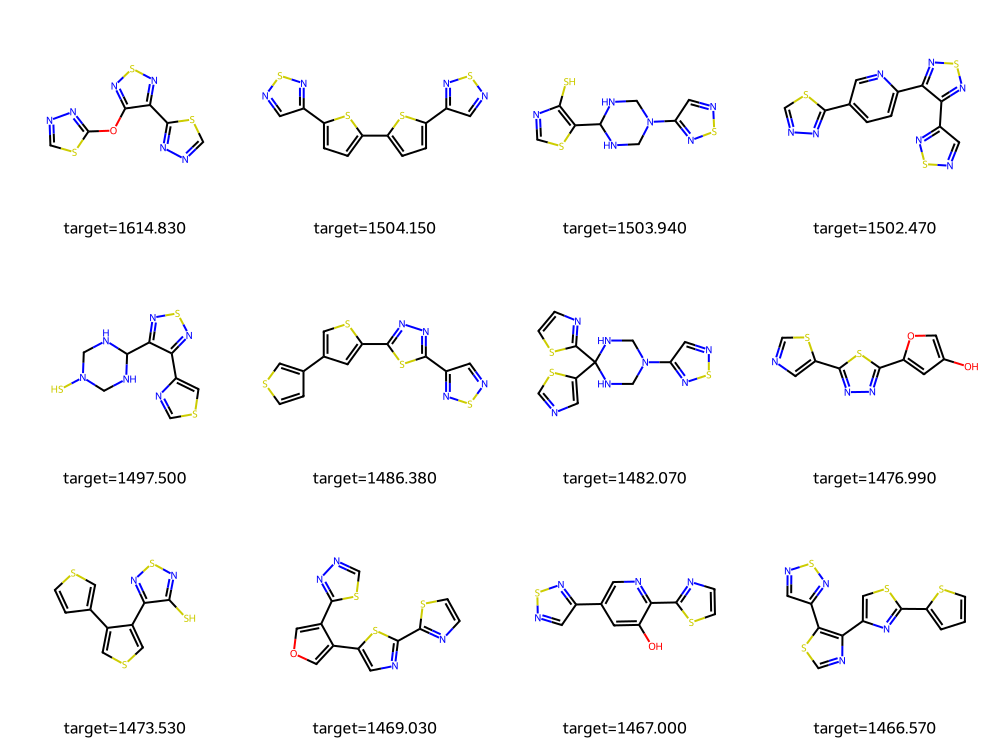

,canonical_smiles,target
0,c1nnc(Oc2nsnc2-c2nncs2)s1,1614.83
1,c1nsnc1-c1ccc(-c2ccc(-c3cnsn3)s2)s1,1504.15
2,Sc1ncsc1C1NCN(c2cnsn2)CN1,1503.94
3,c1nnc(-c2ccc(-c3nsnc3-c3cnsn3)nc2)s1,1502.47
4,SN1CNC(c2nsnc2-c2cscn2)NC1,1497.50
5,c1cc(-c2csc(-c3nnc(-c4cnsn4)s3)c2)cs1,1486.38
6,c1csc(C2(c3cncs3)NCN(c3cnsn3)CN2)n1,1482.07
7,Oc1coc(-c2nnc(-c3cncs3)s2)c1,1476.99
8,Sc1nsnc1-c1cscc1-c1ccsc1,1473.53
9,c1csc(-c2ncc(-c3cocc3-c3nncs3)s2)n1,1469.03


In [9]:
# @title 2A. Preview curated molecules { display-mode: "form" }
preview_molecules = 12 # @param {type:"slider", min:4, max:20, step:1}
preview_selection_mode = "Highest target values" # @param ["Highest target values", "Lowest target values", "Random sample", "Dataset order"]

if not IN_COLAB:
    _local_form_id = '9b5d34b2'
    _local_form_values = read_local_form_values('9b5d34b2', [{'name': 'preview_molecules', 'label': 'preview molecules', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 20, 'step': 1}, {'name': 'preview_selection_mode', 'label': 'preview selection mode', 'widget_kind': 'choice', 'default': 'Highest target values', 'options': ['Highest target values', 'Lowest target values', 'Random sample', 'Dataset order']}])
    preview_molecules = _local_form_values['preview_molecules']
    preview_selection_mode = _local_form_values['preview_selection_mode']

if "curated_df" not in STATE:
    raise RuntimeError("Please run the curation cell first.")

curated_df = STATE["curated_df"].copy()
preview_count = min(int(preview_molecules), len(curated_df))
if preview_selection_mode == "Highest target values":
    preview_df = curated_df.sort_values("target", ascending=False).head(preview_count).reset_index(drop=True)
elif preview_selection_mode == "Lowest target values":
    preview_df = curated_df.sort_values("target", ascending=True).head(preview_count).reset_index(drop=True)
elif preview_selection_mode == "Random sample":
    preview_df = curated_df.sample(preview_count, random_state=42).reset_index(drop=True)
else:
    preview_df = curated_df.head(preview_count).reset_index(drop=True)
legends = [f"target={value:.3f}" for value in preview_df["target"]]
try:
    from rdkit.Chem import Draw
    display(Draw.MolsToGridImage(preview_df["rdkit_mol"].tolist(), legends=legends, molsPerRow=4, subImgSize=(250, 250), useSVG=False))
except Exception as exc:
    print(f"Molecule preview skipped because RDKit drawing support is unavailable: {exc}")
display(preview_df[["canonical_smiles", "target"]])


### 2B. Generate Molecular Features

Select one or more molecular feature families below. Checking every box is the equivalent of an "all descriptors" representation.


In [10]:
# Local widget controls for: 2B. Generate molecular features
if not IN_COLAB:
    ensure_local_form_display('2B. Generate molecular features', 'e18a483f', [{'name': 'use_morgan_features', 'label': 'use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'use_ecfp6_features', 'label': 'use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_fcfp6_features', 'label': 'use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'use_maccs_keys', 'label': 'use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'use_rdkit_descriptors', 'label': 'use rdkit descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'morgan_radius', 'label': 'morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'fingerprint_bits', 'label': 'fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'enable_lasso_feature_selection', 'label': 'enable lasso feature selection', 'widget_kind': 'boolean', 'default': False}, {'name': 'lasso_feature_selection_alpha', 'label': 'lasso feature selection alpha', 'widget_kind': 'number', 'default': 0.001}])


In [11]:
# @title 2B. Generate molecular features { display-mode: "form" }
use_morgan_features = False # @param {type:"boolean"}
use_ecfp6_features = True # @param {type:"boolean"}
use_fcfp6_features = False # @param {type:"boolean"}
use_maccs_keys = False # @param {type:"boolean"}
use_rdkit_descriptors = False # @param {type:"boolean"}
morgan_radius = 2 # @param {type:"slider", min:1, max:4, step:1}
fingerprint_bits = "1024" # @param ["256", "512", "1024", "2048"]
enable_lasso_feature_selection = False # @param {type:"boolean"}
lasso_feature_selection_alpha = 0.001 # @param {type:"number"}

if not IN_COLAB:
    _local_form_id = 'e18a483f'
    _local_form_values = read_local_form_values('e18a483f', [{'name': 'use_morgan_features', 'label': 'use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'use_ecfp6_features', 'label': 'use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_fcfp6_features', 'label': 'use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'use_maccs_keys', 'label': 'use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'use_rdkit_descriptors', 'label': 'use rdkit descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'morgan_radius', 'label': 'morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'fingerprint_bits', 'label': 'fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'enable_lasso_feature_selection', 'label': 'enable lasso feature selection', 'widget_kind': 'boolean', 'default': False}, {'name': 'lasso_feature_selection_alpha', 'label': 'lasso feature selection alpha', 'widget_kind': 'number', 'default': 0.001}])
    use_morgan_features = _local_form_values['use_morgan_features']
    use_ecfp6_features = _local_form_values['use_ecfp6_features']
    use_fcfp6_features = _local_form_values['use_fcfp6_features']
    use_maccs_keys = _local_form_values['use_maccs_keys']
    use_rdkit_descriptors = _local_form_values['use_rdkit_descriptors']
    morgan_radius = _local_form_values['morgan_radius']
    fingerprint_bits = _local_form_values['fingerprint_bits']
    enable_lasso_feature_selection = _local_form_values['enable_lasso_feature_selection']
    lasso_feature_selection_alpha = _local_form_values['lasso_feature_selection_alpha']

if "curated_df" not in STATE:
    raise RuntimeError("Please run the curation cell first.")

selected_feature_families = normalize_selected_feature_families(
    use_morgan_features=use_morgan_features,
    use_ecfp6_features=use_ecfp6_features,
    use_fcfp6_features=use_fcfp6_features,
    use_maccs_keys=use_maccs_keys,
    use_rdkit_descriptors=use_rdkit_descriptors,
)
if not selected_feature_families:
    raise ValueError("Please select at least one molecular feature family.")

try:
    X, build_info = build_feature_matrix_from_smiles(
        curated_df["canonical_smiles"].tolist(),
        selected_feature_families=selected_feature_families,
        radius=int(morgan_radius),
        n_bits=int(fingerprint_bits),
    )
except Exception as exc:
    raise RuntimeError(
        "Could not build the selected molecular representation. "
        f"{exc}"
    ) from exc

for warning_text in build_info["warnings"]:
    print(f"Warning: {warning_text}")

lasso_summary = None
if enable_lasso_feature_selection:
    X, lasso_summary = apply_lasso_feature_selection(
        X,
        curated_df["target"].to_numpy(dtype=float),
        alpha=float(lasso_feature_selection_alpha),
        random_seed=42,
    )

STATE["feature_matrix"] = X.copy()
STATE["feature_names"] = list(X.columns)
STATE["fingerprint_radius"] = int(morgan_radius)
STATE["fingerprint_bits"] = int(fingerprint_bits)
STATE["selected_feature_families"] = list(build_info["selected_feature_families"])
STATE["built_feature_families"] = list(build_info["built_feature_families"])
STATE["skipped_feature_families"] = list(build_info["skipped_feature_families"])
STATE["lasso_feature_selection_summary"] = dict(lasso_summary) if lasso_summary is not None else {}
STATE["feature_builder_config"] = {
    "selected_feature_families": list(build_info["selected_feature_families"]),
    "built_feature_families": list(build_info["built_feature_families"]),
    "skipped_feature_families": list(build_info["skipped_feature_families"]),
    "fingerprint_radius": int(morgan_radius),
    "fingerprint_bits": int(fingerprint_bits),
    "lasso_feature_selection_enabled": bool(enable_lasso_feature_selection),
    "lasso_alpha": float(lasso_feature_selection_alpha) if enable_lasso_feature_selection else None,
    "lasso_selected_feature_count": int(X.shape[1]),
}
STATE["representation_label"] = build_info["representation_label"]
print(f"Representation built: {STATE['representation_label']}")
print(f"Selected feature families: {', '.join(build_info['selected_feature_families'])}")
print(f"Built feature families: {', '.join(build_info['built_feature_families'])}")
if build_info["skipped_feature_families"]:
    print(f"Skipped feature families: {', '.join(build_info['skipped_feature_families'])}")
if lasso_summary is not None:
    print(
        "LASSO feature selection kept "
        f"{lasso_summary['selected_feature_count']:,} of {lasso_summary['original_feature_count']:,} features "
        f"(alpha={lasso_summary['alpha']})."
    )
print(f"Feature matrix shape: {X.shape[0]:,} molecules x {X.shape[1]:,} features")
display(X.head(3))


Representation built: ECFP6(bits=1024)
Selected feature families: ecfp6
Built feature families: ecfp6
Feature matrix shape: 500 molecules x 1,024 features


,ecfp6_bit_0000,ecfp6_bit_0001,ecfp6_bit_0002,ecfp6_bit_0003,ecfp6_bit_0004,ecfp6_bit_0005,ecfp6_bit_0006,ecfp6_bit_0007,ecfp6_bit_0008,ecfp6_bit_0009,...,ecfp6_bit_1014,ecfp6_bit_1015,ecfp6_bit_1016,ecfp6_bit_1017,ecfp6_bit_1018,ecfp6_bit_1019,ecfp6_bit_1020,ecfp6_bit_1021,ecfp6_bit_1022,ecfp6_bit_1023
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### 2C. Representation Note

`Morgan`, `ECFP6`, and `FCFP6` are all circular fingerprints:

- **Morgan** uses the user-selected radius and bit length
- **ECFP6** uses atom-identity style invariants
- **FCFP6** uses feature-based invariants
- **MACCS** provides a compact fixed key set
- **RDKit descriptors** provide continuous physicochemical summary features

If the descriptor count becomes large relative to the number of molecules, you can enable the optional **LASSO feature-selection** step in `2B` to trim the matrix before downstream modeling.


## 3. Chemical Similarity Map

Molecules that cluster together in this plot usually have more similar molecular feature profiles.


In [12]:
# Local widget controls for: 3A. Build an interactive PCA -> t-SNE map
if not IN_COLAB:
    ensure_local_form_display('3A. Build an interactive PCA -> t-SNE map', 'fbf65b13', [{'name': 'tsne_use_morgan_features', 'label': 'tsne use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdkit_descriptors', 'label': 'tsne use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_ecfp6_features', 'label': 'tsne use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_fcfp6_features', 'label': 'tsne use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_maccs_keys', 'label': 'tsne use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_all_descriptors', 'label': 'tsne use all descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_morgan_radius', 'label': 'tsne morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'tsne_fingerprint_bits', 'label': 'tsne fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'perplexity', 'label': 'perplexity', 'widget_kind': 'slider', 'default': 30, 'min': 5, 'max': 50, 'step': 1}, {'name': 'max_points_for_map', 'label': 'max points for map', 'widget_kind': 'slider', 'default': 1000, 'min': 100, 'max': 2000, 'step': 100}, {'name': 'embedding_random_seed', 'label': 'embedding random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_similarity_map_cache', 'label': 'enable similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_similarity_map_cache', 'label': 'reuse similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'similarity_map_cache_run_name', 'label': 'similarity map cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])


In [17]:
# @title 3A. Build an interactive PCA -> t-SNE map { display-mode: "form" }
tsne_use_morgan_features = False # @param {type:"boolean"}
tsne_use_rdkit_descriptors = True # @param {type:"boolean"}
tsne_use_ecfp6_features = True # @param {type:"boolean"}
tsne_use_fcfp6_features = False # @param {type:"boolean"}
tsne_use_maccs_keys = False # @param {type:"boolean"}
tsne_use_all_descriptors = False # @param {type:"boolean"}
tsne_morgan_radius = 2 # @param {type:"slider", min:1, max:4, step:1}
tsne_fingerprint_bits = "1024" # @param ["256", "512", "1024", "2048"]
perplexity = 30 # @param {type:"slider", min:5, max:50, step:1}
max_points_for_map = 1000 # @param {type:"slider", min:100, max:2000, step:100}
embedding_random_seed = 42 # @param {type:"integer"}
enable_similarity_map_cache = True # @param {type:"boolean"}
reuse_similarity_map_cache = True # @param {type:"boolean"}
similarity_map_cache_run_name = "AUTO" # @param {type:"string"}

if not IN_COLAB:
    _local_form_id = 'fbf65b13'
    _local_form_values = read_local_form_values('fbf65b13', [{'name': 'tsne_use_morgan_features', 'label': 'tsne use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdkit_descriptors', 'label': 'tsne use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_ecfp6_features', 'label': 'tsne use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_fcfp6_features', 'label': 'tsne use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_maccs_keys', 'label': 'tsne use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_all_descriptors', 'label': 'tsne use all descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_morgan_radius', 'label': 'tsne morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'tsne_fingerprint_bits', 'label': 'tsne fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'perplexity', 'label': 'perplexity', 'widget_kind': 'slider', 'default': 30, 'min': 5, 'max': 50, 'step': 1}, {'name': 'max_points_for_map', 'label': 'max points for map', 'widget_kind': 'slider', 'default': 1000, 'min': 100, 'max': 2000, 'step': 100}, {'name': 'embedding_random_seed', 'label': 'embedding random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_similarity_map_cache', 'label': 'enable similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_similarity_map_cache', 'label': 'reuse similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'similarity_map_cache_run_name', 'label': 'similarity map cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
    tsne_use_morgan_features = _local_form_values['tsne_use_morgan_features']
    tsne_use_rdkit_descriptors = _local_form_values['tsne_use_rdkit_descriptors']
    tsne_use_ecfp6_features = _local_form_values['tsne_use_ecfp6_features']
    tsne_use_fcfp6_features = _local_form_values['tsne_use_fcfp6_features']
    tsne_use_maccs_keys = _local_form_values['tsne_use_maccs_keys']
    tsne_use_all_descriptors = _local_form_values['tsne_use_all_descriptors']
    tsne_morgan_radius = _local_form_values['tsne_morgan_radius']
    tsne_fingerprint_bits = _local_form_values['tsne_fingerprint_bits']
    perplexity = _local_form_values['perplexity']
    max_points_for_map = _local_form_values['max_points_for_map']
    embedding_random_seed = _local_form_values['embedding_random_seed']
    enable_similarity_map_cache = _local_form_values['enable_similarity_map_cache']
    reuse_similarity_map_cache = _local_form_values['reuse_similarity_map_cache']
    similarity_map_cache_run_name = _local_form_values['similarity_map_cache_run_name']

if "curated_df" not in STATE:
    raise RuntimeError("Please run the curation cell first.")

curated_df = STATE["curated_df"].copy()
if len(curated_df) < 6:
    raise ValueError("Please provide at least 6 valid molecules before building the similarity map.")
if len(curated_df) > max_points_for_map:
    sampled = curated_df.sample(max_points_for_map, random_state=int(embedding_random_seed)).index
    plot_df = curated_df.loc[sampled].reset_index(drop=True)
else:
    plot_df = curated_df.reset_index(drop=True)
sampled_smiles = plot_df["canonical_smiles"].astype(str).reset_index(drop=True)
selected_map_options = []
if tsne_use_morgan_features:
    selected_map_options.append(("Morgan fingerprints", ["morgan"]))
if tsne_use_rdkit_descriptors:
    selected_map_options.append(("RDKit descriptors", ["rdkit"]))
if tsne_use_ecfp6_features:
    selected_map_options.append(("ECFP6 fingerprints", ["ecfp6"]))
if tsne_use_fcfp6_features:
    selected_map_options.append(("FCFP6 fingerprints", ["fcfp6"]))
if tsne_use_maccs_keys:
    selected_map_options.append(("MACCS keys", ["maccs"]))
if tsne_use_all_descriptors:
    selected_map_options.append(("All descriptors", ["morgan", "rdkit", "ecfp6", "fcfp6", "maccs"]))
if not selected_map_options:
    raise ValueError("Please select at least one descriptor option for the similarity map.")

similarity_map_cache_dir = None
similarity_map_results = {}
similarity_map_cache_paths = {}
total_steps = max(1, len(selected_map_options) * 4)
progress = tqdm(total=total_steps, desc="Similarity map", leave=False)
if enable_similarity_map_cache:
    similarity_map_cache_dir = resolve_model_cache_dir(
        "similarity_map",
        similarity_map_cache_run_name,
        prefer_existing=bool(reuse_similarity_map_cache),
    )
    print(f"Similarity map cache directory: {similarity_map_cache_dir}")

for map_label, map_families in selected_map_options:
    progress.set_postfix_str(f"Building features: {map_label}")
    feature_df, build_info = build_feature_matrix_from_smiles(
        sampled_smiles.tolist(),
        selected_feature_families=map_families,
        radius=int(tsne_morgan_radius),
        n_bits=int(tsne_fingerprint_bits),
    )
    progress.update(1)

    tsne_perplexity = min(int(perplexity), max(2, len(feature_df) - 1))
    n_pca = min(50, feature_df.shape[1], max(2, feature_df.shape[0] - 1))
    map_df = None
    cache_key = slugify_cache_text(map_label)

    if enable_similarity_map_cache and reuse_similarity_map_cache and similarity_map_cache_dir is not None:
        metadata_candidates = sorted(
            similarity_map_cache_dir.glob(f"*_{cache_key}_similarity_map_metadata.json"),
            key=lambda path: path.name,
            reverse=True,
        )
        for metadata_path in metadata_candidates:
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "workflow": "Similarity map",
                    "dataset_label": current_dataset_cache_label(),
                    "representation_label": build_info["representation_label"],
                    "feature_families": list(map_families),
                    "morgan_radius": int(tsne_morgan_radius),
                    "n_rows": len(feature_df),
                    "n_features": feature_df.shape[1],
                    "perplexity": tsne_perplexity,
                    "max_points_for_map": int(max_points_for_map),
                    "embedding_random_seed": int(embedding_random_seed),
                    "n_pca": int(n_pca),
                    "fingerprint_bits": int(tsne_fingerprint_bits),
                }
                if not cache_metadata_matches(metadata, expected_metadata):
                    continue
                map_path = Path(metadata["map_path"])
                if not map_path.exists():
                    continue
                cached_map_df = pd.read_csv(map_path)
                if len(cached_map_df) != len(sampled_smiles):
                    continue
                if not cached_map_df["canonical_smiles"].astype(str).reset_index(drop=True).equals(sampled_smiles):
                    continue
                map_df = cached_map_df.copy()
                similarity_map_cache_paths[map_label] = {
                    "map_path": str(map_path),
                    "metadata_path": str(metadata_path),
                }
                print(f"Loaded cached similarity map for {map_label} from {map_path.parent}", flush=True)
                break
            except Exception:
                continue
    progress.update(1)

    if map_df is None:
        progress.set_postfix_str(f"Running PCA/t-SNE: {map_label}")
        pca_scores = PCA(n_components=n_pca, random_state=int(embedding_random_seed)).fit_transform(feature_df)
        tsne_scores = TSNE(
            n_components=2,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=int(embedding_random_seed),
        ).fit_transform(pca_scores)
        map_df = plot_df[["canonical_smiles", "target"]].copy()
        map_df["PCA_tSNE_1"] = tsne_scores[:, 0]
        map_df["PCA_tSNE_2"] = tsne_scores[:, 1]
        progress.update(1)

        if enable_similarity_map_cache and similarity_map_cache_dir is not None:
            artifact_base = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_{cache_key}_similarity_map"
            map_path = similarity_map_cache_dir / f"{artifact_base}.csv"
            metadata_path = similarity_map_cache_dir / f"{artifact_base}_metadata.json"
            map_df.to_csv(map_path, index=False)
            write_cache_metadata(
                metadata_path,
                {
                    "workflow": "Similarity map",
                    "dataset_label": current_dataset_cache_label(),
                    "representation_label": build_info["representation_label"],
                    "feature_families": list(map_families),
                    "morgan_radius": int(tsne_morgan_radius),
                    "n_rows": len(feature_df),
                    "n_features": feature_df.shape[1],
                    "perplexity": tsne_perplexity,
                    "max_points_for_map": int(max_points_for_map),
                    "embedding_random_seed": int(embedding_random_seed),
                    "n_pca": int(n_pca),
                    "fingerprint_bits": int(tsne_fingerprint_bits),
                    "cache_run_name": similarity_map_cache_dir.name,
                    "map_path": str(map_path),
                },
            )
            similarity_map_cache_paths[map_label] = {
                "map_path": str(map_path),
                "metadata_path": str(metadata_path),
            }
    else:
        progress.update(1)

    fig = px.scatter(
        map_df,
        x="PCA_tSNE_1",
        y="PCA_tSNE_2",
        color="target",
        hover_data={"canonical_smiles": True, "target": ":.4f"},
        title=f"Chemical similarity map ({map_label} -> PCA -> t-SNE)",
        color_continuous_scale="Viridis",
    )
    fig.update_layout(height=600)
    show_plotly(fig)
    similarity_map_results[map_label] = {
        "map_df": map_df.copy(),
        "feature_families": list(map_families),
        "representation_label": build_info["representation_label"],
    }
    progress.update(1)

STATE["similarity_map_results"] = similarity_map_results
if similarity_map_results:
    first_label = next(iter(similarity_map_results))
    STATE["similarity_map_df"] = similarity_map_results[first_label]["map_df"].copy()
if similarity_map_cache_paths:
    STATE["similarity_map_cache_paths"] = similarity_map_cache_paths
if similarity_map_cache_dir is not None:
    STATE["similarity_map_cache_dir"] = str(similarity_map_cache_dir)
progress.set_postfix_str("Done")
progress.close()


Similarity map:   0%|          | 0/16 [00:00<?, ?it/s, Building features: Morgan fingerprints]

Similarity map cache directory: model_cache\similarity_map\20260403_090702_repro_dev_data_similarity_map


Similarity map:  19%|█▉        | 3/16 [00:15<01:12,  5.57s/it, Running PCA/t-SNE: Morgan fingerprints]

Similarity map:  44%|████▍     | 7/16 [00:47<01:02,  6.92s/it, Running PCA/t-SNE: RDKit descriptors]  

Similarity map:  69%|██████▉   | 11/16 [00:56<00:20,  4.04s/it, Running PCA/t-SNE: ECFP6 fingerprints]

Similarity map:  94%|█████████▍| 15/16 [01:53<00:10, 10.33s/it, Running PCA/t-SNE: All descriptors]   

## 4. Conventional QSAR Models

This section follows the same broad modeling logic used throughout the repository:

- build a numerical representation from SMILES
- split data into training and test sets
- use scaling where the model benefits from it
- compare several algorithms with the **same split**
- judge the final models by both cross-validation and held-out test performance


In [19]:
# Local widget controls for: 4A. Train conventional ML models and show an interactive metrics table
if not IN_COLAB:
    ensure_local_form_display('4A. Train conventional ML models and show an interactive metrics table', '2749f46a', [{'name': 'data_split_strategy', 'label': 'data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'test_fraction', 'label': 'test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'use_cross_validation', 'label': 'use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'cv_folds', 'label': 'cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_conventional_model_cache', 'label': 'enable conventional model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_conventional_cached_models', 'label': 'reuse conventional cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'conventional_cache_run_name', 'label': 'conventional cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'run_elasticnet', 'label': 'run elasticnet', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_svr', 'label': 'run svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_random_forest', 'label': 'run random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_xgboost', 'label': 'run xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_catboost', 'label': 'run catboost', 'widget_kind': 'boolean', 'default': True}])


In [30]:
# @title 4A. Train conventional ML models and show an interactive metrics table { display-mode: "form" }
data_split_strategy = "random" # @param ["random", "scaffold"]
test_fraction = 0.2 # @param {type:"slider", min:0.1, max:0.4, step:0.05}
use_cross_validation = True # @param {type:"boolean"}
cv_folds = 5 # @param [3, 5, 10]
model_random_seed = 42 # @param {type:"integer"}
enable_conventional_model_cache = True # @param {type:"boolean"}
reuse_conventional_cached_models = True # @param {type:"boolean"}
conventional_cache_run_name = "AUTO" # @param {type:"string"}
run_elasticnet = True # @param {type:"boolean"}
run_svr = True # @param {type:"boolean"}
run_random_forest = True # @param {type:"boolean"}
run_xgboost = True # @param {type:"boolean"}
run_catboost = True # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = '2749f46a'
    _local_form_values = read_local_form_values('2749f46a', [{'name': 'data_split_strategy', 'label': 'data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'test_fraction', 'label': 'test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'use_cross_validation', 'label': 'use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'cv_folds', 'label': 'cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_conventional_model_cache', 'label': 'enable conventional model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_conventional_cached_models', 'label': 'reuse conventional cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'conventional_cache_run_name', 'label': 'conventional cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'run_elasticnet', 'label': 'run elasticnet', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_svr', 'label': 'run svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_random_forest', 'label': 'run random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_xgboost', 'label': 'run xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_catboost', 'label': 'run catboost', 'widget_kind': 'boolean', 'default': True}])
    data_split_strategy = _local_form_values['data_split_strategy']
    test_fraction = _local_form_values['test_fraction']
    use_cross_validation = _local_form_values['use_cross_validation']
    cv_folds = _local_form_values['cv_folds']
    model_random_seed = _local_form_values['model_random_seed']
    enable_conventional_model_cache = _local_form_values['enable_conventional_model_cache']
    reuse_conventional_cached_models = _local_form_values['reuse_conventional_cached_models']
    conventional_cache_run_name = _local_form_values['conventional_cache_run_name']
    run_elasticnet = _local_form_values['run_elasticnet']
    run_svr = _local_form_values['run_svr']
    run_random_forest = _local_form_values['run_random_forest']
    run_xgboost = _local_form_values['run_xgboost']
    run_catboost = _local_form_values['run_catboost']

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

split_payload = apply_qsar_split(
    split_strategy=str(data_split_strategy),
    test_fraction=float(test_fraction),
    random_seed=int(model_random_seed),
    announce=True,
)
X_train = split_payload["X_train"]
X_test = split_payload["X_test"]
y_train = pd.Series(split_payload["y_train"], dtype=float)
y_test = pd.Series(split_payload["y_test"], dtype=float)
smiles_train = split_payload["smiles_train"]
smiles_test = split_payload["smiles_test"]
effective_cv_folds = None
if use_cross_validation:
    effective_cv_folds = min(int(cv_folds), len(X_train))
    if effective_cv_folds < 2:
        raise ValueError("At least 2 cross-validation folds are required when cross-validation is enabled.")
feature_metadata = current_feature_metadata()

available_models = {
    "ElasticNet": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=10000)),
        ]
    ),
    "SVR": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVR(C=10.0, epsilon=0.1, gamma="scale")),
        ]
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=400, random_state=int(model_random_seed), n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=int(model_random_seed),
        n_jobs=2,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=400,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=int(model_random_seed),
        verbose=False,
    ),
}

selected_models = {}
if run_elasticnet:
    selected_models["ElasticNet"] = available_models["ElasticNet"]
if run_svr:
    selected_models["SVR"] = available_models["SVR"]
if run_random_forest:
    selected_models["Random forest"] = available_models["Random forest"]
if run_xgboost:
    selected_models["XGBoost"] = available_models["XGBoost"]
if run_catboost:
    selected_models["CatBoost"] = available_models["CatBoost"]

if not selected_models:
    raise ValueError("Please select at least one conventional model to run.")

cv = None
scoring = None
if use_cross_validation:
    cv = KFold(n_splits=effective_cv_folds, shuffle=True, random_state=int(model_random_seed))
    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
    }

metrics_rows = []
fitted_models = {}
predictions = {}
traditional_cache_paths = {}
conventional_cache_dir = None
conventional_dataset_label = current_dataset_cache_label()
if enable_conventional_model_cache:
    from joblib import dump as joblib_dump, load as joblib_load

    conventional_cache_dir = resolve_model_cache_dir(
        "conventional_ml",
        conventional_cache_run_name,
        prefer_existing=bool(reuse_conventional_cached_models),
    )
    print(f"Conventional model cache directory: {conventional_cache_dir}")

model_progress = tqdm(list(selected_models.items()), desc="Conventional models", leave=False)
for name, estimator in model_progress:
    model_progress.set_postfix_str(name)
    fitted = None
    pred_train = None
    pred_test = None
    cached_model_loaded = False
    cached_metadata = None
    model_slug = slugify_cache_text(name)
    if enable_conventional_model_cache and reuse_conventional_cached_models:
        metadata_candidates = sorted(
            conventional_cache_dir.glob(f"*_{conventional_dataset_label}_{model_slug}_metadata.json"),
            key=lambda path: path.name,
            reverse=True,
        )
        for metadata_path in metadata_candidates:
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "model_name": name,
                    "workflow": "Conventional ML",
                    "dataset_label": conventional_dataset_label,
                    "split_strategy": str(data_split_strategy),
                    "test_fraction": float(test_fraction),
                    "cross_validation_enabled": bool(use_cross_validation),
                    "cv_folds": int(effective_cv_folds) if effective_cv_folds is not None else None,
                    "random_seed": int(model_random_seed),
                    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                    "built_feature_families": list(feature_metadata["built_feature_families"]),
                    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                    "lasso_alpha": feature_metadata["lasso_alpha"],
                    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                }
                if not cache_metadata_matches(metadata, expected_metadata):
                    continue
                model_path = Path(metadata["model_path"])
                prediction_path = Path(metadata["prediction_path"])
                if not model_path.exists() or not prediction_path.exists():
                    continue
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    smiles_train.astype(str),
                    smiles_test.astype(str),
                )
                fitted = joblib_load(model_path)
                pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                cached_model_loaded = True
                cached_metadata = metadata
                traditional_cache_paths[name] = {
                    "model_path": str(model_path),
                    "prediction_path": str(prediction_path),
                    "metadata_path": str(metadata_path),
                }
                print(f"Loaded cached conventional model for {name} from {model_path.parent}", flush=True)
                break
            except Exception:
                continue

    scores = None
    if not cached_model_loaded:
        if use_cross_validation:
            scores = cross_validate(clone(estimator), X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
        fitted = clone(estimator)
        fitted.fit(X_train, y_train)
        pred_train = np.asarray(fitted.predict(X_train)).reshape(-1)
        pred_test = np.asarray(fitted.predict(X_test)).reshape(-1)

    row = {
        "Model": name,
        "CV R2": (
            float(np.mean(scores["test_r2"]))
            if scores is not None
            else float(cached_metadata.get("cv_r2"))
            if cached_model_loaded and cached_metadata is not None and cached_metadata.get("cv_r2") not in [None, "None", ""]
            else np.nan
        ),
        "CV RMSE": (
            float(np.mean(np.sqrt(-scores["test_mse"])))
            if scores is not None
            else float(cached_metadata.get("cv_rmse"))
            if cached_model_loaded and cached_metadata is not None and cached_metadata.get("cv_rmse") not in [None, "None", ""]
            else np.nan
        ),
        "CV MAE": (
            float(np.mean(-scores["test_mae"]))
            if scores is not None
            else float(cached_metadata.get("cv_mae"))
            if cached_model_loaded and cached_metadata is not None and cached_metadata.get("cv_mae") not in [None, "None", ""]
            else np.nan
        ),
    }
    row.update(summarize_regression(y_train, pred_train, "Train"))
    row.update(summarize_regression(y_test, pred_test, "Test"))
    metrics_rows.append(row)
    fitted_models[name] = fitted
    predictions[name] = {"train": pred_train, "test": pred_test}
    if enable_conventional_model_cache and not cached_model_loaded:
        artifact_base = f"{STATE['cache_session_stamp']}_{conventional_dataset_label}_{model_slug}"
        model_path = conventional_cache_dir / f"{artifact_base}.joblib"
        prediction_path = conventional_cache_dir / f"{artifact_base}_predictions.csv"
        metadata_path = conventional_cache_dir / f"{artifact_base}_metadata.json"
        joblib_dump(fitted, model_path)
        pd.DataFrame(
            {
                "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
                "smiles": list(smiles_train.astype(str)) + list(smiles_test.astype(str)),
                "observed": list(np.asarray(y_train, dtype=float)) + list(np.asarray(y_test, dtype=float)),
                "predicted": list(pred_train) + list(pred_test),
            }
        ).to_csv(prediction_path, index=False)
        write_cache_metadata(
            metadata_path,
            {
                "model_name": name,
                "workflow": "Conventional ML",
                "dataset_label": conventional_dataset_label,
                "representation_label": feature_metadata["representation_label"],
                "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                "built_feature_families": list(feature_metadata["built_feature_families"]),
                "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                "lasso_alpha": feature_metadata["lasso_alpha"],
                "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                "cache_run_name": conventional_cache_dir.name,
                "model_path": model_path,
                "prediction_path": prediction_path,
                "split_strategy": str(data_split_strategy),
                "test_fraction": float(test_fraction),
                "cross_validation_enabled": bool(use_cross_validation),
                "cv_folds": int(effective_cv_folds) if effective_cv_folds is not None else None,
                "cv_r2": row["CV R2"],
                "cv_rmse": row["CV RMSE"],
                "cv_mae": row["CV MAE"],
                "random_seed": int(model_random_seed),
            },
        )
        traditional_cache_paths[name] = {
            "model_path": str(model_path),
            "prediction_path": str(prediction_path),
            "metadata_path": str(metadata_path),
        }
model_progress.close()

results_df = pd.DataFrame(metrics_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
best_model_name = results_df.loc[0, "Model"]

STATE["X_train"] = X_train.copy()
STATE["X_test"] = X_test.copy()
STATE["y_train"] = y_train.to_numpy(dtype=float)
STATE["y_test"] = y_test.to_numpy(dtype=float)
STATE["smiles_train"] = smiles_train.reset_index(drop=True)
STATE["smiles_test"] = smiles_test.reset_index(drop=True)
STATE["traditional_models"] = fitted_models
STATE["traditional_predictions"] = predictions
STATE["traditional_results"] = results_df.copy()
STATE["best_traditional_model_name"] = best_model_name
STATE["traditional_model_cache_paths"] = traditional_cache_paths
if conventional_cache_dir is not None:
    STATE["traditional_model_cache_dir"] = str(conventional_cache_dir)

print(f"Ran {len(selected_models)} conventional model(s): {', '.join(selected_models.keys())}")
if use_cross_validation:
    print(f"Cross-validation enabled with {effective_cv_folds} folds.")
else:
    print("Cross-validation disabled. Ranking is based on held-out test performance only.")
print(f"Best conventional model on the held-out test set: {best_model_name}")
if enable_conventional_model_cache and conventional_cache_dir is not None:
    print(f"Conventional model cache directory: {conventional_cache_dir}")
display_interactive_table(results_df.round(4), rows=min(10, len(results_df)))
if use_cross_validation:
    display_note(
        "A strong model should look good in **both** cross-validation and the held-out test set. "
        "If training scores are much better than test scores, the model may be overfitting."
    )
else:
    display_note(
        "Cross-validation was disabled for this run, so model comparison is based on the single held-out test split plus the training metrics."
    )


QSAR split: strategy=random, test_fraction=0.20, random_seed=42, train=2447, test=612
Conventional model cache directory: model_cache\conventional_ml\20260403_090702_repro_dev_data_conventional_ml


Conventional models:  20%|██        | 1/5 [07:05<28:21, 425.32s/it, SVR]       

In [21]:
# Local widget controls for: 4B. Plot observed vs predicted values for selected conventional models
if not IN_COLAB:
    ensure_local_form_display('4B. Plot observed vs predicted values for selected conventional models', 'd64edf3c', [{'name': 'point_size', 'label': 'point size', 'widget_kind': 'slider', 'default': 10, 'min': 6, 'max': 18, 'step': 1}, {'name': 'show_elasticnet_plot', 'label': 'show elasticnet plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_svr_plot', 'label': 'show svr plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_random_forest_plot', 'label': 'show random forest plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_xgboost_plot', 'label': 'show xgboost plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_catboost_plot', 'label': 'show catboost plot', 'widget_kind': 'boolean', 'default': True}])


In [24]:
# @title 4B. Plot observed vs predicted values for selected conventional models { display-mode: "form" }
point_size = 10 # @param {type:"slider", min:6, max:18, step:1}
show_elasticnet_plot = False # @param {type:"boolean"}
show_svr_plot = False # @param {type:"boolean"}
show_random_forest_plot = False # @param {type:"boolean"}
show_xgboost_plot = False # @param {type:"boolean"}
show_catboost_plot = True # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = 'd64edf3c'
    _local_form_values = read_local_form_values('d64edf3c', [{'name': 'point_size', 'label': 'point size', 'widget_kind': 'slider', 'default': 10, 'min': 6, 'max': 18, 'step': 1}, {'name': 'show_elasticnet_plot', 'label': 'show elasticnet plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_svr_plot', 'label': 'show svr plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_random_forest_plot', 'label': 'show random forest plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_xgboost_plot', 'label': 'show xgboost plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_catboost_plot', 'label': 'show catboost plot', 'widget_kind': 'boolean', 'default': True}])
    point_size = _local_form_values['point_size']
    show_elasticnet_plot = _local_form_values['show_elasticnet_plot']
    show_svr_plot = _local_form_values['show_svr_plot']
    show_random_forest_plot = _local_form_values['show_random_forest_plot']
    show_xgboost_plot = _local_form_values['show_xgboost_plot']
    show_catboost_plot = _local_form_values['show_catboost_plot']

if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")

requested_models = []
if show_elasticnet_plot:
    requested_models.append("ElasticNet")
if show_svr_plot:
    requested_models.append("SVR")
if show_random_forest_plot:
    requested_models.append("Random forest")
if show_xgboost_plot:
    requested_models.append("XGBoost")
if show_catboost_plot:
    requested_models.append("CatBoost")

if not requested_models:
    raise ValueError("Please select at least one conventional model to plot.")

import plotly.graph_objects as go
from plotly.subplots import make_subplots

available_predictions = STATE["traditional_predictions"]
available_results = STATE["traditional_results"].set_index("Model")
plotted_models = []
panel_frames = []

for model_name in requested_models:
    if model_name not in available_predictions:
        print(f"Skipping {model_name}: it was not trained in block 4A.")
        continue

    pred_train = available_predictions[model_name]["train"]
    pred_test = available_predictions[model_name]["test"]

    scatter_df = pd.concat(
        [
            pd.DataFrame(
                {
                    "Observed": STATE["y_train"],
                    "Predicted": pred_train,
                    "Split": "Train",
                    "SMILES": STATE["smiles_train"],
                    "Model": model_name,
                }
            ),
            pd.DataFrame(
                {
                    "Observed": STATE["y_test"],
                    "Predicted": pred_test,
                    "Split": "Test",
                    "SMILES": STATE["smiles_test"],
                    "Model": model_name,
                }
            ),
        ],
        axis=0,
        ignore_index=True,
    )
    panel_frames.append(scatter_df)
    row = available_results.loc[model_name]
    display_note(
        f"**{model_name}:** Points close to the dashed diagonal are predicted well. "
        f"On the held-out test set, this model achieved **R2 = {row['Test R2']:.3f}**, "
        f"**RMSE = {row['Test RMSE']:.3f}**, and **MAE = {row['Test MAE']:.3f}**."
    )
    plotted_models.append(model_name)

if not plotted_models:
    raise ValueError("None of the selected models were trained in block 4A.")

combined_df = pd.concat(panel_frames, axis=0, ignore_index=True)
low = float(min(combined_df["Observed"].min(), combined_df["Predicted"].min()))
high = float(max(combined_df["Observed"].max(), combined_df["Predicted"].max()))
use_log_axes = bool((combined_df["Observed"] > 0).all() and (combined_df["Predicted"] > 0).all())
if low == high:
    low -= 1.0
    high += 1.0
if use_log_axes:
    plot_low = low / 3.0
    plot_high = high * 3.0
else:
    plot_span = high - low
    plot_low = low - 0.05 * plot_span
    plot_high = high + 0.05 * plot_span

def visible_line_segment(slope, lower_bound, upper_bound):
    candidate_x = np.array(
        [lower_bound, upper_bound, lower_bound / slope, upper_bound / slope],
        dtype=float,
    )
    candidate_y = slope * candidate_x
    visible_mask = (
        np.isfinite(candidate_x)
        & np.isfinite(candidate_y)
        & (candidate_x >= lower_bound)
        & (candidate_x <= upper_bound)
        & (candidate_y >= lower_bound)
        & (candidate_y <= upper_bound)
    )
    visible_x = candidate_x[visible_mask]
    if visible_x.size < 2:
        return None
    x_start = float(np.min(visible_x))
    x_end = float(np.max(visible_x))
    return [x_start, x_end], [float(slope * x_start), float(slope * x_end)]

n_panels = len(plotted_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=plotted_models,
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    vertical_spacing=0.14,
)

split_colors = {"Train": "#1f77b4", "Test": "#d62728"}
split_order = ["Train", "Test"]

for panel_index, model_name in enumerate(plotted_models, start=1):
    row_num = int(math.ceil(panel_index / n_cols))
    col_num = ((panel_index - 1) % n_cols) + 1
    model_df = combined_df.loc[combined_df["Model"] == model_name].copy()

    for split_name in split_order:
        split_df = model_df.loc[model_df["Split"] == split_name].copy()
        if split_df.empty:
            continue
        fig.add_trace(
            go.Scatter(
                x=split_df["Observed"],
                y=split_df["Predicted"],
                mode="markers",
                name=split_name,
                legendgroup=split_name,
                showlegend=(panel_index == 1),
                marker={
                    "size": int(point_size),
                    "color": split_colors[split_name],
                    "opacity": 0.8,
                },
                customdata=np.column_stack(
                    [
                        split_df["SMILES"].astype(str).to_numpy(),
                        split_df["Observed"].to_numpy(dtype=float),
                        split_df["Predicted"].to_numpy(dtype=float),
                    ]
                ),
                hovertemplate=(
                    "SMILES: %{customdata[0]}<br>"
                    "Observed: %{customdata[1]:.4f}<br>"
                    "Predicted: %{customdata[2]:.4f}<br>"
                    f"Split: {split_name}<extra>{model_name}</extra>"
                ),
            ),
            row=row_num,
            col=col_num,
        )

    fig.add_trace(
        go.Scatter(
            x=[plot_low, plot_high],
            y=[plot_low, plot_high],
            mode="lines",
            name="1x line",
            legendgroup="guide-lines",
            showlegend=(panel_index == 1),
            line={"color": "#444444", "dash": "dash"},
            hoverinfo="skip",
        ),
        row=row_num,
        col=col_num,
    )
    upper_segment = visible_line_segment(3.0, plot_low, plot_high)
    if upper_segment is not None:
        fig.add_trace(
            go.Scatter(
                x=upper_segment[0],
                y=upper_segment[1],
                mode="lines",
                name="3x line",
                legendgroup="guide-lines",
                showlegend=(panel_index == 1),
                line={"color": "#7f7f7f", "dash": "dot"},
                hoverinfo="skip",
            ),
            row=row_num,
            col=col_num,
        )
    lower_segment = visible_line_segment(1.0 / 3.0, plot_low, plot_high)
    if lower_segment is not None:
        fig.add_trace(
            go.Scatter(
                x=lower_segment[0],
                y=lower_segment[1],
                mode="lines",
                name="1/3x line",
                legendgroup="guide-lines",
                showlegend=(panel_index == 1),
                line={"color": "#7f7f7f", "dash": "dot"},
                hoverinfo="skip",
            ),
            row=row_num,
            col=col_num,
        )
    if use_log_axes:
        fig.update_xaxes(
            title_text="Observed (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
        fig.update_yaxes(
            title_text="Predicted (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
    else:
        fig.update_xaxes(title_text="Observed", range=[plot_low, plot_high], row=row_num, col=col_num)
        fig.update_yaxes(title_text="Predicted", range=[plot_low, plot_high], row=row_num, col=col_num)

fig.update_layout(
    title="Observed vs predicted values for selected conventional models",
    height=max(520, 420 * n_rows),
    width=1100 if n_cols == 2 else 700,
)
show_plotly(fig)
if use_log_axes:
    display_note(
        "These observed/predicted panels use **log10 axes**. The dashed line is the ideal **1x** agreement line, "
        "and the dotted lines mark **3-fold error bounds** (predicted = 3 x observed and predicted = observed / 3). "
        "Hover over any point to see the SMILES string and its observed and predicted values."
    )
else:
    display_note(
        "These observed/predicted panels use **linear axes** because at least one observed or predicted value is non-positive. "
        "The dashed line is the ideal **1x** agreement line, and the dotted lines mark **3-fold error bounds** "
        "(predicted = 3 x observed and predicted = observed / 3). Hover over any point to see the SMILES string and its observed and predicted values."
    )


**ElasticNet:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = -8.741**, **RMSE = 574.419**, and **MAE = 410.755**.

**SVR:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = -0.004**, **RMSE = 184.377**, and **MAE = 89.328**.

**Random forest:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.049**, **RMSE = 179.494**, and **MAE = 88.110**.

**XGBoost:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.353**, **RMSE = 148.052**, and **MAE = 79.013**.

**CatBoost:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.178**, **RMSE = 166.890**, and **MAE = 90.815**.

These observed/predicted panels use **linear axes** because at least one observed or predicted value is non-positive. The dashed line is the ideal **1x** agreement line, and the dotted lines mark **3-fold error bounds** (predicted = 3 x observed and predicted = observed / 3). Hover over any point to see the SMILES string and its observed and predicted values.

### 4C. Genetic-Algorithm Hyperparameter Tuning

The hyperparameter tuning block in this notebook uses ChemML's own **genetic algorithm** implementation: `chemml.optimization.GeneticAlgorithm`.

Instead of exhaustively checking every point in a grid, the genetic algorithm proposes candidate hyperparameter combinations, evaluates them with cross-validation on the training set, and evolves toward better configurations over successive generations. That makes it a better match for mixed continuous, integer, and categorical search spaces like the ones used here.

The defaults below are intentionally moderate for Colab. If you need a deeper search, increase the population size or number of generations.


In [23]:
# Local widget controls for: 4C. Run genetic-algorithm tuning for selected conventional models
if not IN_COLAB:
    ensure_local_form_display('4C. Run genetic-algorithm tuning for selected conventional models', 'ae6ee60d', [{'name': 'tuning_split_strategy', 'label': 'tuning split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'tuning_test_fraction', 'label': 'tuning test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'tuning_random_seed', 'label': 'tuning random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'ga_cv_folds', 'label': 'ga cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5]}, {'name': 'ga_objective', 'label': 'ga objective', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae', 'r2']}, {'name': 'ga_generations', 'label': 'ga generations', 'widget_kind': 'slider', 'default': 8, 'min': 3, 'max': 20, 'step': 1}, {'name': 'ga_population_size', 'label': 'ga population size', 'widget_kind': 'slider', 'default': 16, 'min': 8, 'max': 40, 'step': 2}, {'name': 'ga_crossover_size', 'label': 'ga crossover size', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_size', 'label': 'ga mutation size', 'widget_kind': 'slider', 'default': 8, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_probability', 'label': 'ga mutation probability', 'widget_kind': 'slider', 'default': 0.6, 'min': 0.1, 'max': 0.9, 'step': 0.05}, {'name': 'ga_early_stopping', 'label': 'ga early stopping', 'widget_kind': 'slider', 'default': 4, 'min': 2, 'max': 10, 'step': 1}, {'name': 'enable_tuned_model_cache', 'label': 'enable tuned model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_tuned_cached_models', 'label': 'reuse tuned cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'tuned_cache_run_name', 'label': 'tuned cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'previous_ga_run_source', 'label': 'previous ga run source', 'widget_kind': 'string', 'default': ''}, {'name': 'upload_previous_ga_run_source', 'label': 'upload previous ga run source', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_elasticnet', 'label': 'tune elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_svr', 'label': 'tune svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_random_forest', 'label': 'tune random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_xgboost', 'label': 'tune xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_catboost', 'label': 'tune catboost', 'widget_kind': 'boolean', 'default': True}])


In [ ]:
# @title 4C. Run genetic-algorithm tuning for selected conventional models { display-mode: "form" }
tuning_split_strategy = "random" # @param ["random", "scaffold"]
tuning_test_fraction = 0.2 # @param {type:"slider", min:0.1, max:0.4, step:0.05}
tuning_random_seed = 42 # @param {type:"integer"}
ga_cv_folds = 5 # @param [3, 5]
ga_objective = "rmse" # @param ["rmse", "mae", "r2"]
ga_generations = 8 # @param {type:"slider", min:3, max:20, step:1}
ga_population_size = 16 # @param {type:"slider", min:8, max:40, step:2}
ga_crossover_size = 12 # @param {type:"slider", min:4, max:40, step:2}
ga_mutation_size = 8 # @param {type:"slider", min:4, max:40, step:2}
ga_mutation_probability = 0.6 # @param {type:"slider", min:0.1, max:0.9, step:0.05}
ga_early_stopping = 4 # @param {type:"slider", min:2, max:10, step:1}
enable_tuned_model_cache = True # @param {type:"boolean"}
reuse_tuned_cached_models = True # @param {type:"boolean"}
tuned_cache_run_name = "AUTO" # @param {type:"string"}
previous_ga_run_source = "" # @param {type:"string"}
upload_previous_ga_run_source = False # @param {type:"boolean"}
tune_elasticnet = False # @param {type:"boolean"}
tune_svr = False # @param {type:"boolean"}
tune_random_forest = True # @param {type:"boolean"}
tune_xgboost = True # @param {type:"boolean"}
tune_catboost = True # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = 'ae6ee60d'
    _local_form_values = read_local_form_values('ae6ee60d', [{'name': 'tuning_split_strategy', 'label': 'tuning split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'tuning_test_fraction', 'label': 'tuning test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'tuning_random_seed', 'label': 'tuning random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'ga_cv_folds', 'label': 'ga cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5]}, {'name': 'ga_objective', 'label': 'ga objective', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae', 'r2']}, {'name': 'ga_generations', 'label': 'ga generations', 'widget_kind': 'slider', 'default': 8, 'min': 3, 'max': 20, 'step': 1}, {'name': 'ga_population_size', 'label': 'ga population size', 'widget_kind': 'slider', 'default': 16, 'min': 8, 'max': 40, 'step': 2}, {'name': 'ga_crossover_size', 'label': 'ga crossover size', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_size', 'label': 'ga mutation size', 'widget_kind': 'slider', 'default': 8, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_probability', 'label': 'ga mutation probability', 'widget_kind': 'slider', 'default': 0.6, 'min': 0.1, 'max': 0.9, 'step': 0.05}, {'name': 'ga_early_stopping', 'label': 'ga early stopping', 'widget_kind': 'slider', 'default': 4, 'min': 2, 'max': 10, 'step': 1}, {'name': 'enable_tuned_model_cache', 'label': 'enable tuned model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_tuned_cached_models', 'label': 'reuse tuned cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'tuned_cache_run_name', 'label': 'tuned cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'previous_ga_run_source', 'label': 'previous ga run source', 'widget_kind': 'string', 'default': ''}, {'name': 'upload_previous_ga_run_source', 'label': 'upload previous ga run source', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_elasticnet', 'label': 'tune elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_svr', 'label': 'tune svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_random_forest', 'label': 'tune random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_xgboost', 'label': 'tune xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_catboost', 'label': 'tune catboost', 'widget_kind': 'boolean', 'default': True}])
    tuning_split_strategy = _local_form_values['tuning_split_strategy']
    tuning_test_fraction = _local_form_values['tuning_test_fraction']
    tuning_random_seed = _local_form_values['tuning_random_seed']
    ga_cv_folds = _local_form_values['ga_cv_folds']
    ga_objective = _local_form_values['ga_objective']
    ga_generations = _local_form_values['ga_generations']
    ga_population_size = _local_form_values['ga_population_size']
    ga_crossover_size = _local_form_values['ga_crossover_size']
    ga_mutation_size = _local_form_values['ga_mutation_size']
    ga_mutation_probability = _local_form_values['ga_mutation_probability']
    ga_early_stopping = _local_form_values['ga_early_stopping']
    enable_tuned_model_cache = _local_form_values['enable_tuned_model_cache']
    reuse_tuned_cached_models = _local_form_values['reuse_tuned_cached_models']
    tuned_cache_run_name = _local_form_values['tuned_cache_run_name']
    previous_ga_run_source = _local_form_values['previous_ga_run_source']
    upload_previous_ga_run_source = _local_form_values['upload_previous_ga_run_source']
    tune_elasticnet = _local_form_values['tune_elasticnet']
    tune_svr = _local_form_values['tune_svr']
    tune_random_forest = _local_form_values['tune_random_forest']
    tune_xgboost = _local_form_values['tune_xgboost']
    tune_catboost = _local_form_values['tune_catboost']

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

from chemml.optimization import GeneticAlgorithm
import warnings

display_note(
    "Running this block should show three progress layers: "
    "**model progress** (which model is being tuned), "
    "**generation progress** (which generation is running for the current model), and "
    "**evaluation progress** (candidate evaluations within the current generation)."
)
warnings.filterwarnings(
    "ignore",
    message=r"`sklearn\.utils\.parallel\.delayed` should be used with `sklearn\.utils\.parallel\.Parallel`.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"sklearn\.utils\.parallel",
)

explicit_ga_metadata_candidates = []
explicit_ga_metadata_bundle = None
previous_ga_run_source = str(previous_ga_run_source).strip()
if upload_previous_ga_run_source:
    uploaded_ga_source = upload_support_file(
        extract_zip=True,
        destination_dir="./.cache/uploaded_ga_runs",
    )
    previous_ga_run_source = str(uploaded_ga_source)
    print(f"Uploaded previous GA source to: {previous_ga_run_source}", flush=True)

if previous_ga_run_source:
    previous_source_path = Path(previous_ga_run_source)
    if not previous_source_path.exists():
        raise FileNotFoundError(
            f"Previous GA source was provided but does not exist: {previous_source_path}"
        )
    if previous_source_path.is_dir():
        explicit_ga_metadata_candidates.extend(
            sorted(
                previous_source_path.rglob("*_ga_tuned_metadata.json"),
                key=lambda path: len(str(path)),
            )
        )
    elif previous_source_path.suffix.lower() == ".json":
        explicit_ga_metadata_candidates.append(previous_source_path)
    else:
        raise ValueError(
            "Previous GA source must be a directory containing GA cache artifacts or a "
            "`*_ga_tuned_metadata.json` file. In Colab you can also upload a `.zip` archive."
        )
    if not explicit_ga_metadata_candidates:
        raise FileNotFoundError(
            "No `*_ga_tuned_metadata.json` files were found in the supplied previous GA source."
        )
    representative_metadata_path = sorted(
        explicit_ga_metadata_candidates,
        key=lambda path: path.name,
        reverse=True,
    )[0]
    representative_metadata = read_cache_metadata(representative_metadata_path)
    discovered_model_names = sorted(
        {
            str(read_cache_metadata(path).get("model_name", "")).strip()
            for path in explicit_ga_metadata_candidates
        }
    )
    discovered_model_names = [name for name in discovered_model_names if name]
    metadata_override_values = {
        "tuning_split_strategy": str(representative_metadata.get("split_strategy", tuning_split_strategy)),
        "tuning_test_fraction": float(representative_metadata.get("test_fraction", tuning_test_fraction)),
        "tuning_random_seed": int(representative_metadata.get("random_seed", tuning_random_seed)),
        "ga_cv_folds": int(representative_metadata.get("ga_cv_folds", ga_cv_folds)),
        "ga_objective": str(representative_metadata.get("ga_objective", ga_objective)),
        "ga_generations": int(representative_metadata.get("ga_generations_requested", representative_metadata.get("ga_generations_completed", ga_generations))),
        "ga_population_size": int(representative_metadata.get("ga_population_size", ga_population_size)),
        "ga_crossover_size": int(representative_metadata.get("ga_crossover_size", ga_crossover_size)),
        "ga_mutation_size": int(representative_metadata.get("ga_mutation_size", ga_mutation_size)),
        "ga_mutation_probability": float(representative_metadata.get("ga_mutation_probability", ga_mutation_probability)),
        "ga_early_stopping": int(representative_metadata.get("ga_early_stopping", ga_early_stopping)),
        "tuned_cache_run_name": str(representative_metadata.get("cache_run_name", tuned_cache_run_name)),
        "tune_elasticnet": "ElasticNet" in discovered_model_names,
        "tune_svr": "SVR" in discovered_model_names,
        "tune_random_forest": "Random forest" in discovered_model_names,
        "tune_xgboost": "XGBoost" in discovered_model_names,
        "tune_catboost": "CatBoost" in discovered_model_names,
    }
    tuning_split_strategy = metadata_override_values["tuning_split_strategy"]
    tuning_test_fraction = metadata_override_values["tuning_test_fraction"]
    tuning_random_seed = metadata_override_values["tuning_random_seed"]
    ga_cv_folds = metadata_override_values["ga_cv_folds"]
    ga_objective = metadata_override_values["ga_objective"]
    ga_generations = metadata_override_values["ga_generations"]
    ga_population_size = metadata_override_values["ga_population_size"]
    ga_crossover_size = metadata_override_values["ga_crossover_size"]
    ga_mutation_size = metadata_override_values["ga_mutation_size"]
    ga_mutation_probability = metadata_override_values["ga_mutation_probability"]
    ga_early_stopping = metadata_override_values["ga_early_stopping"]
    tuned_cache_run_name = metadata_override_values["tuned_cache_run_name"]
    tune_elasticnet = metadata_override_values["tune_elasticnet"]
    tune_svr = metadata_override_values["tune_svr"]
    tune_random_forest = metadata_override_values["tune_random_forest"]
    tune_xgboost = metadata_override_values["tune_xgboost"]
    tune_catboost = metadata_override_values["tune_catboost"]
    explicit_ga_metadata_bundle = {
        "representative_metadata_path": str(representative_metadata_path),
        "representative_metadata": representative_metadata,
        "discovered_model_names": discovered_model_names,
    }
    if not IN_COLAB and "_local_form_id" in locals():
        set_local_form_values(_local_form_id, metadata_override_values)
    print(
        f"Previous GA source supplied: {previous_source_path} "
        f"({len(explicit_ga_metadata_candidates)} metadata file(s) found)",
        flush=True,
    )
    display_note(
        "Previous GA metadata was supplied, so the `4C` tuning controls were updated to match "
        "that run before executing the block."
    )

split_payload = apply_qsar_split(
    split_strategy=str(tuning_split_strategy),
    test_fraction=float(tuning_test_fraction),
    random_seed=int(tuning_random_seed),
    announce=True,
)
X_train = split_payload["X_train"].copy()
X_test = split_payload["X_test"].copy()
y_train = np.asarray(split_payload["y_train"], dtype=float)
y_test = np.asarray(split_payload["y_test"], dtype=float)
feature_metadata = current_feature_metadata()

def _rounded_float(value, digits=6):
    return float(np.round(float(value), digits))

def _clean_params(params):
    cleaned = {}
    for key, value in params.items():
        if isinstance(value, (np.floating, float)):
            cleaned[key] = _rounded_float(value)
        elif isinstance(value, (np.integer, int)):
            cleaned[key] = int(value)
        else:
            cleaned[key] = value
    return cleaned

def _score_predictions(y_true, y_pred, objective):
    if objective == "rmse":
        return float(math.sqrt(mean_squared_error(y_true, y_pred)))
    if objective == "mae":
        return float(mean_absolute_error(y_true, y_pred))
    if objective == "r2":
        return float(r2_score(y_true, y_pred))
    raise ValueError(f"Unsupported GA objective: {objective}")

ga_models = {
    "ElasticNet": (
        lambda params: Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    ElasticNet(
                        alpha=float(np.exp(params["log_alpha"])),
                        l1_ratio=float(params["l1_ratio"]),
                        max_iter=10000,
                        random_state=42,
                    ),
                ),
            ]
        ),
        (
            {"log_alpha": {"uniform": [float(np.log(0.001)), float(np.log(1.0))], "mutation": [0.0, 0.35]}},
            {"l1_ratio": {"uniform": [0.05, 0.95], "mutation": [0.0, 0.15]}},
        ),
        lambda params: {
            "alpha": _rounded_float(np.exp(params["log_alpha"])),
            "l1_ratio": _rounded_float(params["l1_ratio"]),
        },
    ),
    "SVR": (
        lambda params: Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    SVR(
                        C=float(np.exp(params["log_c"])),
                        epsilon=float(np.exp(params["log_epsilon"])),
                        gamma=str(params["gamma"]),
                    ),
                ),
            ]
        ),
        (
            {"log_c": {"uniform": [float(np.log(0.5)), float(np.log(50.0))], "mutation": [0.0, 0.4]}},
            {"log_epsilon": {"uniform": [float(np.log(0.01)), float(np.log(0.3))], "mutation": [0.0, 0.25]}},
            {"gamma": {"choice": ["scale", "auto"]}},
        ),
        lambda params: {
            "C": _rounded_float(np.exp(params["log_c"])),
            "epsilon": _rounded_float(np.exp(params["log_epsilon"])),
            "gamma": str(params["gamma"]),
        },
    ),
    "Random forest": (
        lambda params: RandomForestRegressor(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            min_samples_split=int(params["min_samples_split"]),
            min_samples_leaf=int(params["min_samples_leaf"]),
            max_features=params["max_features"],
            random_state=42,
            n_jobs=1,
        ),
        (
            {"n_estimators": {"int": [200, 600]}},
            {"max_depth": {"int": [6, 24]}},
            {"min_samples_split": {"int": [2, 8]}},
            {"min_samples_leaf": {"int": [1, 4]}},
            {"max_features": {"choice": ["sqrt", "log2", 1.0]}},
        ),
        lambda params: _clean_params(params),
    ),
    "XGBoost": (
        lambda params: XGBRegressor(
            objective="reg:squarederror",
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            learning_rate=float(np.exp(params["log_learning_rate"])),
            subsample=float(params["subsample"]),
            colsample_bytree=float(params["colsample_bytree"]),
            min_child_weight=int(params["min_child_weight"]),
            random_state=42,
            n_jobs=2,
        ),
        (
            {"n_estimators": {"int": [200, 600]}},
            {"max_depth": {"int": [3, 10]}},
            {"log_learning_rate": {"uniform": [float(np.log(0.02)), float(np.log(0.2))], "mutation": [0.0, 0.3]}},
            {"subsample": {"uniform": [0.6, 1.0], "mutation": [0.0, 0.1]}},
            {"colsample_bytree": {"uniform": [0.6, 1.0], "mutation": [0.0, 0.1]}},
            {"min_child_weight": {"int": [1, 8]}},
        ),
        lambda params: {
            "n_estimators": int(params["n_estimators"]),
            "max_depth": int(params["max_depth"]),
            "learning_rate": _rounded_float(np.exp(params["log_learning_rate"])),
            "subsample": _rounded_float(params["subsample"]),
            "colsample_bytree": _rounded_float(params["colsample_bytree"]),
            "min_child_weight": int(params["min_child_weight"]),
        },
    ),
    "CatBoost": (
        lambda params: CatBoostRegressor(
            loss_function="RMSE",
            iterations=int(params["iterations"]),
            depth=int(params["depth"]),
            learning_rate=float(np.exp(params["log_learning_rate"])),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            random_seed=42,
            verbose=False,
        ),
        (
            {"iterations": {"int": [200, 600]}},
            {"depth": {"int": [4, 10]}},
            {"log_learning_rate": {"uniform": [float(np.log(0.02)), float(np.log(0.2))], "mutation": [0.0, 0.3]}},
            {"l2_leaf_reg": {"uniform": [1.0, 10.0], "mutation": [0.0, 1.0]}},
        ),
        lambda params: {
            "iterations": int(params["iterations"]),
            "depth": int(params["depth"]),
            "learning_rate": _rounded_float(np.exp(params["log_learning_rate"])),
            "l2_leaf_reg": _rounded_float(params["l2_leaf_reg"]),
        },
    ),
}

selected_search_models = []
if tune_elasticnet:
    selected_search_models.append("ElasticNet")
if tune_svr:
    selected_search_models.append("SVR")
if tune_random_forest:
    selected_search_models.append("Random forest")
if tune_xgboost:
    selected_search_models.append("XGBoost")
if tune_catboost:
    selected_search_models.append("CatBoost")

if not selected_search_models:
    raise ValueError("Please select at least one conventional model for genetic-algorithm tuning.")

effective_search_folds = min(int(ga_cv_folds), len(X_train))
if effective_search_folds < 2:
    raise ValueError("At least 2 folds are required for genetic-algorithm tuning.")
search_cv = KFold(n_splits=effective_search_folds, shuffle=True, random_state=42)

tuned_rows = []
tuned_models = {}
tuned_predictions = {}
ga_histories = {}
tuned_cache_paths = {}
tuned_cache_dir = None
tuned_dataset_label = current_dataset_cache_label()
if enable_tuned_model_cache:
    from joblib import dump as joblib_dump, load as joblib_load

    tuned_cache_dir = resolve_model_cache_dir(
        "tuned_conventional_ml",
        tuned_cache_run_name,
        prefer_existing=bool(reuse_tuned_cached_models),
    )
    print(f"Tuned model cache directory: {tuned_cache_dir}")

objective_map = {
    "rmse": ("Min", "CV RMSE"),
    "mae": ("Min", "CV MAE"),
    "r2": ("Max", "CV R2"),
}
ga_fitness_mode, ga_score_label = objective_map[str(ga_objective)]

print(
    f"[GA] Tuning {len(selected_search_models)} model(s) with objective='{ga_objective}', "
    f"folds={effective_search_folds}, generations={int(ga_generations)}, "
    f"population={int(ga_population_size)}, crossover={int(ga_crossover_size)}, "
    f"mutation={int(ga_mutation_size)}.",
    flush=True,
)

per_model_init_work = max(1, int(ga_population_size))
per_model_generation_work = max(1, int(ga_crossover_size) + int(ga_mutation_size))
per_model_expected_work = per_model_init_work + (max(0, int(ga_generations)) * per_model_generation_work)
total_expected_work = max(1, len(selected_search_models) * per_model_expected_work)
overall_completed_work = 0

tuning_progress = tqdm(total=total_expected_work, desc="Genetic algorithm tuning", leave=False, unit="eval")
generation_progress = tqdm(total=int(ga_generations), desc="Current model generations", leave=False)
evaluation_progress = tqdm(total=int(ga_population_size), desc="Current generation evaluations", leave=False)
for model_name in selected_search_models:
    print(f"[GA] Starting {model_name}...", flush=True)
    model_completed_work = 0
    progress_state = {
        "overall_completed_work": overall_completed_work,
        "model_completed_work": model_completed_work,
    }
    tuning_progress.set_postfix_str(f"{model_name} (0/{per_model_expected_work} work)")
    generation_progress.reset(total=int(ga_generations))
    generation_progress.set_description(f"{model_name} generations")
    generation_progress.set_postfix_str("starting")
    evaluation_progress.reset(total=int(ga_population_size))
    evaluation_progress.set_description(f"{model_name} initialization")
    evaluation_progress.set_postfix_str("waiting")
    build_estimator, search_space, decode_params = ga_models[model_name]
    model_slug = slugify_cache_text(model_name)
    cached_model_loaded = False
    resume_state = None
    resume_history_prefix = None
    resume_generation_offset = 0
    if explicit_ga_metadata_candidates or (enable_tuned_model_cache and reuse_tuned_cached_models):
        metadata_candidates = []
        metadata_candidates.extend(
            [
                path
                for path in explicit_ga_metadata_candidates
                if path.name.endswith(f"_{model_slug}_ga_tuned_metadata.json")
            ]
        )
        if tuned_cache_dir is not None:
            metadata_candidates.extend(
                sorted(
                    tuned_cache_dir.glob(f"*_{tuned_dataset_label}_{model_slug}_ga_tuned_metadata.json"),
                    key=lambda path: path.name,
                    reverse=True,
                )
            )
        seen_metadata_paths = set()
        deduped_candidates = []
        for candidate in metadata_candidates:
            candidate_key = str(candidate.resolve()) if candidate.exists() else str(candidate)
            if candidate_key in seen_metadata_paths:
                continue
            seen_metadata_paths.add(candidate_key)
            deduped_candidates.append(candidate)
        metadata_candidates = deduped_candidates
        for metadata_path in metadata_candidates:
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "model_name": model_name,
                    "workflow": "Tuned conventional ML",
                    "dataset_label": tuned_dataset_label,
                    "split_strategy": str(tuning_split_strategy),
                    "test_fraction": float(tuning_test_fraction),
                    "random_seed": int(tuning_random_seed),
                    "ga_objective": ga_objective,
                    "ga_cv_folds": int(effective_search_folds),
                    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                    "built_feature_families": list(feature_metadata["built_feature_families"]),
                    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                    "lasso_alpha": feature_metadata["lasso_alpha"],
                    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                }
                if not cache_metadata_matches(metadata, expected_metadata):
                    continue
                model_path = resolve_cached_artifact_path(metadata["model_path"], metadata_path)
                prediction_path = resolve_cached_artifact_path(metadata["prediction_path"], metadata_path)
                history_path = resolve_cached_artifact_path(metadata["ga_history_path"], metadata_path)
                state_path_text = metadata.get("ga_state_path")
                state_path = (
                    resolve_cached_artifact_path(state_path_text, metadata_path)
                    if state_path_text
                    else None
                )
                history_exists = history_path.exists()
                best_history = (
                    pd.read_csv(history_path)
                    if history_exists
                    else pd.DataFrame(columns=["Best_individual", "Fitness_values", "Time (hours)"])
                )
                completed_generations = int(metadata.get("ga_generations_completed", len(best_history)))
                ga_resume_compatible = (
                    completed_generations < int(ga_generations)
                    and state_path is not None
                    and state_path.exists()
                    and cache_metadata_matches(
                        metadata,
                        {
                            "ga_population_size": int(ga_population_size),
                            "ga_crossover_size": int(ga_crossover_size),
                            "ga_mutation_size": int(ga_mutation_size),
                            "ga_mutation_probability": float(ga_mutation_probability),
                        },
                    )
                )
                if ga_resume_compatible:
                    ga_state = read_ga_state(state_path)
                    if ga_state["population"] and ga_state["fitness_dict"]:
                        resume_state = ga_state
                        resume_history_prefix = best_history.copy()
                        resume_generation_offset = completed_generations
                        tuned_cache_paths[model_name] = {
                            "model_path": str(model_path),
                            "prediction_path": str(prediction_path),
                            "ga_history_path": str(history_path),
                            "ga_state_path": str(state_path),
                            "metadata_path": str(metadata_path),
                        }
                        print(
                            f"Resuming cached GA search for {model_name} from generation "
                            f"{completed_generations}/{int(ga_generations)} using {state_path.parent}",
                            flush=True,
                        )
                        break
                if completed_generations < int(ga_generations):
                    continue
                if not model_path.exists() or not prediction_path.exists() or not history_exists:
                    continue
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    STATE["smiles_train"].astype(str),
                    STATE["smiles_test"].astype(str),
                )
                best_model = joblib_load(model_path)
                pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                best_fitness = float(best_history.iloc[-1]["Fitness_values"][0]) if len(best_history) else np.nan
                best_params = metadata.get("best_params", "{}")
                row = {
                    "Model": model_name,
                    "Best GA Fitness": best_fitness,
                    "GA objective": str(ga_objective),
                    "Best params": str(best_params),
                }
                row[ga_score_label] = best_fitness
                row.update(summarize_regression(y_train, pred_train, "Train"))
                row.update(summarize_regression(y_test, pred_test, "Test"))
                tuned_rows.append(row)
                tuned_models[model_name] = best_model
                tuned_predictions[model_name] = {"train": pred_train, "test": pred_test}
                ga_histories[model_name] = best_history.copy()
                tuned_cache_paths[model_name] = {
                    "model_path": str(model_path),
                    "prediction_path": str(prediction_path),
                    "ga_history_path": str(history_path),
                    "ga_state_path": str(state_path) if state_path is not None else "",
                    "metadata_path": str(metadata_path),
                }
                cached_model_loaded = True
                remaining_model_work = max(0, per_model_expected_work - progress_state["model_completed_work"])
                if remaining_model_work > 0:
                    tuning_progress.update(remaining_model_work)
                    progress_state["overall_completed_work"] += remaining_model_work
                    progress_state["model_completed_work"] += remaining_model_work
                    overall_completed_work = progress_state["overall_completed_work"]
                    model_completed_work = progress_state["model_completed_work"]
                generation_progress.set_postfix_str("loaded from cache")
                evaluation_progress.set_postfix_str("loaded from cache")
                tuning_progress.set_postfix_str(
                    f"{model_name} (loaded from cache, {progress_state['model_completed_work']}/{per_model_expected_work} work)"
                )
                print(f"Loaded cached tuned model for {model_name} from {model_path.parent}", flush=True)
                break
            except Exception:
                continue

    if cached_model_loaded:
        continue

    def evaluate(candidate_values, _space=search_space, _objective=str(ga_objective), _builder=build_estimator):
        candidate_params = {
            next(iter(spec.keys())): value
            for spec, value in zip(_space, candidate_values)
        }
        estimator = _builder(candidate_params)
        fold_scores = []
        for train_index, valid_index in search_cv.split(X_train, y_train):
            X_fold_train = X_train.iloc[train_index].copy()
            X_fold_valid = X_train.iloc[valid_index].copy()
            y_fold_train = y_train[train_index]
            y_fold_valid = y_train[valid_index]
            fitted = clone(estimator)
            fitted.fit(X_fold_train, y_fold_train)
            pred_valid = np.asarray(fitted.predict(X_fold_valid)).reshape(-1)
            fold_scores.append(_score_predictions(y_fold_valid, pred_valid, _objective))
        return (float(np.mean(fold_scores)),)

    active_model_path = None
    active_prediction_path = None
    active_history_path = None
    active_state_path = None
    active_metadata_path = None
    active_cache_run_name = None
    if enable_tuned_model_cache:
        if resume_state is not None and model_name in tuned_cache_paths:
            active_model_path = Path(tuned_cache_paths[model_name]["model_path"])
            active_prediction_path = Path(tuned_cache_paths[model_name]["prediction_path"])
            active_history_path = Path(tuned_cache_paths[model_name]["ga_history_path"])
            active_state_path = Path(tuned_cache_paths[model_name]["ga_state_path"])
            active_metadata_path = Path(tuned_cache_paths[model_name]["metadata_path"])
            active_cache_run_name = active_metadata_path.parent.name
        else:
            artifact_base = f"{STATE['cache_session_stamp']}_{tuned_dataset_label}_{model_slug}_ga_tuned"
            active_model_path = tuned_cache_dir / f"{artifact_base}.joblib"
            active_prediction_path = tuned_cache_dir / f"{artifact_base}_predictions.csv"
            active_history_path = tuned_cache_dir / f"{artifact_base}_ga_history.csv"
            active_state_path = tuned_cache_dir / f"{artifact_base}_ga_state.json"
            active_metadata_path = tuned_cache_dir / f"{artifact_base}_metadata.json"
            active_cache_run_name = tuned_cache_dir.name

    def persist_ga_checkpoint(
        run_status,
        completed_generations,
        history_df=None,
        best_params_value=None,
        best_fitness_value=None,
    ):
        if not enable_tuned_model_cache or active_metadata_path is None:
            return
        if history_df is not None:
            history_df.to_csv(active_history_path, index=False)
        if ga.population is not None and ga.fitness_dict is not None:
            write_ga_state(active_state_path, ga.population, ga.fitness_dict)
        metadata_payload = {
            "model_name": model_name,
            "selected_models": ", ".join(selected_search_models),
            "workflow": "Tuned conventional ML",
            "dataset_label": tuned_dataset_label,
            "representation_label": feature_metadata["representation_label"],
            "selected_feature_families": list(feature_metadata["selected_feature_families"]),
            "built_feature_families": list(feature_metadata["built_feature_families"]),
            "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
            "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
            "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
            "lasso_alpha": feature_metadata["lasso_alpha"],
            "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
            "cache_run_name": active_cache_run_name,
            "split_strategy": str(tuning_split_strategy),
            "test_fraction": float(tuning_test_fraction),
            "random_seed": int(tuning_random_seed),
            "train_rows": int(len(X_train)),
            "test_rows": int(len(X_test)),
            "feature_count": int(X_train.shape[1]),
            "model_path": active_model_path,
            "prediction_path": active_prediction_path,
            "ga_history_path": active_history_path,
            "ga_state_path": active_state_path,
            "ga_objective": ga_objective,
            "ga_cv_folds": int(effective_search_folds),
            "ga_generations_requested": int(ga_generations),
            "ga_generations_completed": int(completed_generations),
            "ga_population_size": int(ga_population_size),
            "ga_crossover_size": int(ga_crossover_size),
            "ga_mutation_size": int(ga_mutation_size),
            "ga_mutation_probability": float(ga_mutation_probability),
            "ga_early_stopping": int(ga_early_stopping),
            "tune_elasticnet": bool(tune_elasticnet),
            "tune_svr": bool(tune_svr),
            "tune_random_forest": bool(tune_random_forest),
            "tune_xgboost": bool(tune_xgboost),
            "tune_catboost": bool(tune_catboost),
            "run_status": str(run_status),
            "last_updated": time.strftime("%Y-%m-%d %H:%M:%S"),
            "best_params": best_params_value if best_params_value is not None else "",
            "best_fitness": "" if best_fitness_value is None else float(best_fitness_value),
        }
        write_cache_metadata(active_metadata_path, metadata_payload)

    ga = GeneticAlgorithm(
        evaluate=evaluate,
        space=search_space,
        fitness=(ga_fitness_mode,),
        pop_size=int(ga_population_size),
        crossover_size=int(ga_crossover_size),
        mutation_size=int(ga_mutation_size),
        crossover_type="Blend",
        mutation_prob=float(ga_mutation_probability),
        algorithm=1,
        n_jobs=1,
    )
    checkpoint_history_df = (
        resume_history_prefix.copy()
        if resume_history_prefix is not None
        else pd.DataFrame(columns=["Best_individual", "Fitness_values", "Time (hours)"])
    )
    if resume_state is not None:
        ga.population = list(resume_state["population"])
        ga.fitness_dict = dict(resume_state["fitness_dict"])
        resumed_model_work = min(
            per_model_expected_work,
            per_model_init_work + resume_generation_offset * per_model_generation_work,
        )
        if resumed_model_work > 0:
            tuning_progress.update(resumed_model_work)
            progress_state["overall_completed_work"] += resumed_model_work
            progress_state["model_completed_work"] += resumed_model_work
            overall_completed_work = progress_state["overall_completed_work"]
            model_completed_work = progress_state["model_completed_work"]
        if resume_generation_offset > 0:
            generation_progress.update(resume_generation_offset)
        generation_progress.set_postfix_str(f"resuming from {resume_generation_offset}/{int(ga_generations)}")
        evaluation_progress.set_postfix_str("resume pending")
        tuning_progress.set_postfix_str(
            f"{model_name} (resuming from gen {resume_generation_offset}/{int(ga_generations)}) | "
            f"overall {progress_state['overall_completed_work']}/{total_expected_work} work"
        )
        persist_ga_checkpoint(
            "running",
            resume_generation_offset,
            history_df=resume_history_prefix,
        )
    else:
        initial_population = ga.pop_generator(n=ga.pop_size)
        initial_fitness_dict = {}
        persist_ga_checkpoint(
            "initialized",
            0,
            history_df=checkpoint_history_df,
        )
        for init_index, individual in enumerate(initial_population, start=1):
            initial_fitness_dict[tuple(individual)] = evaluate(individual)
            if evaluation_progress.total != int(ga_population_size):
                evaluation_progress.reset(total=int(ga_population_size))
                evaluation_progress.set_description(f"{model_name} initialization")
            evaluation_progress.set_postfix_str("initial population")
            delta = init_index - evaluation_progress.n
            if delta > 0:
                evaluation_progress.update(delta)
            delta_work = init_index - progress_state["model_completed_work"]
            if delta_work > 0:
                tuning_progress.update(delta_work)
                progress_state["overall_completed_work"] += delta_work
                progress_state["model_completed_work"] += delta_work
                overall_completed_work = progress_state["overall_completed_work"]
                model_completed_work = progress_state["model_completed_work"]
            tuning_progress.set_postfix_str(
                f"{model_name} (init, eval {init_index}/{int(ga_population_size)}) | "
                f"overall {progress_state['overall_completed_work']}/{total_expected_work} work"
            )
        ga.population = list(initial_population)
        ga.fitness_dict = dict(initial_fitness_dict)
        persist_ga_checkpoint(
            "running",
            0,
            history_df=checkpoint_history_df,
        )

    def ga_progress_callback(payload, _model_name=model_name):
        event = payload.get("event", "generation_complete")
        completed = resume_generation_offset + int(payload.get("generation", 0))
        total = int(ga_generations)
        if generation_progress.total != total:
            generation_progress.total = total

        def sync_outer_progress(target_model_work, status_text):
            target_model_work = max(0, min(int(target_model_work), per_model_expected_work))
            delta = target_model_work - progress_state["model_completed_work"]
            if delta > 0:
                tuning_progress.update(delta)
                progress_state["overall_completed_work"] += delta
                progress_state["model_completed_work"] += delta
            tuning_progress.set_postfix_str(
                f"{status_text} | overall {progress_state['overall_completed_work']}/{total_expected_work} work"
            )

        if event == "generation_start":
            expected = max(1, int(payload.get("expected_generation_evaluations", int(ga_crossover_size) + int(ga_mutation_size))))
            evaluation_progress.reset(total=expected)
            evaluation_progress.set_description(f"{_model_name} generation {completed}")
            evaluation_progress.set_postfix_str("starting")
            sync_outer_progress(
                per_model_init_work + max(0, completed - 1) * per_model_generation_work,
                f"{_model_name} (generation {completed}/{total})",
            )
            return
        if event == "evaluation":
            expected = max(1, int(payload.get("expected_generation_evaluations", int(ga_crossover_size) + int(ga_mutation_size))))
            stage = str(payload.get("stage", "evaluation"))
            if completed == 0:
                if evaluation_progress.total != int(ga_population_size):
                    evaluation_progress.reset(total=int(ga_population_size))
                    evaluation_progress.set_description(f"{_model_name} initialization")
                evaluation_progress.set_postfix_str(stage)
            else:
                if evaluation_progress.total != expected:
                    evaluation_progress.reset(total=expected)
                    evaluation_progress.set_description(f"{_model_name} generation {completed}")
                evaluation_progress.set_postfix_str(stage)
            generation_eval_completed = int(payload.get("generation_evaluations_completed", 0))
            target_n = generation_eval_completed if completed > 0 else int(payload.get("evaluation_count", 0))
            delta = target_n - evaluation_progress.n
            if delta > 0:
                evaluation_progress.update(delta)
            target_model_work = (
                target_n
                if completed == 0
                else per_model_init_work + max(0, completed - 1) * per_model_generation_work + generation_eval_completed
            )
            sync_outer_progress(
                target_model_work,
                f"{_model_name} ({'init' if completed == 0 else f'gen {completed}/{total}'}, eval {evaluation_progress.n}/{evaluation_progress.total})",
            )
            return
        delta = completed - generation_progress.n
        if delta > 0:
            generation_progress.update(delta)
        best_fitness_value = payload.get("best_fitness")
        if isinstance(best_fitness_value, (tuple, list, np.ndarray)):
            best_fitness_value = best_fitness_value[0]
        if best_fitness_value is not None:
            generation_progress.set_postfix_str(f"best={float(best_fitness_value):.4f}")
        if event == "generation_complete":
            generation_eval_completed = int(payload.get("generation_evaluations_completed", evaluation_progress.n))
            if evaluation_progress.n < generation_eval_completed:
                evaluation_progress.update(generation_eval_completed - evaluation_progress.n)
            evaluation_progress.set_postfix_str("complete")
            sync_outer_progress(
                per_model_init_work + completed * per_model_generation_work,
                f"{_model_name} ({completed}/{total} gen)",
            )
            if best_fitness_value is not None:
                print(
                    f"[GA] {_model_name} generation {completed}/{total} complete | "
                    f"best {ga_objective}={float(best_fitness_value):.4f} | "
                    f"evaluations {generation_eval_completed}/{evaluation_progress.total}",
                    flush=True,
                )
            checkpoint_history_df.loc[len(checkpoint_history_df)] = {
                "Best_individual": payload.get("best_individual"),
                "Fitness_values": payload.get("best_fitness"),
                "Time (hours)": float(payload.get("elapsed_hours", 0.0)),
            }
            persist_ga_checkpoint(
                "running",
                completed,
                history_df=checkpoint_history_df,
                best_fitness_value=best_fitness_value,
            )

    remaining_generations = max(0, int(ga_generations) - resume_generation_offset)
    best_history, best_raw_params = ga.search(
        n_generations=remaining_generations,
        early_stopping=int(ga_early_stopping),
        progress_callback=ga_progress_callback,
        progress_desc=f"{model_name} generations",
        show_progress_bar=False,
    )
    if resume_history_prefix is not None:
        best_history = pd.concat([resume_history_prefix, best_history], ignore_index=True)
    if generation_progress.n < len(best_history):
        generation_progress.update(len(best_history) - generation_progress.n)
    generation_progress.set_postfix_str(f"done in {len(best_history)} gen")
    evaluation_progress.set_postfix_str("done")
    remaining_model_work = max(0, per_model_expected_work - progress_state["model_completed_work"])
    if remaining_model_work > 0:
        tuning_progress.update(remaining_model_work)
        progress_state["overall_completed_work"] += remaining_model_work
        progress_state["model_completed_work"] += remaining_model_work
    overall_completed_work = progress_state["overall_completed_work"]
    model_completed_work = progress_state["model_completed_work"]
    tuning_progress.set_postfix_str(
        f"{model_name} complete | overall {progress_state['overall_completed_work']}/{total_expected_work} work"
    )
    best_params = decode_params(best_raw_params)
    best_model = build_estimator(best_raw_params)
    best_model.fit(X_train, y_train)
    pred_train = np.asarray(best_model.predict(X_train)).reshape(-1)
    pred_test = np.asarray(best_model.predict(X_test)).reshape(-1)

    best_fitness = float(best_history.iloc[-1]["Fitness_values"][0])
    row = {
        "Model": model_name,
        "Best GA Fitness": best_fitness,
        "GA objective": str(ga_objective),
        "Best params": str(best_params),
    }
    row[ga_score_label] = best_fitness
    row.update(summarize_regression(y_train, pred_train, "Train"))
    row.update(summarize_regression(y_test, pred_test, "Test"))
    tuned_rows.append(row)
    tuned_models[model_name] = best_model
    tuned_predictions[model_name] = {"train": pred_train, "test": pred_test}
    ga_histories[model_name] = best_history.copy()
    if enable_tuned_model_cache:
        joblib_dump(best_model, active_model_path)
        pd.DataFrame(
            {
                "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
                "smiles": list(STATE["smiles_train"].astype(str)) + list(STATE["smiles_test"].astype(str)),
                "observed": list(np.asarray(y_train, dtype=float)) + list(np.asarray(y_test, dtype=float)),
                "predicted": list(pred_train) + list(pred_test),
            }
        ).to_csv(active_prediction_path, index=False)
        persist_ga_checkpoint(
            "completed",
            len(best_history),
            history_df=best_history,
            best_params_value=best_params,
            best_fitness_value=best_fitness,
        )
        tuned_cache_paths[model_name] = {
            "model_path": str(active_model_path),
            "prediction_path": str(active_prediction_path),
            "ga_history_path": str(active_history_path),
            "ga_state_path": str(active_state_path),
            "metadata_path": str(active_metadata_path),
        }
    print(
        f"[GA] Finished {model_name}: test R2={row['Test R2']:.4f}, "
        f"test RMSE={row['Test RMSE']:.4f}, test MAE={row['Test MAE']:.4f}",
        flush=True,
    )
    tuning_progress.update(1)
evaluation_progress.close()
generation_progress.close()
tuning_progress.close()

tuned_results = pd.DataFrame(tuned_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
tuned_best_model_name = tuned_results.loc[0, "Model"]

STATE["tuned_traditional_models"] = tuned_models
STATE["tuned_traditional_predictions"] = tuned_predictions
STATE["tuned_traditional_results"] = tuned_results.copy()
STATE["best_tuned_traditional_model_name"] = tuned_best_model_name
STATE["tuned_traditional_ga_histories"] = ga_histories
STATE["tuned_traditional_model_cache_paths"] = tuned_cache_paths
if tuned_cache_dir is not None:
    STATE["tuned_traditional_model_cache_dir"] = str(tuned_cache_dir)

print(f"Genetic-algorithm tuning completed for {len(selected_search_models)} model(s): {', '.join(selected_search_models)}")
print(f"GA objective: {ga_objective}")
print(f"Search CV folds: {effective_search_folds}")
print(f"Best tuned model on the held-out test set: {tuned_best_model_name}")
if enable_tuned_model_cache and tuned_cache_dir is not None:
    print(f"Saved tuned model cache artifacts under: {tuned_cache_dir}")
display_interactive_table(tuned_results.round(4), rows=min(10, len(tuned_results)))
display_note(
    "This section uses ChemML's **GeneticAlgorithm** implementation rather than sklearn grid search. "
    "Use the held-out test metrics below to judge whether the tuned hyperparameters actually generalized better."
)


In [ ]:
# Local widget controls for: 4D. Plot observed vs predicted values for tuned conventional models
if not IN_COLAB:
    ensure_local_form_display('4D. Plot observed vs predicted values for tuned conventional models', '127e40f5', [{'name': 'tuned_point_size', 'label': 'tuned point size', 'widget_kind': 'slider', 'default': 10, 'min': 6, 'max': 18, 'step': 1}, {'name': 'show_tuned_elasticnet_plot', 'label': 'show tuned elasticnet plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_tuned_svr_plot', 'label': 'show tuned svr plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_tuned_random_forest_plot', 'label': 'show tuned random forest plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_tuned_xgboost_plot', 'label': 'show tuned xgboost plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_tuned_catboost_plot', 'label': 'show tuned catboost plot', 'widget_kind': 'boolean', 'default': True}])


In [ ]:
# @title 4D. Plot observed vs predicted values for tuned conventional models { display-mode: "form" }
tuned_point_size = 10 # @param {type:"slider", min:6, max:18, step:1}
show_tuned_elasticnet_plot = False # @param {type:"boolean"}
show_tuned_svr_plot = False # @param {type:"boolean"}
show_tuned_random_forest_plot = True # @param {type:"boolean"}
show_tuned_xgboost_plot = True # @param {type:"boolean"}
show_tuned_catboost_plot = True # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = '127e40f5'
    _local_form_values = read_local_form_values('127e40f5', [{'name': 'tuned_point_size', 'label': 'tuned point size', 'widget_kind': 'slider', 'default': 10, 'min': 6, 'max': 18, 'step': 1}, {'name': 'show_tuned_elasticnet_plot', 'label': 'show tuned elasticnet plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_tuned_svr_plot', 'label': 'show tuned svr plot', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_tuned_random_forest_plot', 'label': 'show tuned random forest plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_tuned_xgboost_plot', 'label': 'show tuned xgboost plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_tuned_catboost_plot', 'label': 'show tuned catboost plot', 'widget_kind': 'boolean', 'default': True}])
    tuned_point_size = _local_form_values['tuned_point_size']
    show_tuned_elasticnet_plot = _local_form_values['show_tuned_elasticnet_plot']
    show_tuned_svr_plot = _local_form_values['show_tuned_svr_plot']
    show_tuned_random_forest_plot = _local_form_values['show_tuned_random_forest_plot']
    show_tuned_xgboost_plot = _local_form_values['show_tuned_xgboost_plot']
    show_tuned_catboost_plot = _local_form_values['show_tuned_catboost_plot']

if "tuned_traditional_results" not in STATE:
    raise RuntimeError("Please run block 4C first to fit tuned conventional models.")

tuned_requested_models = []
if show_tuned_elasticnet_plot:
    tuned_requested_models.append("ElasticNet")
if show_tuned_svr_plot:
    tuned_requested_models.append("SVR")
if show_tuned_random_forest_plot:
    tuned_requested_models.append("Random forest")
if show_tuned_xgboost_plot:
    tuned_requested_models.append("XGBoost")
if show_tuned_catboost_plot:
    tuned_requested_models.append("CatBoost")

if not tuned_requested_models:
    raise ValueError("Please select at least one tuned conventional model to plot.")

import plotly.graph_objects as go
from plotly.subplots import make_subplots

tuned_predictions = STATE["tuned_traditional_predictions"]
tuned_results = STATE["tuned_traditional_results"].set_index("Model")
tuned_panel_frames = []
tuned_plotted_models = []

for model_name in tuned_requested_models:
    if model_name not in tuned_predictions:
        print(f"Skipping {model_name}: it was not tuned in block 4C.")
        continue

    pred_train = tuned_predictions[model_name]["train"]
    pred_test = tuned_predictions[model_name]["test"]

    tuned_scatter_df = pd.concat(
        [
            pd.DataFrame(
                {
                    "Observed": STATE["y_train"],
                    "Predicted": pred_train,
                    "Split": "Train",
                    "SMILES": STATE["smiles_train"],
                    "Model": model_name,
                }
            ),
            pd.DataFrame(
                {
                    "Observed": STATE["y_test"],
                    "Predicted": pred_test,
                    "Split": "Test",
                    "SMILES": STATE["smiles_test"],
                    "Model": model_name,
                }
            ),
        ],
        axis=0,
        ignore_index=True,
    )
    tuned_panel_frames.append(tuned_scatter_df)
    row = tuned_results.loc[model_name]
    display_note(
        f"**Tuned {model_name}:** On the held-out test set, this tuned model achieved **R2 = {row['Test R2']:.3f}**, "
        f"**RMSE = {row['Test RMSE']:.3f}**, and **MAE = {row['Test MAE']:.3f}**."
    )
    tuned_plotted_models.append(model_name)

if not tuned_plotted_models:
    raise ValueError("None of the selected tuned models were fit in block 4C.")

combined_df = pd.concat(tuned_panel_frames, axis=0, ignore_index=True)
low = float(min(combined_df["Observed"].min(), combined_df["Predicted"].min()))
high = float(max(combined_df["Observed"].max(), combined_df["Predicted"].max()))
use_log_axes = bool((combined_df["Observed"] > 0).all() and (combined_df["Predicted"] > 0).all())
if low == high:
    low -= 1.0
    high += 1.0
if use_log_axes:
    plot_low = low / 3.0
    plot_high = high * 3.0
else:
    plot_span = high - low
    plot_low = low - 0.05 * plot_span
    plot_high = high + 0.05 * plot_span

def visible_line_segment(slope, lower_bound, upper_bound):
    candidate_x = np.array(
        [lower_bound, upper_bound, lower_bound / slope, upper_bound / slope],
        dtype=float,
    )
    candidate_y = slope * candidate_x
    visible_mask = (
        np.isfinite(candidate_x)
        & np.isfinite(candidate_y)
        & (candidate_x >= lower_bound)
        & (candidate_x <= upper_bound)
        & (candidate_y >= lower_bound)
        & (candidate_y <= upper_bound)
    )
    visible_x = candidate_x[visible_mask]
    if visible_x.size < 2:
        return None
    x_start = float(np.min(visible_x))
    x_end = float(np.max(visible_x))
    return [x_start, x_end], [float(slope * x_start), float(slope * x_end)]

n_panels = len(tuned_plotted_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f"Tuned {name}" for name in tuned_plotted_models],
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    vertical_spacing=0.14,
)

split_colors = {"Train": "#1f77b4", "Test": "#d62728"}
split_order = ["Train", "Test"]

for panel_index, model_name in enumerate(tuned_plotted_models, start=1):
    row_num = int(math.ceil(panel_index / n_cols))
    col_num = ((panel_index - 1) % n_cols) + 1
    model_df = combined_df.loc[combined_df["Model"] == model_name].copy()

    for split_name in split_order:
        split_df = model_df.loc[model_df["Split"] == split_name].copy()
        if split_df.empty:
            continue
        fig.add_trace(
            go.Scatter(
                x=split_df["Observed"],
                y=split_df["Predicted"],
                mode="markers",
                name=split_name,
                legendgroup=split_name,
                showlegend=(panel_index == 1),
                marker={
                    "size": int(tuned_point_size),
                    "color": split_colors[split_name],
                    "opacity": 0.8,
                },
                customdata=np.column_stack(
                    [
                        split_df["SMILES"].astype(str).to_numpy(),
                        split_df["Observed"].to_numpy(dtype=float),
                        split_df["Predicted"].to_numpy(dtype=float),
                    ]
                ),
                hovertemplate=(
                    "SMILES: %{customdata[0]}<br>"
                    "Observed: %{customdata[1]:.4f}<br>"
                    "Predicted: %{customdata[2]:.4f}<br>"
                    f"Split: {split_name}<extra>Tuned {model_name}</extra>"
                ),
            ),
            row=row_num,
            col=col_num,
        )

    fig.add_trace(
        go.Scatter(
            x=[plot_low, plot_high],
            y=[plot_low, plot_high],
            mode="lines",
            name="1x line",
            legendgroup="guide-lines",
            showlegend=(panel_index == 1),
            line={"color": "#444444", "dash": "dash"},
            hoverinfo="skip",
        ),
        row=row_num,
        col=col_num,
    )
    upper_segment = visible_line_segment(3.0, plot_low, plot_high)
    if upper_segment is not None:
        fig.add_trace(
            go.Scatter(
                x=upper_segment[0],
                y=upper_segment[1],
                mode="lines",
                name="3x line",
                legendgroup="guide-lines",
                showlegend=(panel_index == 1),
                line={"color": "#7f7f7f", "dash": "dot"},
                hoverinfo="skip",
            ),
            row=row_num,
            col=col_num,
        )
    lower_segment = visible_line_segment(1.0 / 3.0, plot_low, plot_high)
    if lower_segment is not None:
        fig.add_trace(
            go.Scatter(
                x=lower_segment[0],
                y=lower_segment[1],
                mode="lines",
                name="1/3x line",
                legendgroup="guide-lines",
                showlegend=(panel_index == 1),
                line={"color": "#7f7f7f", "dash": "dot"},
                hoverinfo="skip",
            ),
            row=row_num,
            col=col_num,
        )
    if use_log_axes:
        fig.update_xaxes(
            title_text="Observed (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
        fig.update_yaxes(
            title_text="Predicted (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
    else:
        fig.update_xaxes(title_text="Observed", range=[plot_low, plot_high], row=row_num, col=col_num)
        fig.update_yaxes(title_text="Predicted", range=[plot_low, plot_high], row=row_num, col=col_num)

fig.update_layout(
    title="Observed vs predicted values for tuned conventional models",
    height=max(520, 420 * n_rows),
    width=1100 if n_cols == 2 else 700,
)
show_plotly(fig)
if use_log_axes:
    display_note(
        "These tuned observed/predicted panels use **log10 axes**. Hover over any point to inspect the SMILES string and its observed and predicted values."
    )
else:
    display_note(
        "These tuned observed/predicted panels use **linear axes** because at least one observed or predicted value is non-positive. "
        "Hover over any point to inspect the SMILES string and its observed and predicted values."
    )


In [ ]:
# Local widget controls for: 4E. Plot GA convergence history for tuned conventional models
if not IN_COLAB:
    ensure_local_form_display('4E. Plot GA convergence history for tuned conventional models', '8a6fbdd9', [{'name': 'show_ga_history_elasticnet', 'label': 'show ga history elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_svr', 'label': 'show ga history svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_random_forest', 'label': 'show ga history random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_xgboost', 'label': 'show ga history xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_catboost', 'label': 'show ga history catboost', 'widget_kind': 'boolean', 'default': True}])


In [ ]:
# @title 4E. Plot GA convergence history for tuned conventional models { display-mode: "form" }
show_ga_history_elasticnet = False # @param {type:"boolean"}
show_ga_history_svr = False # @param {type:"boolean"}
show_ga_history_random_forest = True # @param {type:"boolean"}
show_ga_history_xgboost = True # @param {type:"boolean"}
show_ga_history_catboost = True # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = '8a6fbdd9'
    _local_form_values = read_local_form_values('8a6fbdd9', [{'name': 'show_ga_history_elasticnet', 'label': 'show ga history elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_svr', 'label': 'show ga history svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_random_forest', 'label': 'show ga history random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_xgboost', 'label': 'show ga history xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_catboost', 'label': 'show ga history catboost', 'widget_kind': 'boolean', 'default': True}])
    show_ga_history_elasticnet = _local_form_values['show_ga_history_elasticnet']
    show_ga_history_svr = _local_form_values['show_ga_history_svr']
    show_ga_history_random_forest = _local_form_values['show_ga_history_random_forest']
    show_ga_history_xgboost = _local_form_values['show_ga_history_xgboost']
    show_ga_history_catboost = _local_form_values['show_ga_history_catboost']

if "tuned_traditional_ga_histories" not in STATE or not STATE["tuned_traditional_ga_histories"]:
    raise RuntimeError("Please run block 4C first so GA tuning histories are available.")

import matplotlib.pyplot as plt

requested_history_models = []
if show_ga_history_elasticnet:
    requested_history_models.append("ElasticNet")
if show_ga_history_svr:
    requested_history_models.append("SVR")
if show_ga_history_random_forest:
    requested_history_models.append("Random forest")
if show_ga_history_xgboost:
    requested_history_models.append("XGBoost")
if show_ga_history_catboost:
    requested_history_models.append("CatBoost")

if not requested_history_models:
    raise ValueError("Please select at least one tuned model to plot the GA convergence history.")

ga_histories = STATE["tuned_traditional_ga_histories"]
tuned_results_lookup = STATE["tuned_traditional_results"].set_index("Model")
plotted_history_models = [name for name in requested_history_models if name in ga_histories]
if not plotted_history_models:
    raise ValueError("None of the selected models were tuned in block 4C.")

objective_name = str(tuned_results_lookup.iloc[0]["GA objective"]) if "GA objective" in tuned_results_lookup.columns else "fitness"
n_panels = len(plotted_history_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.8 * n_rows), dpi=140)
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, plotted_history_models):
    history_df = ga_histories[model_name].copy()
    generations = np.arange(1, len(history_df) + 1)
    best_fitness = history_df["Fitness_values"].apply(lambda values: float(values[0])).to_numpy(dtype=float)
    elapsed_hours = history_df["Time (hours)"].to_numpy(dtype=float)
    metrics_row = tuned_results_lookup.loc[model_name]

    ax.plot(generations, best_fitness, marker="o", linewidth=1.8, markersize=4, color="#1f77b4")
    ax.set_title(model_name)
    ax.set_xlabel("Generation")
    ax.set_ylabel(f"Best CV {objective_name}")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_xticks(generations)
    ax.text(
        0.03,
        0.97,
        f"Final fitness = {best_fitness[-1]:.4f}\nFinal test RMSE = {metrics_row['Test RMSE']:.4f}\nElapsed = {elapsed_hours[-1]:.3f} h",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

for ax in axes[len(plotted_history_models):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
display_note(
    "These convergence plots show the **best GA fitness found by each generation** for the selected tuned models. "
    "Use them to judge whether the search was still improving or had already plateaued."
)


## 5. ChemML Deep Learning

This section trains the neural-network models built directly into this repository through **ChemML's MLP interface**.

In plain language, ChemML takes the same fixed-length molecular feature matrix used by the conventional models and fits a multilayer perceptron:

- the input layer receives the molecular features
- one or more hidden layers learn nonlinear combinations of those features
- the output layer predicts the target value

That makes ChemML different from the later **Uni-Mol** workflow:

- **ChemML** learns from the 2D feature representation already generated in this notebook
- **Uni-Mol** uses a pretrained 3D molecular representation model with conformer generation and a different training stack

So ChemML is usually the simpler and lighter deep-learning baseline, while Uni-Mol is the more specialized 3D model family.


In [ ]:
# @title 5A. Check whether a GPU is available { display-mode: "form" }
torch_gpu = bool(torch is not None and torch.cuda.is_available())
tf_gpus = [] if tf is None else tf.config.list_physical_devices("GPU")
tf_gpu = len(tf_gpus) > 0
STATE["gpu_available"] = bool(torch_gpu or tf_gpu)
STATE["deep_learning_execution_mode"] = "gpu" if STATE["gpu_available"] else "cpu"

print(f"PyTorch GPU available: {torch_gpu}")
print(f"TensorFlow GPU devices: {tf_gpus}")
if STATE["gpu_available"]:
    display_note("GPU detected. Deep-learning cells should run much faster.")
else:
    display_note(
        "No GPU was detected. The deep-learning workflow can still run on small data, "
        "but larger jobs will be slower. In Colab, use **Runtime > Change runtime type > T4 GPU**. "
        "In local Jupyter, make sure your CUDA-enabled GPU is available to the active Python environment."
    )


### How To Use The ChemML Controls

The `5B` controls are split into **backend-selection options** and **training-parameter options**:

- `run_chemml_pytorch`: train the ChemML multilayer perceptron with the PyTorch backend
- `run_chemml_tensorflow`: train the ChemML multilayer perceptron with the TensorFlow backend
- `chemml_hidden_layers`: number of hidden layers in the ChemML neural network
- `chemml_hidden_width`: number of neurons per hidden layer
- `chemml_training_epochs`: number of full passes through the training data
- `chemml_batch_size`: number of molecules processed per optimization step
- `chemml_learning_rate`: optimizer step size
- `deep_random_seed`: random seed for reproducibility
- `deep_split_strategy`, `deep_test_fraction`, `deep_split_random_seed`: define the train/test split used for the ChemML run

Practical interpretation:

- more hidden layers or wider layers increase model capacity
- more epochs give the model more chances to fit the training data
- larger batch sizes usually make training smoother but may reduce some of the noise that helps optimization
- the PyTorch and TensorFlow options let you compare two ChemML backends with the same dataset and split

Practical compatibility notes:

- **ChemML PyTorch** can run on CPU or GPU after the PyTorch dependency is installed
- **ChemML TensorFlow** can run on CPU or GPU, but it requires TensorFlow to be installed
- this section does **not** train Uni-Mol; the dedicated Uni-Mol workflow appears in section `6`


In [ ]:
# Local widget controls for: 5B. Train selected ChemML deep-learning models
if not IN_COLAB:
    ensure_local_form_display('5B. Train selected ChemML deep-learning models', 'b205900b', [{'name': 'run_chemml_pytorch', 'label': 'run chemml pytorch', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemml_tensorflow', 'label': 'run chemml tensorflow', 'widget_kind': 'boolean', 'default': False}, {'name': 'chemml_hidden_layers', 'label': 'chemml hidden layers', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'chemml_hidden_width', 'label': 'chemml hidden width', 'widget_kind': 'choice', 'default': 128, 'options': [64, 128, 256, 512]}, {'name': 'chemml_training_epochs', 'label': 'chemml training epochs', 'widget_kind': 'slider', 'default': 60, 'min': 20, 'max': 200, 'step': 10}, {'name': 'chemml_batch_size', 'label': 'chemml batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'chemml_learning_rate', 'label': 'chemml learning rate', 'widget_kind': 'number', 'default': 0.001}, {'name': 'deep_random_seed', 'label': 'deep random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'deep_split_strategy', 'label': 'deep split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'deep_test_fraction', 'label': 'deep test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'deep_split_random_seed', 'label': 'deep split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_deep_model_cache', 'label': 'enable deep model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_deep_cached_models', 'label': 'reuse deep cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'deep_cache_run_name', 'label': 'deep cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])


In [ ]:
# @title 5B. Train selected ChemML deep-learning models { display-mode: "form" }
run_chemml_pytorch = True # @param {type:"boolean"}
run_chemml_tensorflow = False # @param {type:"boolean"}
chemml_hidden_layers = 2 # @param {type:"slider", min:1, max:4, step:1}
chemml_hidden_width = 128 # @param [64, 128, 256, 512]
chemml_training_epochs = 60 # @param {type:"slider", min:20, max:200, step:10}
chemml_batch_size = 64 # @param [16, 32, 64, 128]
chemml_learning_rate = 0.001 # @param {type:"number"}
deep_random_seed = 42 # @param {type:"integer"}
deep_split_strategy = "random" # @param ["random", "scaffold"]
deep_test_fraction = 0.2 # @param {type:"slider", min:0.1, max:0.4, step:0.05}
deep_split_random_seed = 42 # @param {type:"integer"}
enable_deep_model_cache = True # @param {type:"boolean"}
reuse_deep_cached_models = True # @param {type:"boolean"}
deep_cache_run_name = "AUTO" # @param {type:"string"}

if not IN_COLAB:
    _local_form_id = 'b205900b'
    _local_form_values = read_local_form_values('b205900b', [{'name': 'run_chemml_pytorch', 'label': 'run chemml pytorch', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemml_tensorflow', 'label': 'run chemml tensorflow', 'widget_kind': 'boolean', 'default': False}, {'name': 'chemml_hidden_layers', 'label': 'chemml hidden layers', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'chemml_hidden_width', 'label': 'chemml hidden width', 'widget_kind': 'choice', 'default': 128, 'options': [64, 128, 256, 512]}, {'name': 'chemml_training_epochs', 'label': 'chemml training epochs', 'widget_kind': 'slider', 'default': 60, 'min': 20, 'max': 200, 'step': 10}, {'name': 'chemml_batch_size', 'label': 'chemml batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'chemml_learning_rate', 'label': 'chemml learning rate', 'widget_kind': 'number', 'default': 0.001}, {'name': 'deep_random_seed', 'label': 'deep random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'deep_split_strategy', 'label': 'deep split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'deep_test_fraction', 'label': 'deep test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'deep_split_random_seed', 'label': 'deep split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_deep_model_cache', 'label': 'enable deep model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_deep_cached_models', 'label': 'reuse deep cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'deep_cache_run_name', 'label': 'deep cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
    run_chemml_pytorch = _local_form_values['run_chemml_pytorch']
    run_chemml_tensorflow = _local_form_values['run_chemml_tensorflow']
    chemml_hidden_layers = _local_form_values['chemml_hidden_layers']
    chemml_hidden_width = _local_form_values['chemml_hidden_width']
    chemml_training_epochs = _local_form_values['chemml_training_epochs']
    chemml_batch_size = _local_form_values['chemml_batch_size']
    chemml_learning_rate = _local_form_values['chemml_learning_rate']
    deep_random_seed = _local_form_values['deep_random_seed']
    deep_split_strategy = _local_form_values['deep_split_strategy']
    deep_test_fraction = _local_form_values['deep_test_fraction']
    deep_split_random_seed = _local_form_values['deep_split_random_seed']
    enable_deep_model_cache = _local_form_values['enable_deep_model_cache']
    reuse_deep_cached_models = _local_form_values['reuse_deep_cached_models']
    deep_cache_run_name = _local_form_values['deep_cache_run_name']

run_unimolv1 = False
run_unimolv2 = False

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

split_payload = apply_qsar_split(
    split_strategy=str(deep_split_strategy),
    test_fraction=float(deep_test_fraction),
    random_seed=int(deep_split_random_seed),
    announce=True,
)
feature_metadata = current_feature_metadata()

gpu_available = bool(STATE.get("gpu_available", False))
STATE["deep_learning_execution_mode"] = "gpu" if gpu_available else "cpu"
print(f"Deep-learning execution mode: {'GPU acceleration' if gpu_available else 'CPU fallback'}")
if gpu_available:
    display_note("GPU detected. Deep-learning training will use GPU acceleration where the underlying library supports it.")
else:
    display_note(
        "No GPU detected. This block will use **CPU fallback** where supported. "
        "**ChemML PyTorch** can run on CPU if PyTorch is installed. "
        "**ChemML TensorFlow** can run on CPU if TensorFlow is installed. "
        "If you want the pretrained 3D molecular models, use the dedicated Uni-Mol section below."
    )
print(
    "Selected ChemML backends: "
    f"ChemML PyTorch={'on' if run_chemml_pytorch else 'off'}, "
    f"ChemML TensorFlow={'on' if run_chemml_tensorflow else 'off'}",
    flush=True,
)

deep_rows = []
deep_models = {}
deep_predictions = {}
unimol_rows = []
unimol_predictions = {}
unimol_model_dirs = {}
unimol_model_cache_paths = {}
deep_model_cache_paths = {}
deep_cache_dir = None
deep_dataset_label = current_dataset_cache_label()
if enable_deep_model_cache:
    from joblib import dump as joblib_dump, load as joblib_load

    deep_cache_dir = resolve_model_cache_dir(
        "chemml_deep_learning",
        deep_cache_run_name,
        prefer_existing=bool(reuse_deep_cached_models),
    )
    print(f"ChemML cache directory: {deep_cache_dir}")

def load_cached_chemml_artifacts(model_dir, metadata, label):
    chemml_model_jsons = sorted(model_dir.glob("*_chemml_model.json"), key=lambda path: path.name, reverse=True)
    if not chemml_model_jsons:
        raise FileNotFoundError(f"No ChemML model JSON found in {model_dir}")
    chemml_model_json = chemml_model_jsons[0]
    chemml_options = read_cache_metadata(chemml_model_json)
    scaler_path = Path(metadata["scaler_path"])
    prediction_path = Path(metadata["prediction_path"])
    scaler_bundle = joblib_load(scaler_path)
    loaded_splits = load_prediction_splits(
        prediction_path,
        STATE["smiles_train"].astype(str),
        STATE["smiles_test"].astype(str),
    )
    restored_model = None
    try:
        from chemml.models.mlp import MLP

        init_kwargs = dict(
            engine=str(metadata["engine"]),
            nfeatures=int(chemml_options["nfeatures"]),
            nneurons=chemml_options.get("nneurons"),
            activations=chemml_options.get("activations"),
            learning_rate=float(chemml_options["learning_rate"]),
            nepochs=int(chemml_options["nepochs"]),
            batch_size=int(chemml_options["batch_size"]),
            alpha=float(chemml_options["alpha"]),
            loss=chemml_options["loss"],
            is_regression=bool(chemml_options["is_regression"]),
            nclasses=None if chemml_options.get("nclasses") in [None, "None"] else chemml_options.get("nclasses"),
            layer_config_file=chemml_options.get("layer_config_file"),
            opt_config=chemml_options["opt_config"],
            random_seed=int(chemml_options["random_seed"]),
            path_to_file=chemml_options["path_to_file"],
        )
        if metadata["engine"] == "pytorch":
            init_kwargs["layers"] = chemml_options["layers"]
            init_kwargs["losses"] = chemml_options.get("losses", [])
        restored_model = MLP(**init_kwargs)
    except Exception as exc:
        print(
            f"Cached predictions for {label} were loaded, but the full ChemML model object could not be restored ({exc}).",
            flush=True,
        )

    return {
        "model": restored_model,
        "pred_train": loaded_splits["train"]["predicted"].to_numpy(dtype=float),
        "pred_test": loaded_splits["test"]["predicted"].to_numpy(dtype=float),
        "x_scaler": scaler_bundle["x_scaler"],
        "y_scaler": scaler_bundle["y_scaler"],
        "train_columns": scaler_bundle.get("train_columns", []),
    }

selected_any = any(
    [
        run_chemml_pytorch,
        run_chemml_tensorflow,
    ]
)
if not selected_any:
    raise ValueError("Please enable at least one ChemML model.")

if run_chemml_pytorch or run_chemml_tensorflow:
    try:
        from chemml.models.mlp import MLP
    except Exception as exc:
        raise RuntimeError(
            "ChemML deep-learning models are unavailable in this environment. "
            "For CPU fallback, the PyTorch backend only requires PyTorch; "
            "the TensorFlow backend requires TensorFlow."
        ) from exc

    if run_chemml_pytorch and torch is None:
        raise RuntimeError(
            "ChemML PyTorch was selected, but PyTorch is not available in this environment."
        )
    if run_chemml_tensorflow and tf is None:
        raise RuntimeError(
            "ChemML TensorFlow was selected, but TensorFlow is not available in this environment."
        )

    X_train = split_payload["X_train"].to_numpy(dtype=np.float32)
    X_test = split_payload["X_test"].to_numpy(dtype=np.float32)
    y_train = np.asarray(split_payload["y_train"], dtype=np.float32).reshape(-1, 1)
    y_test = np.asarray(split_payload["y_test"], dtype=np.float32).reshape(-1, 1)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
    X_test_scaled = x_scaler.transform(X_test).astype(np.float32)
    y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

    def fit_chemml_mlp(engine_name):
        mlp = MLP(
            engine=engine_name,
            nfeatures=X_train_scaled.shape[1],
            nneurons=[int(chemml_hidden_width)] * int(chemml_hidden_layers),
            activations=["ReLU"] * int(chemml_hidden_layers),
            learning_rate=float(chemml_learning_rate),
            alpha=0.0001,
            nepochs=int(chemml_training_epochs),
            batch_size=int(chemml_batch_size),
            loss="mean_squared_error",
            is_regression=True,
            nclasses=None,
            layer_config_file=None,
            opt_config="Adam",
            random_seed=int(deep_random_seed),
        )
        mlp.fit(X_train_scaled, y_train_scaled)
        train_pred = y_scaler.inverse_transform(np.asarray(mlp.predict(X_train_scaled)).reshape(-1, 1)).reshape(-1)
        test_pred = y_scaler.inverse_transform(np.asarray(mlp.predict(X_test_scaled)).reshape(-1, 1)).reshape(-1)
        return mlp, train_pred, test_pred

    selected_chemml_models = []
    if run_chemml_pytorch:
        selected_chemml_models.append(("pytorch", "ChemML MLP (PyTorch)"))
    if run_chemml_tensorflow:
        selected_chemml_models.append(("tensorflow", "ChemML MLP (TensorFlow)"))

    chemml_progress = tqdm(selected_chemml_models, desc="ChemML models", leave=False)
    for engine_name, label in chemml_progress:
        chemml_progress.set_postfix_str(label)
        model_slug = slugify_cache_text(label)
        cached_model_loaded = False
        mlp = None
        if enable_deep_model_cache and reuse_deep_cached_models:
            model_dir = deep_cache_dir / model_slug
            metadata_candidates = sorted(model_dir.glob("*_metadata.json"), key=lambda path: path.name, reverse=True) if model_dir.exists() else []
            for metadata_path in metadata_candidates:
                try:
                    metadata = read_cache_metadata(metadata_path)
                    expected_metadata = {
                        "model_name": label,
                        "workflow": "ChemML deep learning",
                        "engine": engine_name,
                        "dataset_label": deep_dataset_label,
                        "qsar_split_strategy": str(deep_split_strategy),
                        "qsar_test_fraction": float(deep_test_fraction),
                        "qsar_split_random_seed": int(deep_split_random_seed),
                        "chemml_hidden_layers": int(chemml_hidden_layers),
                        "chemml_hidden_width": int(chemml_hidden_width),
                        "chemml_training_epochs": int(chemml_training_epochs),
                        "chemml_batch_size": int(chemml_batch_size),
                        "chemml_learning_rate": float(chemml_learning_rate),
                        "deep_random_seed": int(deep_random_seed),
                        "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                        "built_feature_families": list(feature_metadata["built_feature_families"]),
                        "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                        "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                        "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                        "lasso_alpha": feature_metadata["lasso_alpha"],
                        "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                    }
                    if not cache_metadata_matches(metadata, expected_metadata):
                        continue
                    loaded_cache = load_cached_chemml_artifacts(model_dir, metadata, label)
                    mlp = loaded_cache["model"]
                    train_pred = loaded_cache["pred_train"]
                    test_pred = loaded_cache["pred_test"]
                    x_scaler = loaded_cache["x_scaler"]
                    y_scaler = loaded_cache["y_scaler"]
                    cached_model_loaded = True
                    deep_model_cache_paths[label] = {
                        "model_dir": str(model_dir),
                        "prediction_path": str(metadata["prediction_path"]),
                        "scaler_path": str(metadata["scaler_path"]),
                        "metadata_path": str(metadata_path),
                    }
                    print(f"Loaded cached ChemML artifacts for {label} from {model_dir}", flush=True)
                    break
                except Exception:
                    continue

        if not cached_model_loaded:
            mlp, train_pred, test_pred = fit_chemml_mlp(engine_name)
        deep_models[label] = mlp
        deep_predictions[label] = {
            "train": train_pred,
            "test": test_pred,
            "train_observed": STATE["y_train"],
            "test_observed": STATE["y_test"],
            "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "workflow": "ChemML deep learning",
        }
        row = {"Model": label, "Workflow": "ChemML deep learning"}
        row["Execution mode"] = "CPU"
        row.update(summarize_regression(y_train.reshape(-1), train_pred, "Train"))
        row.update(summarize_regression(y_test.reshape(-1), test_pred, "Test"))
        deep_rows.append(row)
        if enable_deep_model_cache and not cached_model_loaded:
            artifact_base = f"{STATE['cache_session_stamp']}_{deep_dataset_label}_{model_slug}"
            model_dir = deep_cache_dir / model_slug
            model_dir.mkdir(parents=True, exist_ok=True)
            mlp.save(str(model_dir), artifact_base)
            scaler_path = model_dir / f"{artifact_base}_scalers.joblib"
            prediction_path = model_dir / f"{artifact_base}_predictions.csv"
            metadata_path = model_dir / f"{artifact_base}_metadata.json"
            joblib_dump(
                {
                    "x_scaler": x_scaler,
                    "y_scaler": y_scaler,
                    "train_columns": list(STATE["X_train"].columns),
                },
                scaler_path,
            )
            pd.DataFrame(
                {
                    "split": ["train"] * len(train_pred) + ["test"] * len(test_pred),
                    "smiles": list(STATE["smiles_train"].astype(str)) + list(STATE["smiles_test"].astype(str)),
                    "observed": list(np.asarray(STATE["y_train"], dtype=float)) + list(np.asarray(STATE["y_test"], dtype=float)),
                    "predicted": list(train_pred) + list(test_pred),
                }
            ).to_csv(prediction_path, index=False)
            write_cache_metadata(
                metadata_path,
                {
                    "model_name": label,
                    "workflow": "ChemML deep learning",
                    "engine": engine_name,
                    "dataset_label": deep_dataset_label,
                    "representation_label": feature_metadata["representation_label"],
                    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                    "built_feature_families": list(feature_metadata["built_feature_families"]),
                    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                    "lasso_alpha": feature_metadata["lasso_alpha"],
                    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                    "cache_run_name": deep_cache_dir.name,
                    "qsar_split_strategy": str(deep_split_strategy),
                    "qsar_test_fraction": float(deep_test_fraction),
                    "qsar_split_random_seed": int(deep_split_random_seed),
                    "model_dir": model_dir,
                    "prediction_path": prediction_path,
                    "scaler_path": scaler_path,
                    "chemml_hidden_layers": int(chemml_hidden_layers),
                    "chemml_hidden_width": int(chemml_hidden_width),
                    "chemml_training_epochs": int(chemml_training_epochs),
                    "chemml_batch_size": int(chemml_batch_size),
                    "chemml_learning_rate": float(chemml_learning_rate),
                    "deep_random_seed": int(deep_random_seed),
                },
            )
            deep_model_cache_paths[label] = {
                "model_dir": str(model_dir),
                "prediction_path": str(prediction_path),
                "scaler_path": str(scaler_path),
                "metadata_path": str(metadata_path),
            }
    chemml_progress.close()

    STATE["deep_models"] = deep_models
    STATE["X_train_scaled"] = X_train_scaled
    STATE["X_test_scaled"] = X_test_scaled
    STATE["y_train_scaled"] = y_train_scaled
    STATE["y_scaler"] = y_scaler
    STATE["x_scaler"] = x_scaler

if run_unimolv1 or run_unimolv2:
    try:
        from unimol_tools import MolPredict, MolTrain
        from unimol_tools.config import MODEL_CONFIG, MODEL_CONFIG_V2
        from unimol_tools.weights import get_weight_dir, weight_download, weight_download_v2
    except Exception as exc:
        raise RuntimeError(
            "Uni-Mol packages are not available in this environment. "
            "Run the Uni-Mol install cell first, then rerun this block."
        ) from exc

    def ensure_unimol_weights(need_v1=False, need_v2=False, v2_size="84m"):
        weight_dir = Path(get_weight_dir())
        weight_dir.mkdir(parents=True, exist_ok=True)
        print(f"Uni-Mol weight directory: {weight_dir}", flush=True)
        try:
            if need_v1:
                required_v1 = [
                    MODEL_CONFIG["weight"]["molecule_all_h"],
                    MODEL_CONFIG["dict"]["molecule_all_h"],
                ]
                for artifact in required_v1:
                    artifact_path = weight_dir / artifact
                    if not artifact_path.exists():
                        print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                        weight_download(artifact, str(weight_dir))
            if need_v2:
                artifact = MODEL_CONFIG_V2["weight"][str(v2_size)]
                artifact_path = weight_dir / artifact
                if not artifact_path.exists():
                    print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                    weight_download_v2(artifact, str(weight_dir))
        except Exception as exc:
            raise RuntimeError(
                "Uni-Mol pretrained weights could not be downloaded automatically. "
                "Check internet access and `huggingface_hub`, or download the weights manually, "
                f"then place them in: {weight_dir}"
            ) from exc

    ensure_unimol_weights(
        need_v1=bool(run_unimolv1),
        need_v2=bool(run_unimolv2),
        v2_size=str(unimol_model_size),
    )

    train_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_train"], dtype=float).reset_index(drop=True),
        }
    )
    test_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_test"], dtype=float).reset_index(drop=True),
        }
    )

    if int(unimol_train_subset_size) > 0 and int(unimol_train_subset_size) < len(train_df):
        train_df = train_df.sample(int(unimol_train_subset_size), random_state=int(deep_random_seed)).reset_index(drop=True)

    train_df["ROW_ID"] = np.arange(len(train_df))
    test_df["ROW_ID"] = np.arange(len(test_df))

    if enable_deep_model_cache:
        output_dir = resolve_model_cache_dir(
            "unimol",
            unimol_run_label,
            prefer_existing=bool(reuse_deep_cached_models),
        )
    else:
        resolved_unimol_run_label = str(unimol_run_label).strip()
        if not resolved_unimol_run_label or resolved_unimol_run_label.upper() == "AUTO":
            resolved_unimol_run_label = f"{STATE['cache_session_stamp']}_{deep_dataset_label}_unimol"
        output_dir = Path("./unimol_runs") / slugify_cache_text(resolved_unimol_run_label)
    output_dir.mkdir(parents=True, exist_ok=True)
    base_train_csv = output_dir / "train.csv"
    base_test_csv = output_dir / "test.csv"
    train_df.to_csv(base_train_csv, index=False)
    test_df.to_csv(base_test_csv, index=False)

    v2_train_csv = base_train_csv
    v2_test_csv = base_test_csv
    v2_train_df = train_df.copy()
    v2_test_df = test_df.copy()

    if filter_unimolv2_incompatible and run_unimolv2:
        from unimol_tools.data.conformer import UniMolV2Feature

        feature_extractor = UniMolV2Feature(model_name="unimolv2")

        def is_unimol_v2_compatible(smiles):
            try:
                feature_extractor.single_process(smiles)
                return True
            except Exception:
                return False

        train_mask = v2_train_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
        test_mask = v2_test_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
        removed_train = int((~train_mask).sum())
        removed_test = int((~test_mask).sum())
        v2_train_df = v2_train_df.loc[train_mask].reset_index(drop=True)
        v2_test_df = v2_test_df.loc[test_mask].reset_index(drop=True)
        v2_train_csv = output_dir / "train_unimolv2_filtered.csv"
        v2_test_csv = output_dir / "test_unimolv2_filtered.csv"
        v2_train_df.to_csv(v2_train_csv, index=False)
        v2_test_df.to_csv(v2_test_csv, index=False)
        print(f"UniMol V2 compatibility filter removed {removed_train} training molecules and {removed_test} test molecules.")

    selected_unimol_models = []
    if run_unimolv1:
        selected_unimol_models.append(("unimolv1", "Uni-Mol V1", base_train_csv, base_test_csv, train_df, test_df))
    if run_unimolv2:
        selected_unimol_models.append(("unimolv2", f"Uni-Mol V2 ({unimol_model_size})", v2_train_csv, v2_test_csv, v2_train_df, v2_test_df))

    effective_unimol_use_amp = bool(unimol_use_amp and gpu_available)
    if bool(unimol_use_amp) and not effective_unimol_use_amp:
        print("Uni-Mol AMP was disabled because no GPU is available.", flush=True)

    unimol_progress = tqdm(selected_unimol_models, desc="Uni-Mol models", leave=False)
    for model_name, label, model_train_csv, model_test_csv, model_train_df, model_test_df in unimol_progress:
        unimol_progress.set_postfix_str(label)
        save_dir = output_dir / label.lower().replace(" ", "_").replace("(", "").replace(")", "")
        metadata_path = save_dir / "cache_metadata.json"
        prediction_path = save_dir / "cached_predictions.csv"
        cached_model_loaded = False
        if reuse_deep_cached_models and metadata_path.exists() and prediction_path.exists():
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "model_name": label,
                    "workflow": "Uni-Mol",
                    "dataset_label": deep_dataset_label,
                    "qsar_split_strategy": str(deep_split_strategy),
                    "qsar_test_fraction": float(deep_test_fraction),
                    "qsar_split_random_seed": int(deep_split_random_seed),
                    "execution_mode": "GPU" if gpu_available else "CPU",
                    "split": str(unimol_internal_split),
                    "epochs": int(unimol_epochs),
                    "learning_rate": float(unimol_learning_rate),
                    "batch_size": int(unimol_batch_size),
                    "early_stopping": int(unimol_early_stopping),
                    "num_workers": int(unimol_num_workers),
                }
                if model_name == "unimolv2":
                    expected_metadata["model_size"] = str(unimol_model_size)
                    expected_metadata["max_atoms"] = int(unimol_max_atoms)
                    expected_metadata["use_amp"] = bool(effective_unimol_use_amp)
                if cache_metadata_matches(metadata, expected_metadata):
                    loaded_splits = load_prediction_splits(
                        prediction_path,
                        model_train_df["SMILES"].astype(str),
                        model_test_df["SMILES"].astype(str),
                    )
                    pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                    pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                    cached_model_loaded = True
                    print(f"Loaded cached Uni-Mol artifacts for {label} from {save_dir}", flush=True)
            except Exception:
                cached_model_loaded = False

        trainer_kwargs = dict(
            task="regression",
            data_type="molecule",
            model_name=model_name,
            epochs=int(unimol_epochs),
            learning_rate=float(unimol_learning_rate),
            batch_size=int(unimol_batch_size),
            early_stopping=int(unimol_early_stopping),
            metrics="mse",
            split=str(unimol_internal_split),
            save_path=str(save_dir),
            num_workers=int(unimol_num_workers),
        )
        if model_name == "unimolv2":
            trainer_kwargs["model_size"] = str(unimol_model_size)
            trainer_kwargs["max_atoms"] = int(unimol_max_atoms)
            trainer_kwargs["use_amp"] = effective_unimol_use_amp

        if not cached_model_loaded:
            trainer = MolTrain(**trainer_kwargs)
            trainer.fit(str(model_train_csv))

            predictor = MolPredict(load_model=str(save_dir))
            pred_train = np.asarray(predictor.predict(str(model_train_csv))).reshape(-1)
            pred_test = np.asarray(predictor.predict(str(model_test_csv))).reshape(-1)

        unimol_predictions[label] = {
            "train": pred_train,
            "test": pred_test,
            "train_observed": model_train_df["TARGET"].to_numpy(dtype=float),
            "test_observed": model_test_df["TARGET"].to_numpy(dtype=float),
            "train_smiles": model_train_df["SMILES"].astype(str).reset_index(drop=True),
            "test_smiles": model_test_df["SMILES"].astype(str).reset_index(drop=True),
            "workflow": "Uni-Mol",
        }
        row = {"Model": label, "Workflow": "Uni-Mol"}
        row["Execution mode"] = "GPU" if gpu_available else "CPU"
        row.update(summarize_regression(model_train_df["TARGET"].to_numpy(dtype=float), pred_train, "Train"))
        row.update(summarize_regression(model_test_df["TARGET"].to_numpy(dtype=float), pred_test, "Test"))
        deep_rows.append(row)
        unimol_rows.append(row.copy())
        unimol_model_dirs[label] = str(save_dir)
        if enable_deep_model_cache:
            write_cache_metadata(
                metadata_path,
                {
                    "model_name": label,
                    "workflow": "Uni-Mol",
                    "dataset_label": deep_dataset_label,
                    "cache_run_name": output_dir.name,
                    "qsar_split_strategy": str(deep_split_strategy),
                    "qsar_test_fraction": float(deep_test_fraction),
                    "qsar_split_random_seed": int(deep_split_random_seed),
                    "model_dir": save_dir,
                    "train_csv": model_train_csv,
                    "test_csv": model_test_csv,
                    "execution_mode": "GPU" if gpu_available else "CPU",
                    "split": str(unimol_internal_split),
                    "epochs": int(unimol_epochs),
                    "learning_rate": float(unimol_learning_rate),
                    "batch_size": int(unimol_batch_size),
                    "early_stopping": int(unimol_early_stopping),
                    "num_workers": int(unimol_num_workers),
                    "model_size": str(unimol_model_size) if model_name == "unimolv2" else None,
                    "max_atoms": int(unimol_max_atoms) if model_name == "unimolv2" else None,
                    "use_amp": bool(effective_unimol_use_amp) if model_name == "unimolv2" else None,
                    "prediction_path": prediction_path,
                },
            )
            pd.DataFrame(
                {
                    "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
                    "smiles": list(model_train_df["SMILES"].astype(str)) + list(model_test_df["SMILES"].astype(str)),
                    "observed": list(model_train_df["TARGET"].to_numpy(dtype=float)) + list(model_test_df["TARGET"].to_numpy(dtype=float)),
                    "predicted": list(pred_train) + list(pred_test),
                }
            ).to_csv(prediction_path, index=False)
            deep_model_cache_paths[label] = {
                "model_dir": str(save_dir),
                "prediction_path": str(prediction_path),
                "metadata_path": str(metadata_path),
            }
    unimol_progress.close()

    STATE["unimol_output_dir"] = str(output_dir)
    STATE["unimol_train_csv"] = str(base_train_csv)
    STATE["unimol_test_csv"] = str(base_test_csv)
    STATE["unimol_train_df"] = train_df.copy()
    STATE["unimol_test_df"] = test_df.copy()
    if unimol_rows:
        STATE["unimol_results"] = pd.DataFrame(unimol_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
        STATE["unimol_predictions"] = unimol_predictions
        STATE["unimol_model_dirs"] = unimol_model_dirs
        STATE["best_unimol_model_name"] = STATE["unimol_results"].loc[0, "Model"]

current_deep_results = pd.DataFrame(deep_rows)
current_deep_predictions = deep_predictions | unimol_predictions
current_model_names = list(current_deep_results["Model"]) if not current_deep_results.empty else []

previous_deep_results = STATE.get("deep_results")
if isinstance(previous_deep_results, pd.DataFrame) and not previous_deep_results.empty:
    retained_previous_results = previous_deep_results.loc[
        ~previous_deep_results["Model"].astype(str).isin(current_model_names)
    ].copy()
    deep_results = pd.concat([retained_previous_results, current_deep_results], ignore_index=True)
else:
    deep_results = current_deep_results.copy()
deep_results = deep_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

merged_deep_models = dict(STATE.get("deep_models", {}))
for model_name in current_model_names:
    merged_deep_models.pop(model_name, None)
merged_deep_models.update(deep_models)

merged_deep_predictions = dict(STATE.get("deep_predictions", {}))
for model_name in current_deep_predictions:
    merged_deep_predictions.pop(model_name, None)
merged_deep_predictions.update(current_deep_predictions)

STATE["deep_results"] = deep_results.copy()
STATE["deep_models"] = merged_deep_models
STATE["deep_predictions"] = merged_deep_predictions
STATE["best_deep_model_name"] = deep_results.loc[0, "Model"]
if 'x_scaler' in locals() and 'y_scaler' in locals():
    STATE["deep_x_scaler"] = x_scaler
    STATE["deep_y_scaler"] = y_scaler
STATE["deep_model_cache_paths"] = deep_model_cache_paths
if deep_cache_dir is not None:
    STATE["deep_model_cache_dir"] = str(deep_cache_dir)

display_interactive_table(deep_results.round(4), rows=min(12, len(deep_results)))
best_deep_name = deep_results.loc[0, "Model"]
if enable_deep_model_cache:
    if deep_cache_dir is not None:
        print(f"ChemML cache artifacts saved under: {deep_cache_dir}")
display_note(
    f"The strongest ChemML model in this run is **{best_deep_name}**. "
    "ChemML remains a tabular molecular-feature workflow. If you want the separate pretrained 3D workflow, continue to section `6` for Uni-Mol."
)


In [ ]:
# Local widget controls for: 5C. Compare conventional and ChemML performance
if not IN_COLAB:
    ensure_local_form_display('5C. Compare conventional and ChemML performance', 'a1ae9932', [{'name': 'comparison_scatter_top_n', 'label': 'comparison scatter top n', 'widget_kind': 'slider', 'default': 6, 'min': 2, 'max': 12, 'step': 1}, {'name': 'include_tuned_models_in_comparison', 'label': 'include tuned models in comparison', 'widget_kind': 'boolean', 'default': False}])


In [ ]:
# @title 5C. Compare conventional and ChemML performance { display-mode: "form" }
if "traditional_results" not in STATE:
    raise RuntimeError("Please run the conventional modeling cell first.")
if "deep_results" not in STATE:
    raise RuntimeError("Please run the ChemML cell first.")
comparison_scatter_top_n = 6 # @param {type:"slider", min:2, max:12, step:1}
include_tuned_models_in_comparison = False # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = 'a1ae9932'
    _local_form_values = read_local_form_values('a1ae9932', [{'name': 'comparison_scatter_top_n', 'label': 'comparison scatter top n', 'widget_kind': 'slider', 'default': 6, 'min': 2, 'max': 12, 'step': 1}, {'name': 'include_tuned_models_in_comparison', 'label': 'include tuned models in comparison', 'widget_kind': 'boolean', 'default': False}])
    comparison_scatter_top_n = _local_form_values['comparison_scatter_top_n']
    include_tuned_models_in_comparison = _local_form_values['include_tuned_models_in_comparison']

import matplotlib.pyplot as plt
import seaborn as sns

conventional = STATE["traditional_results"].copy()
conventional["Workflow"] = "Conventional ML"
frames = [conventional]

if include_tuned_models_in_comparison and "tuned_traditional_results" in STATE:
    tuned = STATE["tuned_traditional_results"].copy()
    tuned["Model"] = "Tuned " + tuned["Model"].astype(str)
    tuned["Workflow"] = "Tuned conventional ML"
    frames.append(tuned)

deep = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "ChemML deep learning"].copy()
if deep.empty:
    raise RuntimeError("No ChemML results are available yet. Run block 5B first.")
compare_df = pd.concat(frames + [deep], axis=0, ignore_index=True)
compare_df = compare_df.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
STATE["comparison_results"] = compare_df.copy()

display_interactive_table(compare_df.round(4), rows=min(20, len(compare_df)))

plt.figure(figsize=(max(9, 0.7 * len(compare_df)), 5), dpi=140)
sns.barplot(data=compare_df, x="Model", y="Test RMSE", hue="Workflow")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Held-out test RMSE")
plt.xlabel("Model")
plt.title("RMSE across conventional and deep-learning models")
plt.tight_layout()
plt.show()

plt.figure(figsize=(max(9, 0.7 * len(compare_df)), 5), dpi=140)
sns.barplot(data=compare_df, x="Model", y="Test R2", hue="Workflow")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Held-out test R2")
plt.xlabel("Model")
plt.title("R2 across conventional and deep-learning models")
plt.tight_layout()
plt.show()

prediction_payloads = {}
for model_name, payload in STATE["traditional_predictions"].items():
    prediction_payloads[model_name] = {
        "train": np.asarray(payload["train"], dtype=float),
        "test": np.asarray(payload["test"], dtype=float),
        "train_observed": np.asarray(STATE["y_train"], dtype=float),
        "test_observed": np.asarray(STATE["y_test"], dtype=float),
        "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
        "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
        "workflow": "Conventional ML",
    }

if include_tuned_models_in_comparison and "tuned_traditional_predictions" in STATE:
    for model_name, payload in STATE["tuned_traditional_predictions"].items():
        prediction_payloads[f"Tuned {model_name}"] = {
            "train": np.asarray(payload["train"], dtype=float),
            "test": np.asarray(payload["test"], dtype=float),
            "train_observed": np.asarray(STATE["y_train"], dtype=float),
            "test_observed": np.asarray(STATE["y_test"], dtype=float),
            "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "workflow": "Tuned conventional ML",
        }

for model_name, payload in STATE.get("deep_predictions", {}).items():
    prediction_payloads[model_name] = payload

top_models = [name for name in compare_df["Model"].head(min(int(comparison_scatter_top_n), len(compare_df))) if name in prediction_payloads]
if top_models:
    n_panels = len(top_models)
    n_cols = 2 if n_panels > 1 else 1
    n_rows = int(math.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), dpi=140)
    axes = np.atleast_1d(axes).ravel()
    linear_fallback_models = []

    for ax, model_name in zip(axes, top_models):
        payload = prediction_payloads[model_name]
        train_obs = np.asarray(payload["train_observed"], dtype=float)
        test_obs = np.asarray(payload["test_observed"], dtype=float)
        pred_train = np.asarray(payload["train"], dtype=float)
        pred_test = np.asarray(payload["test"], dtype=float)
        combined_obs = np.concatenate([train_obs, test_obs])
        combined_pred = np.concatenate([pred_train, pred_test])
        low = float(min(combined_obs.min(), combined_pred.min()))
        high = float(max(combined_obs.max(), combined_pred.max()))
        use_log_axes = bool(np.all(combined_obs > 0) and np.all(combined_pred > 0))
        if low == high:
            low -= 1.0
            high += 1.0

        ax.scatter(train_obs, pred_train, alpha=0.55, label="Train", color="#1f77b4")
        ax.scatter(test_obs, pred_test, alpha=0.70, label="Test", color="#d62728")
        ax.plot([low, high], [low, high], linestyle="--", color="#444444", linewidth=1.0)
        ax.plot([low, high], [3.0 * low, 3.0 * high], linestyle=":", color="#7f7f7f", linewidth=1.0)
        ax.plot([low, high], [low / 3.0, high / 3.0], linestyle=":", color="#7f7f7f", linewidth=1.0)
        row = compare_df.set_index("Model").loc[model_name]
        ax.set_title(f"{model_name}\n{row['Workflow']}")
        if use_log_axes:
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(low, high)
            ax.set_ylim(low, high)
            ax.set_xlabel("Observed (log10 scale)")
            ax.set_ylabel("Predicted (log10 scale)")
        else:
            linear_fallback_models.append(model_name)
            ax.set_xlabel("Observed")
            ax.set_ylabel("Predicted")
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.text(
            0.03,
            0.97,
            f"R2 = {row['Test R2']:.3f}\nRMSE = {row['Test RMSE']:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )
        ax.legend()

    for ax in axes[len(top_models):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    if linear_fallback_models:
        display_note(
            "Some comparison scatter panels fell back to **linear axes** because they contained non-positive observed or predicted values: "
            + ", ".join(linear_fallback_models)
        )
    else:
        display_note("The comparison scatter panels use **log10 axes**.")

best_model = compare_df.loc[0, "Model"]
best_workflow = compare_df.loc[0, "Workflow"]
display_note(
    f"On this dataset and split, the strongest overall model was **{best_model}** from the **{best_workflow}** workflow. "
    "The bar plots summarize overall accuracy, and the scatter panels show whether that accuracy is balanced across the train and test sets."
)


## 6. Uni-Mol 3D Molecular Representation Learning

### Pretrained Models and Why They Matter

In QSAR, one of the biggest practical challenges is that labeled activity data are often limited. Pretraining is one way to address that problem: the model first learns broad chemical structure information from very large unlabeled collections, then it is fine-tuned on the smaller task-specific dataset.

This follows the same general logic used in fields like natural language processing and computer vision. A pretrained model starts with stronger general representations, which can improve performance when the downstream dataset is modest in size.

### Introduction to Uni-Mol

Uni-Mol is a molecular representation learning framework based on **3D molecular structures**, released by DP Technology in 2022. It takes **3D molecular geometry as input** and was pretrained on **about 200 million small-molecule conformations** and **3 million protein pocket structures** using self-supervised tasks that recover **atom types** and **atom coordinates**.

> Uni-Mol paper: [https://openreview.net/forum?id=6K2RM6wVqKu](https://openreview.net/forum?id=6K2RM6wVqKu)
> Open-source code: [https://github.com/dptech-corp/Uni-Mol](https://github.com/dptech-corp/Uni-Mol)

Because Uni-Mol is built around 3D information, it is especially relevant when stereochemistry, conformation, and spatial arrangement matter. Compared with the 2D feature-based models above, Uni-Mol is slower and more demanding, but it can capture molecular information that 2D descriptors do not directly encode.

In this notebook, **Uni-Mol V1** can be attempted on CPU for smaller demonstrations, but **Uni-Mol V2 is treated as GPU-only** because of its substantially higher resource demands.

<img src="https://bohrium.oss-cn-zhangjiakou.aliyuncs.com/article/110155/60ae7257eca14ef288e15ebb9fdf1565/d592ed9f-78e4-4d51-84d4-44a2f88e95f3.png" width="70%" height="70%">

In this notebook, Uni-Mol uses the **same held-out train/test split** created in block `4A` so its external test performance can be compared more fairly with the other QSAR workflows.

### Uni-Mol V2 Model Sizes

| Model size | Parameters | Approximate inference VRAM | Approximate training VRAM | Typical use |
| --- | ---: | ---: | ---: | --- |
| `84m` | ~84 million | ~4 GB | ~8-12 GB | safest Colab-scale option |
| `164m` | ~164 million | ~8 GB | ~16-20 GB | larger but more demanding |
| `310m` | ~310 million | ~12-16 GB | ~24-32 GB | research-grade GPU recommended |

For most users, start with **Uni-Mol V1** or **Uni-Mol V2 (`84m`)**. Those are the safest options for Colab-scale GPUs and modest local workstations.


In [ ]:
# Local widget controls for: 6A. Install Uni-Mol packages (optional; may restart the runtime)
if not IN_COLAB:
    ensure_local_form_display('6A. Install Uni-Mol packages (optional; may restart the runtime)', '07bf687b', [{'name': 'force_reinstall_unimol', 'label': 'force reinstall unimol', 'widget_kind': 'boolean', 'default': False}])


In [ ]:
# @title 6A. Install Uni-Mol packages (optional; may restart the runtime) { display-mode: "form" }
force_reinstall_unimol = False # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = '07bf687b'
    _local_form_values = read_local_form_values('07bf687b', [{'name': 'force_reinstall_unimol', 'label': 'force reinstall unimol', 'widget_kind': 'boolean', 'default': False}])
    force_reinstall_unimol = _local_form_values['force_reinstall_unimol']

import importlib
import subprocess
import sys
import time

install_targets = [
    ("unimol_tools", "unimol_tools"),
    ("huggingface_hub", "huggingface_hub"),
]

installed_any = False
for import_name, pip_name in install_targets:
    already_available = importlib.util.find_spec(import_name) is not None
    if already_available and not force_reinstall_unimol:
        print(f"[ok] {pip_name} is already available")
        continue
    print(f"[install] {pip_name}", flush=True)
    start = time.perf_counter()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", pip_name])
    elapsed = time.perf_counter() - start
    installed_any = True
    print(f"[done] {pip_name} installed in {elapsed:.1f}s", flush=True)

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

try:
    import unimol_tools
    print(f"Uni-Mol tools import succeeded: {getattr(unimol_tools, '__version__', 'version not reported')}")
except Exception as exc:
    raise RuntimeError(
        "Uni-Mol packages were installed, but the import did not succeed in the current kernel. "
        "Restart the runtime, rerun the setup cell, then return to the Uni-Mol section."
    ) from exc

if installed_any and IN_COLAB:
    print(
        "Uni-Mol packages were newly installed or upgraded. Colab should be restarted before training "
        "to avoid mixed-package issues. After reconnecting, rerun the setup cell and the notebook cells "
        "up to this section.",
        flush=True,
    )
else:
    print("Uni-Mol package check complete.")


In [ ]:
# Local widget controls for: 6B. Prepare Uni-Mol train and test files from the QSAR split
if not IN_COLAB:
    ensure_local_form_display('6B. Prepare Uni-Mol train and test files from the QSAR split', '06d51787', [{'name': 'unimol_data_split_strategy', 'label': 'unimol data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_test_fraction', 'label': 'unimol test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'unimol_split_random_seed', 'label': 'unimol split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_unimol_model_cache', 'label': 'enable unimol model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_unimol_cached_models', 'label': 'reuse unimol cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_run_label', 'label': 'unimol run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'unimol_train_subset_size', 'label': 'unimol train subset size', 'widget_kind': 'integer', 'default': 0}, {'name': 'unimol_prepare_random_seed', 'label': 'unimol prepare random seed', 'widget_kind': 'integer', 'default': 42}])


In [ ]:
# @title 6B. Prepare Uni-Mol train and test files from the QSAR split { display-mode: "form" }
unimol_data_split_strategy = "random" # @param ["random", "scaffold"]
unimol_test_fraction = 0.2 # @param {type:"slider", min:0.1, max:0.4, step:0.05}
unimol_split_random_seed = 42 # @param {type:"integer"}
enable_unimol_model_cache = True # @param {type:"boolean"}
reuse_unimol_cached_models = True # @param {type:"boolean"}
unimol_run_label = "AUTO" # @param {type:"string"}
unimol_train_subset_size = 0 # @param {type:"integer"}
unimol_prepare_random_seed = 42 # @param {type:"integer"}

if not IN_COLAB:
    _local_form_id = '06d51787'
    _local_form_values = read_local_form_values('06d51787', [{'name': 'unimol_data_split_strategy', 'label': 'unimol data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_test_fraction', 'label': 'unimol test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'unimol_split_random_seed', 'label': 'unimol split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_unimol_model_cache', 'label': 'enable unimol model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_unimol_cached_models', 'label': 'reuse unimol cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_run_label', 'label': 'unimol run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'unimol_train_subset_size', 'label': 'unimol train subset size', 'widget_kind': 'integer', 'default': 0}, {'name': 'unimol_prepare_random_seed', 'label': 'unimol prepare random seed', 'widget_kind': 'integer', 'default': 42}])
    unimol_data_split_strategy = _local_form_values['unimol_data_split_strategy']
    unimol_test_fraction = _local_form_values['unimol_test_fraction']
    unimol_split_random_seed = _local_form_values['unimol_split_random_seed']
    enable_unimol_model_cache = _local_form_values['enable_unimol_model_cache']
    reuse_unimol_cached_models = _local_form_values['reuse_unimol_cached_models']
    unimol_run_label = _local_form_values['unimol_run_label']
    unimol_train_subset_size = _local_form_values['unimol_train_subset_size']
    unimol_prepare_random_seed = _local_form_values['unimol_prepare_random_seed']

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

apply_qsar_split(
    split_strategy=str(unimol_data_split_strategy),
    test_fraction=float(unimol_test_fraction),
    random_seed=int(unimol_split_random_seed),
    announce=True,
)

if enable_unimol_model_cache:
    output_dir = resolve_model_cache_dir(
        "unimol",
        unimol_run_label,
        prefer_existing=bool(reuse_unimol_cached_models),
    )
else:
    resolved_unimol_run_label = str(unimol_run_label).strip()
    if not resolved_unimol_run_label or resolved_unimol_run_label.upper() == "AUTO":
        resolved_unimol_run_label = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_unimol"
    output_dir = Path("./unimol_runs") / slugify_cache_text(resolved_unimol_run_label)
output_dir.mkdir(parents=True, exist_ok=True)
train_df, test_df, train_csv, test_csv = prepare_unimol_files_from_current_split(
    output_dir,
    train_subset_size=int(unimol_train_subset_size),
    prepare_random_seed=int(unimol_prepare_random_seed),
)

STATE["unimol_output_dir"] = str(output_dir)
STATE["unimol_train_csv"] = str(train_csv)
STATE["unimol_test_csv"] = str(test_csv)
STATE["unimol_train_df"] = train_df.copy()
STATE["unimol_test_df"] = test_df.copy()
STATE["unimol_model_cache_enabled"] = bool(enable_unimol_model_cache)
STATE["reuse_unimol_cached_models"] = bool(reuse_unimol_cached_models)
STATE["unimol_data_split_strategy"] = str(unimol_data_split_strategy)
STATE["unimol_test_fraction"] = float(unimol_test_fraction)
STATE["unimol_split_random_seed"] = int(unimol_split_random_seed)

print(f"Uni-Mol train file: {train_csv}")
print(f"Uni-Mol test file: {test_csv}")
if enable_unimol_model_cache:
    print(f"Uni-Mol model cache directory: {output_dir}")
print(f"Training molecules: {len(train_df)}")
print(f"Test molecules: {len(test_df)}")
display(train_df.head(3))


In [ ]:
# Local widget controls for: 6C. Train and evaluate Uni-Mol V1
if not IN_COLAB:
    ensure_local_form_display('6C. Train and evaluate Uni-Mol V1', 'f4765d67', [{'name': 'unimol_data_split_strategy', 'label': 'unimol data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_test_fraction', 'label': 'unimol test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'unimol_split_random_seed', 'label': 'unimol split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])


In [ ]:
# @title 6C. Train and evaluate Uni-Mol V1 { display-mode: "form" }
unimol_data_split_strategy = "random" # @param ["random", "scaffold"]
unimol_test_fraction = 0.2 # @param {type:"slider", min:0.1, max:0.4, step:0.05}
unimol_split_random_seed = 42 # @param {type:"integer"}
unimol_internal_split = "random" # @param ["random", "scaffold"]
unimol_epochs = 10 # @param {type:"slider", min:1, max:50, step:1}
unimol_learning_rate = 0.0001 # @param {type:"number"}
unimol_batch_size = 16 # @param [4, 8, 16, 32]
unimol_early_stopping = 5 # @param {type:"slider", min:2, max:15, step:1}
unimol_num_workers = 0 # @param [0, 1, 2]

if not IN_COLAB:
    _local_form_id = 'f4765d67'
    _local_form_values = read_local_form_values('f4765d67', [{'name': 'unimol_data_split_strategy', 'label': 'unimol data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_test_fraction', 'label': 'unimol test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'unimol_split_random_seed', 'label': 'unimol split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])
    unimol_data_split_strategy = _local_form_values['unimol_data_split_strategy']
    unimol_test_fraction = _local_form_values['unimol_test_fraction']
    unimol_split_random_seed = _local_form_values['unimol_split_random_seed']
    unimol_internal_split = _local_form_values['unimol_internal_split']
    unimol_epochs = _local_form_values['unimol_epochs']
    unimol_learning_rate = _local_form_values['unimol_learning_rate']
    unimol_batch_size = _local_form_values['unimol_batch_size']
    unimol_early_stopping = _local_form_values['unimol_early_stopping']
    unimol_num_workers = _local_form_values['unimol_num_workers']

if "unimol_train_csv" not in STATE:
    raise RuntimeError("Please prepare the Uni-Mol train/test files first in block 6B.")

apply_qsar_split(
    split_strategy=str(unimol_data_split_strategy),
    test_fraction=float(unimol_test_fraction),
    random_seed=int(unimol_split_random_seed),
    announce=True,
)
prepare_unimol_files_from_current_split(
    STATE["unimol_output_dir"],
    train_subset_size=int(STATE.get("unimol_train_subset_size", 0)),
    prepare_random_seed=int(STATE.get("unimol_prepare_random_seed", 42)),
)

gpu_available = bool(STATE.get("gpu_available", False))
print(f"Uni-Mol execution mode: {'GPU acceleration' if gpu_available else 'CPU fallback'}")
if not gpu_available:
    display_note(
        "No GPU detected. Uni-Mol will run in **CPU fallback** mode. "
        "This is supported for smaller demonstrations but may be much slower than GPU execution."
    )

try:
    from unimol_tools import MolPredict, MolTrain
    from unimol_tools.config import MODEL_CONFIG_V2, MODEL_CONFIG
    from unimol_tools.weights import get_weight_dir, weight_download, weight_download_v2
except Exception as exc:
    raise RuntimeError(
        "Uni-Mol packages are not available in this environment. Run the Uni-Mol install cell first."
    ) from exc

def ensure_unimol_weights(need_v1=False, need_v2=False, v2_size="84m"):
    weight_dir = Path(get_weight_dir())
    weight_dir.mkdir(parents=True, exist_ok=True)
    print(f"Uni-Mol weight directory: {weight_dir}", flush=True)
    try:
        if need_v1:
            required_v1 = [
                MODEL_CONFIG["weight"]["molecule_all_h"],
                MODEL_CONFIG["dict"]["molecule_all_h"],
            ]
            for artifact in required_v1:
                artifact_path = weight_dir / artifact
                if not artifact_path.exists():
                    print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                    weight_download(artifact, str(weight_dir))
        if need_v2:
            artifact = MODEL_CONFIG_V2["weight"][str(v2_size)]
            artifact_path = weight_dir / artifact
            if not artifact_path.exists():
                print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                weight_download_v2(artifact, str(weight_dir))
    except Exception as exc:
        raise RuntimeError(
            "Uni-Mol pretrained weights could not be downloaded automatically. "
            "Check internet access and `huggingface_hub`, or download the weights manually, "
            f"then place them in: {weight_dir}"
        ) from exc

train_csv = Path(STATE["unimol_train_csv"])
test_csv = Path(STATE["unimol_test_csv"])
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

selected_unimol_models = [("unimolv1", "Uni-Mol V1")]

ensure_unimol_weights(need_v1=True, need_v2=False)

unimol_rows = []
unimol_predictions = {}
unimol_model_dirs = {}
unimol_model_cache_paths = {}

unimol_progress = tqdm(selected_unimol_models, desc="Uni-Mol models", leave=False)
for model_name, label in unimol_progress:
    unimol_progress.set_postfix_str(label)
    save_dir = Path(STATE["unimol_output_dir"]) / label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    metadata_path = save_dir / "cache_metadata.json"
    prediction_path = save_dir / "cached_predictions.csv"
    cached_model_loaded = False
    if reuse_unimol_cached_models and metadata_path.exists() and prediction_path.exists():
        try:
            metadata = read_cache_metadata(metadata_path)
            expected_metadata = {
                "model_name": label,
                "workflow": "Uni-Mol",
                "dataset_label": current_dataset_cache_label(),
                "qsar_split_strategy": str(unimol_data_split_strategy),
                "qsar_test_fraction": float(unimol_test_fraction),
                "qsar_split_random_seed": int(unimol_split_random_seed),
                "execution_mode": "GPU" if gpu_available else "CPU",
                "split": str(unimol_internal_split),
                "epochs": int(unimol_epochs),
                "learning_rate": float(unimol_learning_rate),
                "batch_size": int(unimol_batch_size),
                "early_stopping": int(unimol_early_stopping),
                "num_workers": int(unimol_num_workers),
            }
            if cache_metadata_matches(metadata, expected_metadata):
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    train_df["SMILES"].astype(str),
                    test_df["SMILES"].astype(str),
                )
                pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                cached_model_loaded = True
                print(f"Loaded cached Uni-Mol predictions for {label} from {save_dir}", flush=True)
        except Exception:
            cached_model_loaded = False

    trainer_kwargs = dict(
        task="regression",
        data_type="molecule",
        model_name=model_name,
        epochs=int(unimol_epochs),
        learning_rate=float(unimol_learning_rate),
        batch_size=int(unimol_batch_size),
        early_stopping=int(unimol_early_stopping),
        metrics="mse",
        split=str(unimol_internal_split),
        save_path=str(save_dir),
        num_workers=int(unimol_num_workers),
    )
    if not cached_model_loaded:
        trainer = MolTrain(**trainer_kwargs)
        trainer.fit(str(train_csv))

        predictor = MolPredict(load_model=str(save_dir))
        pred_train = np.asarray(predictor.predict(str(train_csv))).reshape(-1)
        pred_test = np.asarray(predictor.predict(str(test_csv))).reshape(-1)

    row = {"Model": label, "Execution mode": "GPU" if gpu_available else "CPU"}
    row.update(summarize_regression(train_df["TARGET"].to_numpy(dtype=float), pred_train, "Train"))
    row.update(summarize_regression(test_df["TARGET"].to_numpy(dtype=float), pred_test, "Test"))
    unimol_rows.append(row)
    unimol_predictions[label] = {
        "train": pred_train,
        "test": pred_test,
        "train_df": train_df.copy(),
        "test_df": test_df.copy(),
    }
    unimol_model_dirs[label] = str(save_dir)
    write_cache_metadata(
        metadata_path,
        {
            "model_name": label,
            "workflow": "Uni-Mol",
            "dataset_label": current_dataset_cache_label(),
            "cache_run_name": Path(STATE["unimol_output_dir"]).name,
            "qsar_split_strategy": str(unimol_data_split_strategy),
            "qsar_test_fraction": float(unimol_test_fraction),
            "qsar_split_random_seed": int(unimol_split_random_seed),
            "model_dir": save_dir,
            "train_csv": train_csv,
            "test_csv": test_csv,
            "execution_mode": "GPU" if gpu_available else "CPU",
            "split": str(unimol_internal_split),
            "epochs": int(unimol_epochs),
            "learning_rate": float(unimol_learning_rate),
            "batch_size": int(unimol_batch_size),
            "early_stopping": int(unimol_early_stopping),
            "num_workers": int(unimol_num_workers),
            "model_size": None,
            "max_atoms": None,
            "use_amp": None,
            "prediction_path": prediction_path,
        },
    )
    pd.DataFrame(
        {
            "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
            "smiles": list(train_df["SMILES"].astype(str)) + list(test_df["SMILES"].astype(str)),
            "observed": list(train_df["TARGET"].to_numpy(dtype=float)) + list(test_df["TARGET"].to_numpy(dtype=float)),
            "predicted": list(pred_train) + list(pred_test),
        }
    ).to_csv(prediction_path, index=False)
    unimol_model_cache_paths[label] = {
        "model_dir": str(save_dir),
        "prediction_path": str(prediction_path),
        "metadata_path": str(metadata_path),
    }
unimol_progress.close()

unimol_results = pd.DataFrame(unimol_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
best_unimol_name = unimol_results.loc[0, "Model"]

STATE["unimol_results"] = unimol_results.copy()
STATE["unimol_predictions"] = unimol_predictions
STATE["unimol_model_dirs"] = unimol_model_dirs
STATE["unimol_model_cache_paths"] = unimol_model_cache_paths
STATE["best_unimol_model_name"] = best_unimol_name

current_unimol_results_for_deep = unimol_results.copy()
current_unimol_results_for_deep["Workflow"] = "Uni-Mol"
current_unimol_model_names = list(current_unimol_results_for_deep["Model"])
previous_deep_results = STATE.get("deep_results")
if isinstance(previous_deep_results, pd.DataFrame) and not previous_deep_results.empty:
    retained_previous_results = previous_deep_results.loc[
        ~previous_deep_results["Model"].astype(str).isin(current_unimol_model_names)
    ].copy()
    merged_deep_results = pd.concat([retained_previous_results, current_unimol_results_for_deep], ignore_index=True)
else:
    merged_deep_results = current_unimol_results_for_deep.copy()
merged_deep_results = merged_deep_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

merged_deep_predictions = dict(STATE.get("deep_predictions", {}))
for model_name in unimol_predictions:
    merged_deep_predictions.pop(model_name, None)
for model_name, payload in unimol_predictions.items():
    merged_deep_predictions[model_name] = {
        "train": np.asarray(payload["train"], dtype=float),
        "test": np.asarray(payload["test"], dtype=float),
        "train_observed": payload["train_df"]["TARGET"].to_numpy(dtype=float),
        "test_observed": payload["test_df"]["TARGET"].to_numpy(dtype=float),
        "train_smiles": payload["train_df"]["SMILES"].astype(str).reset_index(drop=True),
        "test_smiles": payload["test_df"]["SMILES"].astype(str).reset_index(drop=True),
        "workflow": "Uni-Mol",
    }

STATE["deep_results"] = merged_deep_results
STATE["deep_predictions"] = merged_deep_predictions
if len(merged_deep_results):
    STATE["best_deep_model_name"] = merged_deep_results.loc[0, "Model"]

print(f"Best Uni-Mol model on the held-out test set: {best_unimol_name}")
print(f"Uni-Mol model cache directory: {STATE['unimol_output_dir']}")
display_interactive_table(unimol_results.round(4), rows=min(10, len(unimol_results)))
display_note(
    "Uni-Mol uses 3D-aware pretrained representations, so it often takes substantially longer than the 2D fingerprint workflows above. "
    "Judge it by the same held-out test metrics used for the other models."
)


In [ ]:
# Local widget controls for: 6D. Train and evaluate Uni-Mol V2
if not IN_COLAB:
    ensure_local_form_display('6D. Train and evaluate Uni-Mol V2', '7f064fdf', [{'name': 'unimol_data_split_strategy', 'label': 'unimol data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_test_fraction', 'label': 'unimol test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'unimol_split_random_seed', 'label': 'unimol split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'filter_unimolv2_incompatible', 'label': 'filter unimolv2 incompatible', 'widget_kind': 'boolean', 'default': False}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_model_size', 'label': 'unimol model size', 'widget_kind': 'choice', 'default': '84m', 'options': ['84m', '164m', '310m']}, {'name': 'unimol_max_atoms', 'label': 'unimol max atoms', 'widget_kind': 'choice', 'default': 96, 'options': [64, 96, 128]}, {'name': 'unimol_use_amp', 'label': 'unimol use amp', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])


In [ ]:
# @title 6D. Train and evaluate Uni-Mol V2 { display-mode: "form" }
unimol_data_split_strategy = "random" # @param ["random", "scaffold"]
unimol_test_fraction = 0.2 # @param {type:"slider", min:0.1, max:0.4, step:0.05}
unimol_split_random_seed = 42 # @param {type:"integer"}
filter_unimolv2_incompatible = False # @param {type:"boolean"}
unimol_internal_split = "random" # @param ["random", "scaffold"]
unimol_epochs = 10 # @param {type:"slider", min:1, max:50, step:1}
unimol_learning_rate = 0.0001 # @param {type:"number"}
unimol_batch_size = 16 # @param [4, 8, 16, 32]
unimol_early_stopping = 5 # @param {type:"slider", min:2, max:15, step:1}
unimol_model_size = "84m" # @param ["84m", "164m", "310m"]
unimol_max_atoms = 96 # @param [64, 96, 128]
unimol_use_amp = True # @param {type:"boolean"}
unimol_num_workers = 0 # @param [0, 1, 2]

if not IN_COLAB:
    _local_form_id = '7f064fdf'
    _local_form_values = read_local_form_values('7f064fdf', [{'name': 'unimol_data_split_strategy', 'label': 'unimol data split strategy', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_test_fraction', 'label': 'unimol test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'unimol_split_random_seed', 'label': 'unimol split random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'filter_unimolv2_incompatible', 'label': 'filter unimolv2 incompatible', 'widget_kind': 'boolean', 'default': False}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_model_size', 'label': 'unimol model size', 'widget_kind': 'choice', 'default': '84m', 'options': ['84m', '164m', '310m']}, {'name': 'unimol_max_atoms', 'label': 'unimol max atoms', 'widget_kind': 'choice', 'default': 96, 'options': [64, 96, 128]}, {'name': 'unimol_use_amp', 'label': 'unimol use amp', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])
    unimol_data_split_strategy = _local_form_values['unimol_data_split_strategy']
    unimol_test_fraction = _local_form_values['unimol_test_fraction']
    unimol_split_random_seed = _local_form_values['unimol_split_random_seed']
    filter_unimolv2_incompatible = _local_form_values['filter_unimolv2_incompatible']
    unimol_internal_split = _local_form_values['unimol_internal_split']
    unimol_epochs = _local_form_values['unimol_epochs']
    unimol_learning_rate = _local_form_values['unimol_learning_rate']
    unimol_batch_size = _local_form_values['unimol_batch_size']
    unimol_early_stopping = _local_form_values['unimol_early_stopping']
    unimol_model_size = _local_form_values['unimol_model_size']
    unimol_max_atoms = _local_form_values['unimol_max_atoms']
    unimol_use_amp = _local_form_values['unimol_use_amp']
    unimol_num_workers = _local_form_values['unimol_num_workers']

if "unimol_train_csv" not in STATE:
    raise RuntimeError("Please prepare the Uni-Mol train/test files first in block 6B.")

apply_qsar_split(
    split_strategy=str(unimol_data_split_strategy),
    test_fraction=float(unimol_test_fraction),
    random_seed=int(unimol_split_random_seed),
    announce=True,
)
prepare_unimol_files_from_current_split(
    STATE["unimol_output_dir"],
    train_subset_size=int(STATE.get("unimol_train_subset_size", 0)),
    prepare_random_seed=int(STATE.get("unimol_prepare_random_seed", 42)),
)

gpu_available = bool(STATE.get("gpu_available", False))
print("Uni-Mol V2 execution mode: GPU required")
if not gpu_available:
    raise RuntimeError(
        "Uni-Mol V2 is configured as GPU-only in this notebook. "
        "Enable a GPU runtime before running block 6D."
    )

display_note(
    "Uni-Mol V2 is the heavier 3D model. It is GPU-only in this notebook and may take substantially longer "
    "than Uni-Mol V1. The optional compatibility filter removes molecules that fail Uni-Mol V2 featurization."
)

try:
    from unimol_tools import MolPredict, MolTrain
    from unimol_tools.config import MODEL_CONFIG_V2, MODEL_CONFIG
    from unimol_tools.weights import get_weight_dir, weight_download, weight_download_v2
except Exception as exc:
    raise RuntimeError(
        "Uni-Mol packages are not available in this environment. Run the Uni-Mol install cell first."
    ) from exc

def ensure_unimol_weights(need_v1=False, need_v2=False, v2_size="84m"):
    weight_dir = Path(get_weight_dir())
    weight_dir.mkdir(parents=True, exist_ok=True)
    print(f"Uni-Mol weight directory: {weight_dir}", flush=True)
    try:
        if need_v1:
            required_v1 = [
                MODEL_CONFIG["weight"]["molecule_all_h"],
                MODEL_CONFIG["dict"]["molecule_all_h"],
            ]
            for artifact in required_v1:
                artifact_path = weight_dir / artifact
                if not artifact_path.exists():
                    print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                    weight_download(artifact, str(weight_dir))
        if need_v2:
            artifact = MODEL_CONFIG_V2["weight"][str(v2_size)]
            artifact_path = weight_dir / artifact
            if not artifact_path.exists():
                print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                weight_download_v2(artifact, str(weight_dir))
    except Exception as exc:
        raise RuntimeError(
            "Uni-Mol pretrained weights could not be downloaded automatically. "
            "Check internet access and `huggingface_hub`, or download the weights manually, "
            f"then place them in: {weight_dir}"
        ) from exc

ensure_unimol_weights(need_v1=False, need_v2=True, v2_size=str(unimol_model_size))

train_csv = Path(STATE["unimol_train_csv"])
test_csv = Path(STATE["unimol_test_csv"])
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

if filter_unimolv2_incompatible:
    from unimol_tools.data.conformer import UniMolV2Feature

    feature_extractor = UniMolV2Feature(model_name="unimolv2")

    def is_unimol_v2_compatible(smiles):
        try:
            feature_extractor.single_process(smiles)
            return True
        except Exception:
            return False

    train_mask = train_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
    test_mask = test_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
    removed_train = int((~train_mask).sum())
    removed_test = int((~test_mask).sum())
    train_df = train_df.loc[train_mask].reset_index(drop=True)
    test_df = test_df.loc[test_mask].reset_index(drop=True)
    filtered_train_csv = train_csv.parent / "train_unimolv2_filtered.csv"
    filtered_test_csv = train_csv.parent / "test_unimolv2_filtered.csv"
    train_df.to_csv(filtered_train_csv, index=False)
    test_df.to_csv(filtered_test_csv, index=False)
    train_csv = filtered_train_csv
    test_csv = filtered_test_csv
    print(f"UniMol V2 compatibility filter removed {removed_train} training molecules and {removed_test} test molecules.")

label = f"Uni-Mol V2 ({unimol_model_size})"
model_name = "unimolv2"
effective_unimol_use_amp = bool(unimol_use_amp and gpu_available)

unimol_rows = []
unimol_predictions = {}
unimol_model_dirs = {}
unimol_model_cache_paths = {}

save_dir = Path(STATE["unimol_output_dir"]) / label.lower().replace(" ", "_").replace("(", "").replace(")", "")
metadata_path = save_dir / "cache_metadata.json"
prediction_path = save_dir / "cached_predictions.csv"
cached_model_loaded = False
if reuse_unimol_cached_models and metadata_path.exists() and prediction_path.exists():
    try:
        metadata = read_cache_metadata(metadata_path)
        expected_metadata = {
            "model_name": label,
            "workflow": "Uni-Mol",
            "dataset_label": current_dataset_cache_label(),
            "qsar_split_strategy": str(unimol_data_split_strategy),
            "qsar_test_fraction": float(unimol_test_fraction),
            "qsar_split_random_seed": int(unimol_split_random_seed),
            "execution_mode": "GPU",
            "split": str(unimol_internal_split),
            "epochs": int(unimol_epochs),
            "learning_rate": float(unimol_learning_rate),
            "batch_size": int(unimol_batch_size),
            "early_stopping": int(unimol_early_stopping),
            "num_workers": int(unimol_num_workers),
            "model_size": str(unimol_model_size),
            "max_atoms": int(unimol_max_atoms),
            "use_amp": bool(effective_unimol_use_amp),
        }
        if cache_metadata_matches(metadata, expected_metadata):
            loaded_splits = load_prediction_splits(
                prediction_path,
                train_df["SMILES"].astype(str),
                test_df["SMILES"].astype(str),
            )
            pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
            pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
            cached_model_loaded = True
            print(f"Loaded cached Uni-Mol predictions for {label} from {save_dir}", flush=True)
    except Exception:
        cached_model_loaded = False

trainer_kwargs = dict(
    task="regression",
    data_type="molecule",
    model_name=model_name,
    epochs=int(unimol_epochs),
    learning_rate=float(unimol_learning_rate),
    batch_size=int(unimol_batch_size),
    early_stopping=int(unimol_early_stopping),
    metrics="mse",
    split=str(unimol_internal_split),
    save_path=str(save_dir),
    num_workers=int(unimol_num_workers),
    model_size=str(unimol_model_size),
    max_atoms=int(unimol_max_atoms),
    use_amp=effective_unimol_use_amp,
)

if not cached_model_loaded:
    trainer = MolTrain(**trainer_kwargs)
    trainer.fit(str(train_csv))

    predictor = MolPredict(load_model=str(save_dir))
    pred_train = np.asarray(predictor.predict(str(train_csv))).reshape(-1)
    pred_test = np.asarray(predictor.predict(str(test_csv))).reshape(-1)

row = {"Model": label, "Execution mode": "GPU"}
row.update(summarize_regression(train_df["TARGET"].to_numpy(dtype=float), pred_train, "Train"))
row.update(summarize_regression(test_df["TARGET"].to_numpy(dtype=float), pred_test, "Test"))
unimol_rows.append(row)
unimol_predictions[label] = {
    "train": pred_train,
    "test": pred_test,
    "train_df": train_df.copy(),
    "test_df": test_df.copy(),
}
unimol_model_dirs[label] = str(save_dir)
write_cache_metadata(
    metadata_path,
    {
        "model_name": label,
        "workflow": "Uni-Mol",
        "dataset_label": current_dataset_cache_label(),
        "cache_run_name": Path(STATE["unimol_output_dir"]).name,
        "qsar_split_strategy": str(unimol_data_split_strategy),
        "qsar_test_fraction": float(unimol_test_fraction),
        "qsar_split_random_seed": int(unimol_split_random_seed),
        "model_dir": save_dir,
        "train_csv": train_csv,
        "test_csv": test_csv,
        "execution_mode": "GPU",
        "split": str(unimol_internal_split),
        "epochs": int(unimol_epochs),
        "learning_rate": float(unimol_learning_rate),
        "batch_size": int(unimol_batch_size),
        "early_stopping": int(unimol_early_stopping),
        "num_workers": int(unimol_num_workers),
        "model_size": str(unimol_model_size),
        "max_atoms": int(unimol_max_atoms),
        "use_amp": bool(effective_unimol_use_amp),
        "prediction_path": prediction_path,
    },
)
pd.DataFrame(
    {
        "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
        "smiles": list(train_df["SMILES"].astype(str)) + list(test_df["SMILES"].astype(str)),
        "observed": list(train_df["TARGET"].to_numpy(dtype=float)) + list(test_df["TARGET"].to_numpy(dtype=float)),
        "predicted": list(pred_train) + list(pred_test),
    }
).to_csv(prediction_path, index=False)
unimol_model_cache_paths[label] = {
    "model_dir": str(save_dir),
    "prediction_path": str(prediction_path),
    "metadata_path": str(metadata_path),
}

new_unimol_results = pd.DataFrame(unimol_rows).reset_index(drop=True)
previous_unimol_results = STATE.get("unimol_results")
if isinstance(previous_unimol_results, pd.DataFrame) and not previous_unimol_results.empty:
    retained_unimol_results = previous_unimol_results.loc[
        ~previous_unimol_results["Model"].astype(str).isin(new_unimol_results["Model"].astype(str))
    ].copy()
    unimol_results = pd.concat([retained_unimol_results, new_unimol_results], ignore_index=True)
else:
    unimol_results = new_unimol_results.copy()
unimol_results = unimol_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
best_unimol_name = unimol_results.loc[0, "Model"]

merged_unimol_predictions = dict(STATE.get("unimol_predictions", {}))
merged_unimol_predictions.update(unimol_predictions)
merged_unimol_model_dirs = dict(STATE.get("unimol_model_dirs", {}))
merged_unimol_model_dirs.update(unimol_model_dirs)
merged_unimol_model_cache_paths = dict(STATE.get("unimol_model_cache_paths", {}))
merged_unimol_model_cache_paths.update(unimol_model_cache_paths)

STATE["unimol_results"] = unimol_results.copy()
STATE["unimol_predictions"] = merged_unimol_predictions
STATE["unimol_model_dirs"] = merged_unimol_model_dirs
STATE["unimol_model_cache_paths"] = merged_unimol_model_cache_paths
STATE["best_unimol_model_name"] = best_unimol_name

current_unimol_results_for_deep = new_unimol_results.copy()
current_unimol_results_for_deep["Workflow"] = "Uni-Mol"
current_unimol_model_names = list(current_unimol_results_for_deep["Model"])
previous_deep_results = STATE.get("deep_results")
if isinstance(previous_deep_results, pd.DataFrame) and not previous_deep_results.empty:
    retained_previous_results = previous_deep_results.loc[
        ~previous_deep_results["Model"].astype(str).isin(current_unimol_model_names)
    ].copy()
    merged_deep_results = pd.concat([retained_previous_results, current_unimol_results_for_deep], ignore_index=True)
else:
    merged_deep_results = current_unimol_results_for_deep.copy()
merged_deep_results = merged_deep_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

merged_deep_predictions = dict(STATE.get("deep_predictions", {}))
for deep_model_name in unimol_predictions:
    merged_deep_predictions[deep_model_name] = {
        "train": np.asarray(unimol_predictions[deep_model_name]["train"], dtype=float),
        "test": np.asarray(unimol_predictions[deep_model_name]["test"], dtype=float),
        "train_observed": unimol_predictions[deep_model_name]["train_df"]["TARGET"].to_numpy(dtype=float),
        "test_observed": unimol_predictions[deep_model_name]["test_df"]["TARGET"].to_numpy(dtype=float),
        "train_smiles": unimol_predictions[deep_model_name]["train_df"]["SMILES"].astype(str).reset_index(drop=True),
        "test_smiles": unimol_predictions[deep_model_name]["test_df"]["SMILES"].astype(str).reset_index(drop=True),
        "workflow": "Uni-Mol",
    }

STATE["deep_results"] = merged_deep_results
STATE["deep_predictions"] = merged_deep_predictions
if len(merged_deep_results):
    STATE["best_deep_model_name"] = merged_deep_results.loc[0, "Model"]

print(f"Best Uni-Mol model on the held-out test set: {best_unimol_name}")
print(f"Uni-Mol model cache directory: {STATE['unimol_output_dir']}")
display_interactive_table(unimol_results.round(4), rows=min(10, len(unimol_results)))


In [ ]:
# Local widget controls for: 6E. Plot observed vs predicted values for selected Uni-Mol models
if not IN_COLAB:
    ensure_local_form_display('6E. Plot observed vs predicted values for selected Uni-Mol models', '6074592d', [{'name': 'show_unimolv1_plot', 'label': 'show unimolv1 plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_unimolv2_plot', 'label': 'show unimolv2 plot', 'widget_kind': 'boolean', 'default': False}])


In [ ]:
# @title 6E. Plot observed vs predicted values for selected Uni-Mol models { display-mode: "form" }
show_unimolv1_plot = True # @param {type:"boolean"}
show_unimolv2_plot = False # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = '6074592d'
    _local_form_values = read_local_form_values('6074592d', [{'name': 'show_unimolv1_plot', 'label': 'show unimolv1 plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_unimolv2_plot', 'label': 'show unimolv2 plot', 'widget_kind': 'boolean', 'default': False}])
    show_unimolv1_plot = _local_form_values['show_unimolv1_plot']
    show_unimolv2_plot = _local_form_values['show_unimolv2_plot']

if "unimol_results" not in STATE:
    raise RuntimeError("Please train at least one Uni-Mol model first in blocks 6C or 6D.")

import matplotlib.pyplot as plt

requested_models = []
if show_unimolv1_plot:
    requested_models.append("Uni-Mol V1")
for model_name in STATE["unimol_predictions"]:
    if model_name.startswith("Uni-Mol V2") and show_unimolv2_plot:
        requested_models.append(model_name)

requested_models = [name for name in requested_models if name in STATE["unimol_predictions"]]
if not requested_models:
    raise ValueError("None of the selected Uni-Mol models were trained in blocks 6C or 6D.")

n_panels = len(requested_models)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), dpi=140)
if n_panels == 1:
    axes = [axes]

results_lookup = STATE["unimol_results"].set_index("Model")

for ax, model_name in zip(axes, requested_models):
    payload = STATE["unimol_predictions"][model_name]
    train_df = payload["train_df"].copy()
    test_df = payload["test_df"].copy()
    pred_train = np.asarray(payload["train"], dtype=float)
    pred_test = np.asarray(payload["test"], dtype=float)

    combined_obs = np.concatenate([train_df["TARGET"].to_numpy(dtype=float), test_df["TARGET"].to_numpy(dtype=float)])
    combined_pred = np.concatenate([pred_train, pred_test])
    low = float(min(combined_obs.min(), combined_pred.min()))
    high = float(max(combined_obs.max(), combined_pred.max()))
    use_log_axes = bool(np.all(combined_obs > 0) and np.all(combined_pred > 0))
    if low == high:
        low -= 1.0
        high += 1.0

    ax.scatter(train_df["TARGET"], pred_train, alpha=0.6, label="Train", color="#1f77b4")
    ax.scatter(test_df["TARGET"], pred_test, alpha=0.7, label="Test", color="#d62728")
    ax.plot([low, high], [low, high], linestyle="--", color="#444444", linewidth=1.0)
    ax.plot([low, high], [3.0 * low, 3.0 * high], linestyle=":", color="#7f7f7f", linewidth=1.0)
    ax.plot([low, high], [low / 3.0, high / 3.0], linestyle=":", color="#7f7f7f", linewidth=1.0)
    ax.set_title(model_name)
    if use_log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)
        ax.set_xlabel("Observed (log10 scale)")
        ax.set_ylabel("Predicted (log10 scale)")
    else:
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
    ax.grid(True, linestyle=":", alpha=0.5)
    metrics_row = results_lookup.loc[model_name]
    ax.text(
        0.03,
        0.97,
        f"R2 = {metrics_row['Test R2']:.3f}\nRMSE = {metrics_row['Test RMSE']:.3f}\nMAE = {metrics_row['Test MAE']:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )
    ax.legend()

plt.tight_layout()
plt.show()
display_note(
    "The dashed diagonal is the ideal 1x line. The dotted lines mark 3-fold error bounds. "
    "Axes are shown on a **log10 scale** when all observed and predicted values are positive; otherwise the affected panel uses linear axes. "
    "Because this uses a static Matplotlib figure, hover inspection is not available here."
)


In [ ]:
# @title 6F. Compare conventional ML, ChemML deep learning, and Uni-Mol { display-mode: "form" }
if "traditional_results" not in STATE:
    raise RuntimeError("Please run the conventional-model section first.")
if "unimol_results" not in STATE:
    raise RuntimeError("Please run the Uni-Mol section first.")

import matplotlib.pyplot as plt
import seaborn as sns

frames = []

conventional = STATE["traditional_results"].copy()
conventional["Workflow"] = "Conventional ML"
frames.append(conventional)

if "tuned_traditional_results" in STATE:
    tuned = STATE["tuned_traditional_results"].copy()
    tuned["Model"] = "Tuned " + tuned["Model"].astype(str)
    tuned["Workflow"] = "Tuned conventional ML"
    frames.append(tuned)

if "deep_results" in STATE:
    deep = STATE["deep_results"].copy()
    frames.append(deep)
elif "unimol_results" in STATE:
    unimol = STATE["unimol_results"].copy()
    unimol["Workflow"] = "Uni-Mol"
    frames.append(unimol)

compare_df = pd.concat(frames, axis=0, ignore_index=True)
compare_df = compare_df.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
STATE["comparison_results_with_unimol"] = compare_df.copy()

display_interactive_table(compare_df.round(4), rows=min(20, len(compare_df)))

plt.figure(figsize=(max(9, 0.7 * len(compare_df)), 5), dpi=140)
sns.barplot(data=compare_df, x="Model", y="Test RMSE", hue="Workflow")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Held-out test RMSE")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

best_row = compare_df.iloc[0]
display_note(
    f"Across all trained models in this session, the strongest held-out result came from **{best_row['Model']}** "
    f"within the **{best_row['Workflow']}** workflow."
)


## 7. Ensemble Models

An **ensemble** combines predictions from multiple models instead of relying on a single model alone.

The main idea is simple:

- one model may be especially good for one part of chemical space
- another model may capture a different structure-property pattern
- averaging them can sometimes reduce variance and improve robustness

In this notebook, the ensemble is built from the trained models you choose below. Because some workflows, especially Uni-Mol, may run on only a subset of molecules, the ensemble is evaluated on the **shared molecules predicted by all selected members**.


In [ ]:
# Local widget controls for: 7A. Build an optional ensemble from trained models
if not IN_COLAB:
    ensure_local_form_display('7A. Build an optional ensemble from trained models', '3e57699f', [{'name': 'build_ensemble', 'label': 'build ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'ensemble_method', 'label': 'ensemble method', 'widget_kind': 'choice', 'default': 'Simple average', 'options': ['Simple average', 'Weighted average (inverse train RMSE)']}, {'name': 'include_best_conventional', 'label': 'include best conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tuned_conventional', 'label': 'include best tuned conventional', 'widget_kind': 'boolean', 'default': False}, {'name': 'include_best_chemml', 'label': 'include best chemml', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_unimol', 'label': 'include best unimol', 'widget_kind': 'boolean', 'default': True}])


In [ ]:
# @title 7A. Build an optional ensemble from trained models { display-mode: "form" }
build_ensemble = True # @param {type:"boolean"}
ensemble_method = "Simple average" # @param ["Simple average", "Weighted average (inverse train RMSE)"]
include_best_conventional = True # @param {type:"boolean"}
include_best_tuned_conventional = False # @param {type:"boolean"}
include_best_chemml = True # @param {type:"boolean"}
include_best_unimol = True # @param {type:"boolean"}

if not IN_COLAB:
    _local_form_id = '3e57699f'
    _local_form_values = read_local_form_values('3e57699f', [{'name': 'build_ensemble', 'label': 'build ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'ensemble_method', 'label': 'ensemble method', 'widget_kind': 'choice', 'default': 'Simple average', 'options': ['Simple average', 'Weighted average (inverse train RMSE)']}, {'name': 'include_best_conventional', 'label': 'include best conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tuned_conventional', 'label': 'include best tuned conventional', 'widget_kind': 'boolean', 'default': False}, {'name': 'include_best_chemml', 'label': 'include best chemml', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_unimol', 'label': 'include best unimol', 'widget_kind': 'boolean', 'default': True}])
    build_ensemble = _local_form_values['build_ensemble']
    ensemble_method = _local_form_values['ensemble_method']
    include_best_conventional = _local_form_values['include_best_conventional']
    include_best_tuned_conventional = _local_form_values['include_best_tuned_conventional']
    include_best_chemml = _local_form_values['include_best_chemml']
    include_best_unimol = _local_form_values['include_best_unimol']

if not build_ensemble:
    print("Ensemble step skipped.")
else:
    if "traditional_results" not in STATE:
        raise RuntimeError("Please train at least the conventional models first.")

    selected_models = []
    requested_categories = []
    availability_messages = []
    unavailable_categories = []

    unimol_results_source = None
    unimol_predictions_source = None
    if "unimol_results" in STATE and "unimol_predictions" in STATE:
        unimol_results_source = STATE["unimol_results"]
        unimol_predictions_source = STATE["unimol_predictions"]
    elif "deep_results" in STATE and "deep_predictions" in STATE:
        candidate_unimol_rows = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "Uni-Mol"]
        if not candidate_unimol_rows.empty:
            unimol_results_source = candidate_unimol_rows.reset_index(drop=True)
            unimol_predictions_source = STATE["deep_predictions"]

    if include_best_conventional and "best_traditional_model_name" in STATE:
        requested_categories.append("best conventional")
        selected_models.append(("Conventional ML", STATE["best_traditional_model_name"]))
        availability_messages.append(f"best conventional: {STATE['best_traditional_model_name']}")
    elif include_best_conventional:
        requested_categories.append("best conventional")
        unavailable_categories.append("best conventional")
        availability_messages.append("best conventional: unavailable")

    if include_best_tuned_conventional and "tuned_traditional_results" in STATE:
        requested_categories.append("best tuned conventional")
        tuned_best = STATE["tuned_traditional_results"].iloc[0]["Model"]
        selected_models.append(("Tuned conventional ML", tuned_best))
        availability_messages.append(f"best tuned conventional: {tuned_best}")
    elif include_best_tuned_conventional:
        requested_categories.append("best tuned conventional")
        unavailable_categories.append("best tuned conventional")
        availability_messages.append("best tuned conventional: unavailable")

    if include_best_chemml and "deep_results" in STATE:
        requested_categories.append("best ChemML")
        chemml_rows = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "ChemML deep learning"]
        if not chemml_rows.empty:
            selected_models.append(("ChemML deep learning", chemml_rows.iloc[0]["Model"]))
            availability_messages.append(f"best ChemML: {chemml_rows.iloc[0]['Model']}")
        else:
            unavailable_categories.append("best ChemML")
            availability_messages.append("best ChemML: unavailable")
    elif include_best_chemml:
        requested_categories.append("best ChemML")
        unavailable_categories.append("best ChemML")
        availability_messages.append("best ChemML: unavailable")

    if include_best_unimol:
        requested_categories.append("best Uni-Mol")
        if unimol_results_source is not None and unimol_predictions_source is not None and not unimol_results_source.empty:
            unimol_best = unimol_results_source.iloc[0]["Model"]
            selected_models.append(("Uni-Mol", unimol_best))
            if "unimol_results" in STATE and "unimol_predictions" in STATE:
                availability_messages.append(f"best Uni-Mol: {unimol_best} (from 6C)")
            else:
                availability_messages.append(f"best Uni-Mol: {unimol_best} (from 5B)")
        else:
            unavailable_categories.append("best Uni-Mol")
            availability_messages.append("best Uni-Mol: unavailable")

    deduped = []
    seen = set()
    for workflow_label, model_name in selected_models:
        key = (workflow_label, model_name)
        if key not in seen:
            deduped.append((workflow_label, model_name))
            seen.add(key)
    selected_models = deduped

    print("Requested ensemble sources:")
    for message in availability_messages:
        print(f"  - {message}")
    if selected_models:
        print("Selected ensemble members:")
        for workflow_label, model_name in selected_models:
            print(f"  - {workflow_label}: {model_name}")
    else:
        print("Selected ensemble members: none")

    if len(selected_models) < 2:
        details = []
        if requested_categories:
            details.append(f"requested: {', '.join(requested_categories)}")
        if unavailable_categories:
            details.append(f"unavailable: {', '.join(unavailable_categories)}")
        details.append(
            "If Uni-Mol was trained only in blocks 6C or 6D, this block now checks STATE['unimol_results'] and "
            "STATE['unimol_predictions']; rerun the relevant Uni-Mol training block if those artifacts were not created in this session."
        )
        raise ValueError(
            "Please select at least two trained models to build an ensemble. " + " ".join(details)
        )

    payloads = {}
    metrics_lookup = {}

    traditional_lookup = STATE["traditional_results"].set_index("Model") if "traditional_results" in STATE else None
    tuned_lookup = STATE["tuned_traditional_results"].set_index("Model") if "tuned_traditional_results" in STATE else None
    deep_lookup = STATE["deep_results"].set_index("Model") if "deep_results" in STATE else None
    unimol_lookup = STATE["unimol_results"].set_index("Model") if "unimol_results" in STATE else None

    for workflow_label, model_name in selected_models:
        if workflow_label == "Conventional ML":
            payload = STATE["traditional_predictions"][model_name]
            payloads[model_name] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": np.asarray(STATE["y_train"], dtype=float),
                "test_observed": np.asarray(STATE["y_test"], dtype=float),
                "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
                "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[model_name] = traditional_lookup.loc[model_name]
        elif workflow_label == "Tuned conventional ML":
            payload = STATE["tuned_traditional_predictions"][model_name]
            payloads[f"Tuned {model_name}"] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": np.asarray(STATE["y_train"], dtype=float),
                "test_observed": np.asarray(STATE["y_test"], dtype=float),
                "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
                "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[f"Tuned {model_name}"] = tuned_lookup.loc[model_name]
        elif workflow_label == "Uni-Mol" and "unimol_predictions" in STATE and model_name in STATE["unimol_predictions"]:
            payload = STATE["unimol_predictions"][model_name]
            train_df = payload["train_df"].copy().reset_index(drop=True)
            test_df = payload["test_df"].copy().reset_index(drop=True)
            payloads[model_name] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": train_df["TARGET"].to_numpy(dtype=float),
                "test_observed": test_df["TARGET"].to_numpy(dtype=float),
                "train_smiles": train_df["SMILES"].astype(str).reset_index(drop=True),
                "test_smiles": test_df["SMILES"].astype(str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[model_name] = unimol_lookup.loc[model_name]
        else:
            payload = STATE["deep_predictions"][model_name]
            payloads[model_name] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": np.asarray(payload["train_observed"], dtype=float),
                "test_observed": np.asarray(payload["test_observed"], dtype=float),
                "train_smiles": pd.Series(payload["train_smiles"], dtype=str).reset_index(drop=True),
                "test_smiles": pd.Series(payload["test_smiles"], dtype=str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[model_name] = deep_lookup.loc[model_name]

    def build_split_frame(model_payloads, split_name):
        merged = None
        prediction_columns = []
        for model_name, payload in model_payloads.items():
            split_df = pd.DataFrame(
                {
                    "SMILES": pd.Series(payload[f"{split_name}_smiles"], dtype=str),
                    "Observed": np.asarray(payload[f"{split_name}_observed"], dtype=float),
                    model_name: np.asarray(payload[split_name], dtype=float),
                }
            )
            split_df = split_df.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)
            if merged is None:
                merged = split_df
            else:
                merged = merged.merge(split_df, on=["SMILES", "Observed"], how="inner")
            prediction_columns.append(model_name)
        return merged, prediction_columns

    aligned_train, prediction_columns = build_split_frame(payloads, "train")
    aligned_test, _ = build_split_frame(payloads, "test")

    if aligned_train is None or aligned_test is None or aligned_train.empty or aligned_test.empty:
        raise ValueError(
            "The selected models do not have enough shared molecules to build an ensemble. "
            "Try removing models that were trained on filtered subsets."
        )

    if ensemble_method == "Weighted average (inverse train RMSE)":
        raw_weights = []
        for model_name in prediction_columns:
            train_rmse = float(metrics_lookup[model_name]["Train RMSE"])
            raw_weights.append(1.0 / max(train_rmse, 1e-8))
        raw_weights = np.asarray(raw_weights, dtype=float)
        weights = raw_weights / raw_weights.sum()
    else:
        weights = np.ones(len(prediction_columns), dtype=float) / float(len(prediction_columns))

    aligned_train["Ensemble prediction"] = np.dot(aligned_train[prediction_columns].to_numpy(dtype=float), weights)
    aligned_test["Ensemble prediction"] = np.dot(aligned_test[prediction_columns].to_numpy(dtype=float), weights)

    ensemble_rows = []
    for model_name in prediction_columns:
        row = {"Model": model_name, "Workflow": payloads[model_name]["workflow"]}
        row.update(summarize_regression(aligned_train["Observed"], aligned_train[model_name], "Train"))
        row.update(summarize_regression(aligned_test["Observed"], aligned_test[model_name], "Test"))
        ensemble_rows.append(row)

    ensemble_row = {"Model": f"Ensemble ({ensemble_method})", "Workflow": "Ensemble"}
    ensemble_row.update(summarize_regression(aligned_train["Observed"], aligned_train["Ensemble prediction"], "Train"))
    ensemble_row.update(summarize_regression(aligned_test["Observed"], aligned_test["Ensemble prediction"], "Test"))
    ensemble_rows.append(ensemble_row)
    ensemble_model_label = ensemble_row["Model"]

    ensemble_results = pd.DataFrame(ensemble_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

    weight_df = pd.DataFrame({"Model": prediction_columns, "Weight": weights, "Workflow": [payloads[name]["workflow"] for name in prediction_columns]})
    STATE["ensemble_results"] = ensemble_results.copy()
    STATE["ensemble_weight_table"] = weight_df.copy()
    STATE["ensemble_train_aligned"] = aligned_train.copy()
    STATE["ensemble_test_aligned"] = aligned_test.copy()
    STATE["ensemble_prediction_columns"] = prediction_columns
    STATE["ensemble_model_label"] = ensemble_model_label
    STATE["ensemble_best_model_name"] = ensemble_results.iloc[0]["Model"]

    print(f"Ensemble built from {len(prediction_columns)} model(s): {', '.join(prediction_columns)}")
    print(f"Train overlap used: {len(aligned_train)} molecules")
    print(f"Test overlap used: {len(aligned_test)} molecules")
    display_interactive_table(ensemble_results.round(4), rows=min(10, len(ensemble_results)))
    display(weight_df.round(4))
    display_note(
        "The ensemble is evaluated only on molecules that were predicted by every selected model. "
        "That matters most when a Uni-Mol model was trained or filtered on a reduced subset."
    )


In [ ]:
# @title 7B. Plot ensemble-member performance and the final ensemble { display-mode: "form" }
if "ensemble_results" not in STATE:
    raise RuntimeError("Please build the ensemble first in block 7A.")

import matplotlib.pyplot as plt

ensemble_results = STATE["ensemble_results"].copy().set_index("Model")
aligned_train = STATE["ensemble_train_aligned"].copy()
aligned_test = STATE["ensemble_test_aligned"].copy()
base_plot_models = STATE["ensemble_prediction_columns"]
ensemble_model_label = STATE["ensemble_model_label"]
plot_models = base_plot_models + [ensemble_model_label]

n_panels = len(plot_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), dpi=140)
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, plot_models):
    train_obs = aligned_train["Observed"].to_numpy(dtype=float)
    test_obs = aligned_test["Observed"].to_numpy(dtype=float)
    prediction_col = "Ensemble prediction" if model_name == ensemble_model_label else model_name
    train_pred = aligned_train[prediction_col].to_numpy(dtype=float)
    test_pred = aligned_test[prediction_col].to_numpy(dtype=float)
    combined_obs = np.concatenate([train_obs, test_obs])
    combined_pred = np.concatenate([train_pred, test_pred])
    low = float(min(combined_obs.min(), combined_pred.min()))
    high = float(max(combined_obs.max(), combined_pred.max()))
    use_log_axes = bool(np.all(combined_obs > 0) and np.all(combined_pred > 0))
    if low == high:
        low -= 1.0
        high += 1.0

    ax.scatter(train_obs, train_pred, alpha=0.55, label="Train", color="#1f77b4")
    ax.scatter(test_obs, test_pred, alpha=0.70, label="Test", color="#d62728")
    ax.plot([low, high], [low, high], linestyle="--", color="#444444", linewidth=1.0)
    ax.plot([low, high], [3.0 * low, 3.0 * high], linestyle=":", color="#7f7f7f", linewidth=1.0)
    ax.plot([low, high], [low / 3.0, high / 3.0], linestyle=":", color="#7f7f7f", linewidth=1.0)
    ax.set_title(model_name)
    if use_log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)
        ax.set_xlabel("Observed (log10 scale)")
        ax.set_ylabel("Predicted (log10 scale)")
    else:
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
    ax.grid(True, linestyle=":", alpha=0.5)
    metrics_row = ensemble_results.loc[model_name]
    ax.text(
        0.03,
        0.97,
        f"R2 = {metrics_row['Test R2']:.3f}\nRMSE = {metrics_row['Test RMSE']:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )
    ax.legend()

for ax in axes[len(plot_models):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
display_note(
    "These panels let you compare the selected member models directly against the final ensemble on the same shared molecules. "
    "Axes are shown on a **log10 scale** when all observed and predicted values in a panel are positive; otherwise that panel uses linear axes."
)


## 8. Model Explanation

Model explanation answers a different question than model accuracy.

- **Accuracy** asks whether predictions are reliable.
- **Explanation** asks which molecular patterns the model appears to rely on.

In this tutorial:

- the best conventional model is explained with **feature importance**
- the ChemML PyTorch neural network is explained with **ChemML's `Explain` tools**

The deep-model explanation block is adapted from `references/Explain_visualizations.ipynb`, so it uses the same native ChemML visualization patterns:

- **DeepSHAP** local waterfall plots and global summary plots
- **LRP** local and global relevance heatmaps
- **LIME** local relevance bar plots

Because this tutorial can use either fingerprints or descriptor tables, the explanations refer to whichever molecular features were selected earlier in the workflow.


In [ ]:
# Local widget controls for: 8A. Configure explanation settings for the best conventional model
if not IN_COLAB:
    ensure_local_form_display('8A. Configure explanation settings for the best conventional model', 'e529ada7', [{'name': 'top_features_to_show', 'label': 'top features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}, {'name': 'explanation_sample_size', 'label': 'explanation sample size', 'widget_kind': 'slider', 'default': 100, 'min': 25, 'max': 250, 'step': 25}, {'name': 'explanation_random_seed', 'label': 'explanation random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'try_shap_for_tree_models', 'label': 'try shap for tree models', 'widget_kind': 'boolean', 'default': False}, {'name': 'permutation_repeats', 'label': 'permutation repeats', 'widget_kind': 'slider', 'default': 10, 'min': 3, 'max': 20, 'step': 1}])


In [ ]:
# @title 8A. Configure explanation settings for the best conventional model { display-mode: "form" }
top_features_to_show = 15 # @param {type:"slider", min:5, max:30, step:1}
explanation_sample_size = 100 # @param {type:"slider", min:25, max:250, step:25}
explanation_random_seed = 42 # @param {type:"integer"}
try_shap_for_tree_models = False # @param {type:"boolean"}
permutation_repeats = 10 # @param {type:"slider", min:3, max:20, step:1}

if not IN_COLAB:
    _local_form_id = 'e529ada7'
    _local_form_values = read_local_form_values('e529ada7', [{'name': 'top_features_to_show', 'label': 'top features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}, {'name': 'explanation_sample_size', 'label': 'explanation sample size', 'widget_kind': 'slider', 'default': 100, 'min': 25, 'max': 250, 'step': 25}, {'name': 'explanation_random_seed', 'label': 'explanation random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'try_shap_for_tree_models', 'label': 'try shap for tree models', 'widget_kind': 'boolean', 'default': False}, {'name': 'permutation_repeats', 'label': 'permutation repeats', 'widget_kind': 'slider', 'default': 10, 'min': 3, 'max': 20, 'step': 1}])
    top_features_to_show = _local_form_values['top_features_to_show']
    explanation_sample_size = _local_form_values['explanation_sample_size']
    explanation_random_seed = _local_form_values['explanation_random_seed']
    try_shap_for_tree_models = _local_form_values['try_shap_for_tree_models']
    permutation_repeats = _local_form_values['permutation_repeats']

if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")

STATE["conventional_explanation_config"] = {
    "top_features_to_show": int(top_features_to_show),
    "explanation_sample_size": int(explanation_sample_size),
    "explanation_random_seed": int(explanation_random_seed),
    "try_shap_for_tree_models": bool(try_shap_for_tree_models),
    "permutation_repeats": int(permutation_repeats),
}

print(f"Saved conventional explanation settings for: {STATE['best_traditional_model_name']}")
print(
    f"Sample size={int(explanation_sample_size)}, top features={int(top_features_to_show)}, "
    f"permutation repeats={int(permutation_repeats)}, tree SHAP={'on' if try_shap_for_tree_models else 'off'}"
)
display_note(
    "Adjust the settings here first, then run the next block to execute the explanation. "
    "That keeps the expensive explanation step separate from the GUI controls."
)


In [ ]:
# @title 8B. Run explanation for the best conventional model
if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")
if "conventional_explanation_config" not in STATE:
    raise RuntimeError("Please run block 8A first to save the conventional explanation settings.")

cfg = STATE["conventional_explanation_config"].copy()
top_features_to_show = int(cfg["top_features_to_show"])
explanation_sample_size = int(cfg["explanation_sample_size"])
explanation_random_seed = int(cfg["explanation_random_seed"])
try_shap_for_tree_models = bool(cfg["try_shap_for_tree_models"])
permutation_repeats = int(cfg.get("permutation_repeats", 10))

if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")

model_name = STATE["best_traditional_model_name"]
model = STATE["traditional_models"][model_name]
X_test = STATE["X_test"].copy()
y_test = np.asarray(STATE["y_test"], dtype=float)
y_test_series = pd.Series(y_test, index=X_test.index)
feature_names = STATE["feature_names"]

sampled_test = X_test.sample(min(int(explanation_sample_size), len(X_test)), random_state=int(explanation_random_seed))
sampled_target = y_test_series.loc[sampled_test.index].to_numpy(dtype=float)

importance_df = None
method_label = None

try:
    if try_shap_for_tree_models and model_name in {"Random forest", "XGBoost", "CatBoost"}:
        shap_progress = tqdm(total=3, desc="Conventional explanation", leave=False)
        import shap
        shap_progress.set_postfix_str("Building TreeExplainer")
        explainer = shap.TreeExplainer(model)
        shap_progress.update(1)
        shap_progress.set_postfix_str("Computing SHAP values")
        shap_values = explainer.shap_values(sampled_test)
        shap_progress.update(1)
        shap_progress.set_postfix_str("Aggregating importances")
        shap_values = np.asarray(shap_values)
        if shap_values.ndim == 3:
            shap_values = shap_values[0]
        importance = np.mean(np.abs(shap_values), axis=0)
        importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
        method_label = "mean absolute SHAP value"
        shap_progress.update(1)
        shap_progress.close()
    else:
        raise RuntimeError("Using permutation importance fallback.")
except Exception:
    rng = np.random.default_rng(int(explanation_random_seed))
    baseline_pred = np.asarray(model.predict(sampled_test)).reshape(-1)
    baseline_rmse = float(math.sqrt(mean_squared_error(sampled_target, baseline_pred)))
    importances = np.zeros(sampled_test.shape[1], dtype=float)
    total_steps = int(sampled_test.shape[1]) * int(permutation_repeats)
    progress = tqdm(total=total_steps, desc="Permutation importance", leave=False)
    sampled_values = sampled_test.copy()
    for feature_idx, feature_name in enumerate(sampled_test.columns):
        feature_scores = []
        original_values = sampled_values[feature_name].to_numpy(copy=True)
        for repeat_idx in range(int(permutation_repeats)):
            permuted_values = rng.permutation(original_values)
            sampled_values.loc[:, feature_name] = permuted_values
            perm_pred = np.asarray(model.predict(sampled_values)).reshape(-1)
            perm_rmse = float(math.sqrt(mean_squared_error(sampled_target, perm_pred)))
            feature_scores.append(perm_rmse - baseline_rmse)
            progress.update(1)
            progress.set_postfix_str(f"{feature_idx + 1}/{sampled_test.shape[1]} features")
        sampled_values.loc[:, feature_name] = original_values
        importances[feature_idx] = float(np.mean(feature_scores))
    progress.close()
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    method_label = "permutation RMSE increase"

importance_df = importance_df.sort_values("Importance", ascending=False).head(int(top_features_to_show)).iloc[::-1]
fig = px.bar(
    importance_df,
    x="Importance",
    y="Feature",
    orientation="h",
    title=f"{model_name}: top molecular features by {method_label}",
)
fig.update_layout(height=550)
show_plotly(fig)

display_note(
    "These are the molecular features that most influenced the conventional model. "
    "High importance means the feature was useful for prediction, not necessarily that it has a simple one-to-one chemical interpretation."
)


In [ ]:
# Local widget controls for: 8C. Explain the ChemML deep model
if not IN_COLAB:
    ensure_local_form_display('8C. Explain the ChemML deep model', '5fd91cfd', [{'name': 'explanation_family', 'label': 'explanation family', 'widget_kind': 'choice', 'default': 'DeepSHAP', 'options': ['DeepSHAP', 'LRP', 'LIME']}, {'name': 'explanation_scope', 'label': 'explanation scope', 'widget_kind': 'choice', 'default': 'Local', 'options': ['Local', 'Global']}, {'name': 'lrp_strategy', 'label': 'lrp strategy', 'widget_kind': 'choice', 'default': 'composite', 'options': ['zero', 'eps', 'composite']}, {'name': 'test_instance_index', 'label': 'test instance index', 'widget_kind': 'integer', 'default': 0}, {'name': 'background_reference_size', 'label': 'background reference size', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 100, 'step': 5}, {'name': 'global_explanation_samples', 'label': 'global explanation samples', 'widget_kind': 'slider', 'default': 50, 'min': 10, 'max': 200, 'step': 10}, {'name': 'lime_instances_to_show', 'label': 'lime instances to show', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 5, 'step': 1}, {'name': 'top_deep_features_to_show', 'label': 'top deep features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}])


In [ ]:
# @title 8C. Explain the ChemML deep model { display-mode: "form" }
explanation_family = "DeepSHAP" # @param ["DeepSHAP", "LRP", "LIME"]
explanation_scope = "Local" # @param ["Local", "Global"]
lrp_strategy = "composite" # @param ["zero", "eps", "composite"]
test_instance_index = 0 # @param {type:"integer"}
background_reference_size = 10 # @param {type:"slider", min:5, max:100, step:5}
global_explanation_samples = 50 # @param {type:"slider", min:10, max:200, step:10}
lime_instances_to_show = 1 # @param {type:"slider", min:1, max:5, step:1}
top_deep_features_to_show = 15 # @param {type:"slider", min:5, max:30, step:1}

if not IN_COLAB:
    _local_form_id = '5fd91cfd'
    _local_form_values = read_local_form_values('5fd91cfd', [{'name': 'explanation_family', 'label': 'explanation family', 'widget_kind': 'choice', 'default': 'DeepSHAP', 'options': ['DeepSHAP', 'LRP', 'LIME']}, {'name': 'explanation_scope', 'label': 'explanation scope', 'widget_kind': 'choice', 'default': 'Local', 'options': ['Local', 'Global']}, {'name': 'lrp_strategy', 'label': 'lrp strategy', 'widget_kind': 'choice', 'default': 'composite', 'options': ['zero', 'eps', 'composite']}, {'name': 'test_instance_index', 'label': 'test instance index', 'widget_kind': 'integer', 'default': 0}, {'name': 'background_reference_size', 'label': 'background reference size', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 100, 'step': 5}, {'name': 'global_explanation_samples', 'label': 'global explanation samples', 'widget_kind': 'slider', 'default': 50, 'min': 10, 'max': 200, 'step': 10}, {'name': 'lime_instances_to_show', 'label': 'lime instances to show', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 5, 'step': 1}, {'name': 'top_deep_features_to_show', 'label': 'top deep features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}])
    explanation_family = _local_form_values['explanation_family']
    explanation_scope = _local_form_values['explanation_scope']
    lrp_strategy = _local_form_values['lrp_strategy']
    test_instance_index = _local_form_values['test_instance_index']
    background_reference_size = _local_form_values['background_reference_size']
    global_explanation_samples = _local_form_values['global_explanation_samples']
    lime_instances_to_show = _local_form_values['lime_instances_to_show']
    top_deep_features_to_show = _local_form_values['top_deep_features_to_show']

if "deep_models" not in STATE or "ChemML MLP (PyTorch)" not in STATE["deep_models"]:
    raise RuntimeError("Please train the PyTorch ChemML MLP in the deep-learning section first.")

try:
    from chemml.explain import Explain
    import matplotlib.pyplot as plt
    import logging
    import warnings
    from contextlib import contextmanager
except Exception as exc:
    raise RuntimeError(
        "ChemML explanation tools are unavailable in this environment. "
        "Install the deep-learning dependencies, then rerun the setup cell and deep-learning cells."
    ) from exc

feature_names = STATE["feature_names"]
X_train_scaled = np.asarray(STATE["X_train_scaled"], dtype=np.float32)
X_test_scaled = np.asarray(STATE["X_test_scaled"], dtype=np.float32)
idx = min(max(int(test_instance_index), 0), len(X_test_scaled) - 1)
background_end = min(max(int(background_reference_size), 2), len(X_train_scaled))
background = X_train_scaled[1:background_end]
if len(background) < 2:
    background = X_train_scaled[: min(10, len(X_train_scaled))]
global_sample_count = min(max(int(global_explanation_samples), 1), len(X_test_scaled))
lime_count = min(max(int(lime_instances_to_show), 1), len(X_test_scaled) - idx)

pytorch_mlp = STATE["deep_models"]["ChemML MLP (PyTorch)"]
engine_model = pytorch_mlp.get_model()
engine_model.eval()

def _display_explain_figures(figures):
    if figures is None:
        return
    if not isinstance(figures, list):
        figures = [figures]
    for fig in figures:
        if fig is None:
            continue
        display(fig)
        plt.close(fig)

@contextmanager
def _quiet_explain_plotting():
    logger_names = [
        "matplotlib",
        "matplotlib.font_manager",
        "matplotlib.colorbar",
        "matplotlib.axes._base",
    ]
    loggers = {name: logging.getLogger(name) for name in logger_names}
    previous_levels = {name: logger.level for name, logger in loggers.items()}
    previous_disabled = {name: logger.disabled for name, logger in loggers.items()}
    try:
        for logger in loggers.values():
            logger.setLevel(logging.ERROR)
            logger.disabled = False
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message=r"Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.",
            )
            yield
    finally:
        for name, logger in loggers.items():
            logger.setLevel(previous_levels[name])
            logger.disabled = previous_disabled[name]

try:
    with _quiet_explain_plotting():
        if explanation_family == "DeepSHAP":
            if explanation_scope == "Local":
                exp = Explain(X_instance=X_test_scaled[idx], dnn_obj=engine_model, feature_names=feature_names)
                explanation, shap_obj = exp.DeepSHAP(X_background=background)
                figures = exp.plot(local=True, rel_df=explanation.copy(), max_display=int(top_deep_features_to_show), shap_obj=shap_obj)
                _display_explain_figures(figures)
                display_note(
                    f"Rendered the **local DeepSHAP waterfall explanation** for held-out test molecule #{idx} using "
                    f"{len(background)} background samples, following the workflow in `references/Explain_visualizations.ipynb`."
                )
            else:
                exp = Explain(X_instance=X_test_scaled[:global_sample_count], dnn_obj=engine_model, feature_names=feature_names)
                explanation, shap_obj = exp.DeepSHAP(X_background=background)
                figures = exp.plot(local=False, rel_df=explanation.copy(), max_display=int(top_deep_features_to_show), shap_obj=shap_obj)
                _display_explain_figures(figures)
                display_note(
                    f"Rendered the **global DeepSHAP summary plot** across {global_sample_count} held-out molecules, "
                    f"using {len(background)} background samples, following `references/Explain_visualizations.ipynb`."
                )
        elif explanation_family == "LRP":
            if explanation_scope == "Local":
                exp = Explain(X_instance=X_test_scaled[idx], dnn_obj=engine_model, feature_names=feature_names)
                explanation, _ = exp.LRP(strategy=str(lrp_strategy), global_relevance=False)
                figures = exp.plot(local=True, rel_df=explanation.copy(), max_display=int(top_deep_features_to_show))
                _display_explain_figures(figures)
                display_note(
                    f"Rendered the **local LRP heatmap** for held-out test molecule #{idx} with the `{lrp_strategy}` strategy, "
                    "matching the local LRP workflow in `references/Explain_visualizations.ipynb`."
                )
            else:
                exp = Explain(X_instance=X_test_scaled[:global_sample_count], dnn_obj=engine_model, feature_names=feature_names)
                _, global_scores = exp.LRP(strategy=str(lrp_strategy), global_relevance=True)
                figures = exp.plot(local=False, rel_df=global_scores.copy(), max_display=int(top_deep_features_to_show))
                _display_explain_figures(figures)
                display_note(
                    f"Rendered the **global LRP relevance heatmap** across {global_sample_count} held-out molecules with the `{lrp_strategy}` strategy, "
                    "matching the global LRP workflow in `references/Explain_visualizations.ipynb`."
                )
        else:
            if explanation_scope != "Local":
                raise ValueError("ChemML's LIME visualization in this repository is local-only. Please switch the scope to Local.")
            exp = Explain(X_instance=X_test_scaled[idx : idx + lime_count], dnn_obj=engine_model, feature_names=feature_names)
            explanations = exp.LIME(training_data=X_train_scaled)
            lime_figures = []
            for local_explanation in explanations[:lime_count]:
                lime_figures.append(exp.plot(local=True, rel_df=local_explanation.copy(), max_display=int(top_deep_features_to_show)))
            _display_explain_figures(lime_figures)
            display_note(
                f"Rendered **{min(lime_count, len(explanations))} local LIME explanation plot(s)** starting at held-out test molecule #{idx}, "
                "matching the LIME workflow in `references/Explain_visualizations.ipynb`."
            )
except Exception as exc:
    raise RuntimeError(
        "ChemML explanation plotting failed in this environment. "
        "This block now relies on the same `Explain.plot(...)` workflows used in `references/Explain_visualizations.ipynb`."
    ) from exc

display_note(
    "These visualizations now use ChemML's native explanation plotting helpers from this repository rather than a generic bar-chart fallback. "
    "For this QSAR workflow, they show which molecular features were most influential for one molecule or across a set of molecules."
)


## 9. Predict New Molecules

Use this block to score a new list of SMILES with a model that has already been trained in the current notebook session.

Supported prediction sources:

- conventional ML models
- tuned conventional ML models
- ChemML deep-learning models
- Uni-Mol models
- the ensemble built in section `7`


In [ ]:
# Local widget controls for: 9A. Predict from a trained model using a new SMILES table
if not IN_COLAB:
    ensure_local_form_display('9A. Predict from a trained model using a new SMILES table', 'eeb1b979', [{'name': 'prediction_workflow', 'label': 'prediction workflow', 'widget_kind': 'choice', 'default': 'Best available', 'options': ['Best available', 'Conventional ML', 'Tuned conventional ML', 'ChemML deep learning', 'Uni-Mol', 'Ensemble']}, {'name': 'prediction_model_name', 'label': 'prediction model name', 'widget_kind': 'string', 'default': ''}, {'name': 'prediction_input_source', 'label': 'prediction input source', 'widget_kind': 'choice', 'default': 'File path', 'options': ['File path', 'Upload CSV (Colab only)']}, {'name': 'prediction_input_path', 'label': 'prediction input path', 'widget_kind': 'string', 'default': './portable_colab_qsar_bundle/example_prediction_smiles.csv'}, {'name': 'prediction_smiles_column', 'label': 'prediction smiles column', 'widget_kind': 'string', 'default': 'SMILES'}, {'name': 'save_prediction_output', 'label': 'save prediction output', 'widget_kind': 'boolean', 'default': False}, {'name': 'prediction_output_path', 'label': 'prediction output path', 'widget_kind': 'string', 'default': ''}])


In [ ]:
# @title 9A. Predict from a trained model using a new SMILES table { display-mode: "form" }
prediction_workflow = "Best available" # @param ["Best available", "Conventional ML", "Tuned conventional ML", "ChemML deep learning", "Uni-Mol", "Ensemble"]
prediction_model_name = "" # @param {type:"string"}
prediction_input_source = "File path" # @param ["File path", "Upload CSV (Colab only)"]
prediction_input_path = "./portable_colab_qsar_bundle/example_prediction_smiles.csv" # @param {type:"string"}
prediction_smiles_column = "SMILES" # @param {type:"string"}
save_prediction_output = False # @param {type:"boolean"}
prediction_output_path = "" # @param {type:"string"}

if not IN_COLAB:
    _local_form_id = 'eeb1b979'
    _local_form_values = read_local_form_values('eeb1b979', [{'name': 'prediction_workflow', 'label': 'prediction workflow', 'widget_kind': 'choice', 'default': 'Best available', 'options': ['Best available', 'Conventional ML', 'Tuned conventional ML', 'ChemML deep learning', 'Uni-Mol', 'Ensemble']}, {'name': 'prediction_model_name', 'label': 'prediction model name', 'widget_kind': 'string', 'default': ''}, {'name': 'prediction_input_source', 'label': 'prediction input source', 'widget_kind': 'choice', 'default': 'File path', 'options': ['File path', 'Upload CSV (Colab only)']}, {'name': 'prediction_input_path', 'label': 'prediction input path', 'widget_kind': 'string', 'default': './portable_colab_qsar_bundle/example_prediction_smiles.csv'}, {'name': 'prediction_smiles_column', 'label': 'prediction smiles column', 'widget_kind': 'string', 'default': 'SMILES'}, {'name': 'save_prediction_output', 'label': 'save prediction output', 'widget_kind': 'boolean', 'default': False}, {'name': 'prediction_output_path', 'label': 'prediction output path', 'widget_kind': 'string', 'default': ''}])
    prediction_workflow = _local_form_values['prediction_workflow']
    prediction_model_name = _local_form_values['prediction_model_name']
    prediction_input_source = _local_form_values['prediction_input_source']
    prediction_input_path = _local_form_values['prediction_input_path']
    prediction_smiles_column = _local_form_values['prediction_smiles_column']
    save_prediction_output = _local_form_values['save_prediction_output']
    prediction_output_path = _local_form_values['prediction_output_path']

if "feature_builder_config" not in STATE or "feature_names" not in STATE:
    raise RuntimeError(
        "Please run the molecular-feature generation block first so the notebook knows which representation to use for prediction."
    )

def _prediction_feature_build_kwargs():
    config = dict(STATE["feature_builder_config"])
    return {
        "selected_feature_families": list(config.get("built_feature_families") or config.get("selected_feature_families") or []),
        "radius": int(config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "n_bits": int(config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
    }

def _load_prediction_input_table():
    if prediction_input_source == "Upload CSV (Colab only)":
        df = read_uploaded_dataframe()
        source_label = STATE.get("uploaded_filename", "uploaded prediction file")
    else:
        path_obj = Path(str(prediction_input_path).strip())
        if not str(path_obj):
            raise ValueError("Please provide a file path for the prediction input table.")
        if not path_obj.exists():
            raise FileNotFoundError(f"Prediction input file not found: {path_obj}")
        if path_obj.suffix.lower() == ".csv":
            df = pd.read_csv(path_obj)
        elif path_obj.suffix.lower() in {".xlsx", ".xls"}:
            df = pd.read_excel(path_obj)
        else:
            raise ValueError("Prediction input must be a .csv, .xlsx, or .xls file.")
        source_label = str(path_obj)
    return df, source_label

def _resolve_prediction_target():
    requested_workflow = str(prediction_workflow)
    requested_model_name = str(prediction_model_name).strip()
    workflow_frames = {}
    if "traditional_results" in STATE:
        conventional_df = STATE["traditional_results"].copy()
        conventional_df["Workflow"] = "Conventional ML"
        workflow_frames["Conventional ML"] = conventional_df
    if "tuned_traditional_results" in STATE:
        tuned_df = STATE["tuned_traditional_results"].copy()
        tuned_df["Workflow"] = "Tuned conventional ML"
        workflow_frames["Tuned conventional ML"] = tuned_df
    if "deep_results" in STATE:
        deep_df = STATE["deep_results"].copy()
        for workflow_name in sorted(deep_df["Workflow"].dropna().astype(str).unique()):
            workflow_frames[workflow_name] = deep_df.loc[deep_df["Workflow"].astype(str) == workflow_name].copy()
    if "ensemble_results" in STATE:
        workflow_frames["Ensemble"] = STATE["ensemble_results"].copy()

    if requested_workflow == "Best available":
        best_candidates = []
        if "ensemble_results" in STATE and not STATE["ensemble_results"].empty:
            best_candidates.append(("Ensemble", STATE["ensemble_results"].iloc[0]["Model"], float(STATE["ensemble_results"].iloc[0]["Test RMSE"])))
        if "tuned_traditional_results" in STATE and not STATE["tuned_traditional_results"].empty:
            best_candidates.append(("Tuned conventional ML", STATE["tuned_traditional_results"].iloc[0]["Model"], float(STATE["tuned_traditional_results"].iloc[0]["Test RMSE"])))
        if "deep_results" in STATE and not STATE["deep_results"].empty:
            best_candidates.append((str(STATE["deep_results"].iloc[0]["Workflow"]), STATE["deep_results"].iloc[0]["Model"], float(STATE["deep_results"].iloc[0]["Test RMSE"])))
        if "traditional_results" in STATE and not STATE["traditional_results"].empty:
            best_candidates.append(("Conventional ML", STATE["traditional_results"].iloc[0]["Model"], float(STATE["traditional_results"].iloc[0]["Test RMSE"])))
        if not best_candidates:
            raise RuntimeError("No trained models are available yet. Train at least one model before running prediction.")
        selected_workflow, selected_model_name, _ = sorted(best_candidates, key=lambda item: item[2])[0]
        return selected_workflow, str(selected_model_name)

    if requested_workflow not in workflow_frames:
        raise RuntimeError(
            f"No trained models are available for workflow '{requested_workflow}'. Train that workflow first."
        )
    available_models = workflow_frames[requested_workflow]["Model"].astype(str).tolist()
    if requested_model_name:
        if requested_model_name not in available_models:
            raise ValueError(
                f"Model '{requested_model_name}' was not found in workflow '{requested_workflow}'. "
                f"Available models: {available_models}"
            )
        return requested_workflow, requested_model_name
    return requested_workflow, str(workflow_frames[requested_workflow].iloc[0]["Model"])

def _predict_with_model(workflow_name, model_name, smiles_series):
    smiles_series = pd.Series(smiles_series, dtype=str).reset_index(drop=True)
    canonical_smiles = []
    valid_mask = []
    invalid_reasons = []
    for smiles_text in smiles_series:
        mol = Chem.MolFromSmiles(str(smiles_text))
        if mol is None:
            canonical_smiles.append(None)
            valid_mask.append(False)
            invalid_reasons.append("Invalid SMILES")
        else:
            canonical_smiles.append(Chem.MolToSmiles(mol))
            valid_mask.append(True)
            invalid_reasons.append("")
    result_df = pd.DataFrame(
        {
            "input_smiles": smiles_series,
            "canonical_smiles": canonical_smiles,
            "valid_smiles": valid_mask,
            "note": invalid_reasons,
        }
    )
    valid_smiles = result_df.loc[result_df["valid_smiles"], "canonical_smiles"].astype(str).reset_index(drop=True)
    if valid_smiles.empty:
        result_df["prediction"] = np.nan
        return result_df

    if workflow_name == "Conventional ML":
        if "traditional_models" not in STATE or model_name not in STATE["traditional_models"]:
            raise RuntimeError(f"Conventional model '{model_name}' is not loaded in this session.")
        model = STATE["traditional_models"][model_name]
        feature_df, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            **_prediction_feature_build_kwargs(),
        )
        feature_df = align_feature_matrix_to_training_columns(feature_df, STATE["feature_names"])
        predictions = np.asarray(model.predict(feature_df)).reshape(-1)
    elif workflow_name == "Tuned conventional ML":
        if "tuned_traditional_models" not in STATE or model_name not in STATE["tuned_traditional_models"]:
            raise RuntimeError(f"Tuned model '{model_name}' is not loaded in this session.")
        model = STATE["tuned_traditional_models"][model_name]
        feature_df, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            **_prediction_feature_build_kwargs(),
        )
        feature_df = align_feature_matrix_to_training_columns(feature_df, STATE["feature_names"])
        predictions = np.asarray(model.predict(feature_df)).reshape(-1)
    elif workflow_name == "ChemML deep learning":
        if "deep_models" not in STATE or model_name not in STATE["deep_models"]:
            raise RuntimeError(f"ChemML model '{model_name}' is not loaded in this session.")
        if "deep_x_scaler" not in STATE or "deep_y_scaler" not in STATE:
            raise RuntimeError("ChemML scalers are not available in STATE. Rerun the ChemML training block in this session.")
        model = STATE["deep_models"][model_name]
        feature_df, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            **_prediction_feature_build_kwargs(),
        )
        feature_df = align_feature_matrix_to_training_columns(feature_df, STATE["feature_names"])
        x_scaled = STATE["deep_x_scaler"].transform(feature_df.to_numpy(dtype=np.float32)).astype(np.float32)
        predictions = STATE["deep_y_scaler"].inverse_transform(
            np.asarray(model.predict(x_scaled)).reshape(-1, 1)
        ).reshape(-1)
    elif workflow_name == "Uni-Mol":
        if "unimol_model_dirs" not in STATE or model_name not in STATE["unimol_model_dirs"]:
            raise RuntimeError(f"Uni-Mol model directory for '{model_name}' is not available in this session.")
        try:
            from unimol_tools import MolPredict
        except Exception as exc:
            raise RuntimeError(
                "Uni-Mol prediction requires `unimol_tools` to be available in the active environment."
            ) from exc
        prediction_dir = Path("./.cache/unimol_prediction_inputs")
        prediction_dir.mkdir(parents=True, exist_ok=True)
        prediction_csv = prediction_dir / f"{slugify_cache_text(model_name)}_prediction_input.csv"
        pd.DataFrame({"SMILES": valid_smiles, "TARGET": np.zeros(len(valid_smiles), dtype=float)}).to_csv(prediction_csv, index=False)
        predictor = MolPredict(load_model=str(STATE["unimol_model_dirs"][model_name]))
        predictions = np.asarray(predictor.predict(str(prediction_csv))).reshape(-1)
    elif workflow_name == "Ensemble":
        if "ensemble_prediction_columns" not in STATE or "ensemble_weight_table" not in STATE:
            raise RuntimeError("No ensemble artifacts are available in this session. Run block 7A first.")
        member_predictions = []
        weight_df = STATE["ensemble_weight_table"].copy()
        for member_name in STATE["ensemble_prediction_columns"]:
            if member_name.startswith("Tuned "):
                member_workflow = "Tuned conventional ML"
                member_model_name = member_name.replace("Tuned ", "", 1)
            elif "traditional_models" in STATE and member_name in STATE["traditional_models"]:
                member_workflow = "Conventional ML"
                member_model_name = member_name
            elif "deep_results" in STATE and member_name in STATE["deep_results"]["Model"].astype(str).tolist():
                member_workflow = str(
                    STATE["deep_results"].loc[STATE["deep_results"]["Model"].astype(str) == member_name, "Workflow"].iloc[0]
                )
                member_model_name = member_name
            else:
                raise RuntimeError(f"Could not resolve ensemble member '{member_name}' for prediction.")
            member_result = _predict_with_model(member_workflow, member_model_name, valid_smiles)
            member_predictions.append(member_result.loc[member_result["valid_smiles"], "prediction"].to_numpy(dtype=float))
        weights = (
            weight_df.set_index("Model").loc[STATE["ensemble_prediction_columns"], "Weight"].to_numpy(dtype=float)
        )
        predictions = np.average(np.column_stack(member_predictions), axis=1, weights=weights)
    else:
        raise ValueError(f"Unsupported workflow for prediction: {workflow_name}")

    result_df["prediction"] = np.nan
    result_df.loc[result_df["valid_smiles"], "prediction"] = predictions
    return result_df

input_df, input_source_label = _load_prediction_input_table()
if prediction_smiles_column not in input_df.columns:
    raise ValueError(
        f"SMILES column '{prediction_smiles_column}' was not found in the input table. "
        f"Available columns: {list(input_df.columns)}"
    )

selected_workflow, selected_model_name = _resolve_prediction_target()
prediction_df = _predict_with_model(
    selected_workflow,
    selected_model_name,
    input_df[prediction_smiles_column].astype(str).reset_index(drop=True),
)
prediction_df.insert(0, "row_id", np.arange(len(prediction_df)))
prediction_df["workflow"] = selected_workflow
prediction_df["model_name"] = selected_model_name

STATE["latest_prediction_results"] = prediction_df.copy()
STATE["latest_prediction_model"] = {
    "workflow": selected_workflow,
    "model_name": selected_model_name,
    "input_source": input_source_label,
}

print(f"Prediction source: {input_source_label}")
print(f"Prediction model: {selected_model_name} ({selected_workflow})")
print(
    f"Predicted {int(prediction_df['valid_smiles'].sum())} valid molecule(s); "
    f"{int((~prediction_df['valid_smiles']).sum())} row(s) were invalid."
)
display_interactive_table(prediction_df.round(6), rows=min(20, len(prediction_df)))

if save_prediction_output:
    output_path_text = str(prediction_output_path).strip()
    if not output_path_text:
        raise ValueError("Please provide `prediction_output_path` when `save_prediction_output=True`.")
    output_path = Path(output_path_text)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    prediction_df.to_csv(output_path, index=False)
    print(f"Saved predictions to: {output_path}")

display_note(
    "This block predicts on **new SMILES only**. Invalid SMILES are flagged and left with missing predictions. "
    "Conventional, tuned, and ChemML models reuse the notebook's saved molecular feature settings; Uni-Mol uses the saved Uni-Mol model directory; "
    "the ensemble averages the currently available member models. "
    "A bundled example file with 10 SMILES is provided by default at `./portable_colab_qsar_bundle/example_prediction_smiles.csv`."
)


### 9B. UMAP View Of Train, Test, And New Chemistry

This plot embeds the **best conventional model's** train/test feature space together with the **new molecules** from `9A`.

It is useful for visually checking whether the new prediction set lands near the chemistry the model already saw during training or in sparse regions of feature space.


In [ ]:
# Local widget controls for: 9B. Build an interactive UMAP for train, test, and new molecules
if not IN_COLAB:
    ensure_local_form_display('9B. Build an interactive UMAP for train, test, and new molecules', 'de3a4c45', [{'name': 'umap_neighbors', 'label': 'umap neighbors', 'widget_kind': 'slider', 'default': 25, 'min': 5, 'max': 100, 'step': 5}, {'name': 'umap_min_dist', 'label': 'umap min dist', 'widget_kind': 'number', 'default': 0.1}, {'name': 'umap_metric', 'label': 'umap metric', 'widget_kind': 'choice', 'default': 'euclidean', 'options': ['euclidean', 'manhattan', 'cosine']}, {'name': 'umap_random_seed', 'label': 'umap random seed', 'widget_kind': 'integer', 'default': 42}])


In [ ]:
# @title 9B. Build an interactive UMAP for train, test, and new molecules { display-mode: "form" }
umap_neighbors = 25 # @param {type:"slider", min:5, max:100, step:5}
umap_min_dist = 0.1 # @param {type:"number"}
umap_metric = "euclidean" # @param ["euclidean", "manhattan", "cosine"]
umap_random_seed = 42 # @param {type:"integer"}

if not IN_COLAB:
    _local_form_id = 'de3a4c45'
    _local_form_values = read_local_form_values('de3a4c45', [{'name': 'umap_neighbors', 'label': 'umap neighbors', 'widget_kind': 'slider', 'default': 25, 'min': 5, 'max': 100, 'step': 5}, {'name': 'umap_min_dist', 'label': 'umap min dist', 'widget_kind': 'number', 'default': 0.1}, {'name': 'umap_metric', 'label': 'umap metric', 'widget_kind': 'choice', 'default': 'euclidean', 'options': ['euclidean', 'manhattan', 'cosine']}, {'name': 'umap_random_seed', 'label': 'umap random seed', 'widget_kind': 'integer', 'default': 42}])
    umap_neighbors = _local_form_values['umap_neighbors']
    umap_min_dist = _local_form_values['umap_min_dist']
    umap_metric = _local_form_values['umap_metric']
    umap_random_seed = _local_form_values['umap_random_seed']

if "latest_prediction_results" not in STATE:
    raise RuntimeError("Please run block 9A first so there is a new-molecule prediction table to embed.")
if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please run block 4A first so the notebook knows which conventional model performed best.")
if "X_train" not in STATE or "X_test" not in STATE or "smiles_train" not in STATE or "smiles_test" not in STATE:
    raise RuntimeError("The conventional training split is not available in STATE. Rerun block 4A.")

try:
    import umap
except Exception as exc:
    raise RuntimeError(
        "UMAP is not available in this environment. Install `umap-learn`, rerun the setup cell, then rerun this block."
    ) from exc

def _umap_prediction_feature_build_kwargs():
    config = dict(STATE["feature_builder_config"])
    return {
        "selected_feature_families": list(config.get("built_feature_families") or config.get("selected_feature_families") or []),
        "radius": int(config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "n_bits": int(config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
    }

prediction_df = STATE["latest_prediction_results"].copy()
valid_prediction_rows = prediction_df["valid_smiles"].astype(bool)
if int(valid_prediction_rows.sum()) == 0:
    raise ValueError("The latest prediction table contains no valid SMILES to embed.")

X_train = pd.DataFrame(STATE["X_train"]).copy()
X_test = pd.DataFrame(STATE["X_test"]).copy()
expected_columns = list(STATE["feature_names"])
if list(X_train.columns) != expected_columns:
    X_train.columns = expected_columns
if list(X_test.columns) != expected_columns:
    X_test.columns = expected_columns

prediction_feature_df, _ = build_feature_matrix_from_smiles(
    prediction_df.loc[valid_prediction_rows, "canonical_smiles"].astype(str).tolist(),
    **_umap_prediction_feature_build_kwargs(),
)
prediction_feature_df = align_feature_matrix_to_training_columns(prediction_feature_df, expected_columns)

train_plot_df = pd.DataFrame(
    {
        "dataset_role": "Train",
        "smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
        "observed_target": pd.Series(np.asarray(STATE["y_train"], dtype=float)),
        "predicted_value": np.nan,
        "model_name": STATE["best_traditional_model_name"],
    }
)
test_plot_df = pd.DataFrame(
    {
        "dataset_role": "Test",
        "smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
        "observed_target": pd.Series(np.asarray(STATE["y_test"], dtype=float)),
        "predicted_value": np.nan,
        "model_name": STATE["best_traditional_model_name"],
    }
)
new_plot_df = pd.DataFrame(
    {
        "dataset_role": "New prediction",
        "smiles": prediction_df.loc[valid_prediction_rows, "canonical_smiles"].astype(str).reset_index(drop=True),
        "observed_target": np.nan,
        "predicted_value": prediction_df.loc[valid_prediction_rows, "prediction"].to_numpy(dtype=float),
        "model_name": prediction_df.loc[valid_prediction_rows, "model_name"].astype(str).reset_index(drop=True),
    }
)

combined_features = pd.concat(
    [
        X_train.reset_index(drop=True),
        X_test.reset_index(drop=True),
        prediction_feature_df.reset_index(drop=True),
    ],
    axis=0,
    ignore_index=True,
)
combined_plot_df = pd.concat(
    [
        train_plot_df.reset_index(drop=True),
        test_plot_df.reset_index(drop=True),
        new_plot_df.reset_index(drop=True),
    ],
    axis=0,
    ignore_index=True,
)

reducer = umap.UMAP(
    n_neighbors=int(umap_neighbors),
    min_dist=float(umap_min_dist),
    metric=str(umap_metric),
    random_state=int(umap_random_seed),
)
embedding = reducer.fit_transform(combined_features.to_numpy(dtype=np.float32))
combined_plot_df["UMAP_1"] = embedding[:, 0]
combined_plot_df["UMAP_2"] = embedding[:, 1]

fig = px.scatter(
    combined_plot_df,
    x="UMAP_1",
    y="UMAP_2",
    color="dataset_role",
    hover_data={
        "smiles": True,
        "observed_target": ":.4f",
        "predicted_value": ":.4f",
        "model_name": True,
        "dataset_role": True,
    },
    category_orders={"dataset_role": ["Train", "Test", "New prediction"]},
    color_discrete_map={
        "Train": "#1f77b4",
        "Test": "#d62728",
        "New prediction": "#2ca02c",
    },
    title=f"UMAP of best conventional-model feature space ({STATE['best_traditional_model_name']})",
)
fig.update_layout(height=650)
show_plotly(fig)

STATE["latest_prediction_umap_df"] = combined_plot_df.copy()
STATE["latest_prediction_umap_settings"] = {
    "best_conventional_model_name": STATE["best_traditional_model_name"],
    "n_neighbors": int(umap_neighbors),
    "min_dist": float(umap_min_dist),
    "metric": str(umap_metric),
    "random_seed": int(umap_random_seed),
}

display_note(
    "Train, test, and new molecules are embedded in the same UMAP using the descriptor space from the best conventional-model workflow. "
    "New points that sit far from both the train and test clouds may deserve extra caution before trusting the prediction."
)


### 9C. Why Applicability Domain Matters

A QSAR prediction is most trustworthy when a new molecule is similar, in feature space, to the chemistry used to train the model.  
The 2025 npj Computational Materials paper by Schultz, Wang, Jacobs, and Morgan argues that **applicability domain** should be treated as a quantitative companion to prediction, not as an afterthought:

- molecules far from the training distribution can have deceptively confident-looking predictions
- prediction error and uncertainty calibration often degrade as dissimilarity from the training set increases
- a practical deployment workflow should flag whether each new prediction appears **in-domain** or **out-of-domain**

Their preferred implementation uses a **kernel-density-estimate dissimilarity model** with learned domain thresholds through the **MADML / MAST-ML** workflow:

- Paper: https://www.nature.com/articles/s41524-025-01573-x
- MAST-ML repository: https://github.com/uw-cmg/MAST-ML
- MADML repository: https://github.com/uw-cmg/materials_application_domain_machine_learning

The block below fits that style of MAST-ML/MADML guide-rail model on the notebook's current training feature space and applies it to the latest new-molecule predictions from `9A`.  
Because it operates in the notebook's tabular molecular-feature space, it is most directly aligned with the **conventional**, **tuned conventional**, and **ChemML** workflows.


### 9D. Runtime And Caching Notes

The MADML applicability-domain workflow can take several minutes because it performs repeated internal cross-validation and clustered split evaluations.

When you run the block below, the notebook will:

- print a **runtime estimate** based on the current dataset size, feature count, and MADML settings
- report whether it is using a cached fitted AD model or fitting a new one
- report separately when it starts **fitting** and when it starts **applying** the AD model


In [ ]:
# Local widget controls for: 9D. Fit and apply the MAST-ML / MADML applicability-domain workflow
if not IN_COLAB:
    ensure_local_form_display('9D. Fit and apply the MAST-ML / MADML applicability-domain workflow', '52d054b5', [{'name': 'install_mastml_if_missing', 'label': 'install mastml if missing', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_random_forest_estimators', 'label': 'mastml random forest estimators', 'widget_kind': 'slider', 'default': 300, 'min': 100, 'max': 600, 'step': 50}, {'name': 'mastml_n_repeats', 'label': 'mastml n repeats', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 3, 'step': 1}, {'name': 'mastml_bins', 'label': 'mastml bins', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 20, 'step': 1}, {'name': 'mastml_kernel', 'label': 'mastml kernel', 'widget_kind': 'choice', 'default': 'epanechnikov', 'options': ['epanechnikov', 'gaussian', 'tophat', 'exponential']}, {'name': 'mastml_use_custom_bandwidth', 'label': 'mastml use custom bandwidth', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_bandwidth', 'label': 'mastml bandwidth', 'widget_kind': 'number', 'default': 1.5}, {'name': 'enable_mastml_ad_cache', 'label': 'enable mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_mastml_ad_cache', 'label': 'reuse mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_ad_cache_run_name', 'label': 'mastml ad cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'save_mastml_ad_output', 'label': 'save mastml ad output', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_ad_output_path', 'label': 'mastml ad output path', 'widget_kind': 'string', 'default': ''}])


In [ ]:
# @title 9D. Fit and apply the MAST-ML / MADML applicability-domain workflow { display-mode: "form" }
install_mastml_if_missing = False # @param {type:"boolean"}
mastml_random_forest_estimators = 300 # @param {type:"slider", min:100, max:600, step:50}
mastml_n_repeats = 1 # @param {type:"slider", min:1, max:3, step:1}
mastml_bins = 10 # @param {type:"slider", min:5, max:20, step:1}
mastml_kernel = "epanechnikov" # @param ["epanechnikov", "gaussian", "tophat", "exponential"]
mastml_use_custom_bandwidth = False # @param {type:"boolean"}
mastml_bandwidth = 1.5 # @param {type:"number"}
enable_mastml_ad_cache = True # @param {type:"boolean"}
reuse_mastml_ad_cache = True # @param {type:"boolean"}
mastml_ad_cache_run_name = "AUTO" # @param {type:"string"}
save_mastml_ad_output = False # @param {type:"boolean"}
mastml_ad_output_path = "" # @param {type:"string"}

if not IN_COLAB:
    _local_form_id = '52d054b5'
    _local_form_values = read_local_form_values('52d054b5', [{'name': 'install_mastml_if_missing', 'label': 'install mastml if missing', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_random_forest_estimators', 'label': 'mastml random forest estimators', 'widget_kind': 'slider', 'default': 300, 'min': 100, 'max': 600, 'step': 50}, {'name': 'mastml_n_repeats', 'label': 'mastml n repeats', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 3, 'step': 1}, {'name': 'mastml_bins', 'label': 'mastml bins', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 20, 'step': 1}, {'name': 'mastml_kernel', 'label': 'mastml kernel', 'widget_kind': 'choice', 'default': 'epanechnikov', 'options': ['epanechnikov', 'gaussian', 'tophat', 'exponential']}, {'name': 'mastml_use_custom_bandwidth', 'label': 'mastml use custom bandwidth', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_bandwidth', 'label': 'mastml bandwidth', 'widget_kind': 'number', 'default': 1.5}, {'name': 'enable_mastml_ad_cache', 'label': 'enable mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_mastml_ad_cache', 'label': 'reuse mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_ad_cache_run_name', 'label': 'mastml ad cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'save_mastml_ad_output', 'label': 'save mastml ad output', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_ad_output_path', 'label': 'mastml ad output path', 'widget_kind': 'string', 'default': ''}])
    install_mastml_if_missing = _local_form_values['install_mastml_if_missing']
    mastml_random_forest_estimators = _local_form_values['mastml_random_forest_estimators']
    mastml_n_repeats = _local_form_values['mastml_n_repeats']
    mastml_bins = _local_form_values['mastml_bins']
    mastml_kernel = _local_form_values['mastml_kernel']
    mastml_use_custom_bandwidth = _local_form_values['mastml_use_custom_bandwidth']
    mastml_bandwidth = _local_form_values['mastml_bandwidth']
    enable_mastml_ad_cache = _local_form_values['enable_mastml_ad_cache']
    reuse_mastml_ad_cache = _local_form_values['reuse_mastml_ad_cache']
    mastml_ad_cache_run_name = _local_form_values['mastml_ad_cache_run_name']
    save_mastml_ad_output = _local_form_values['save_mastml_ad_output']
    mastml_ad_output_path = _local_form_values['mastml_ad_output_path']

if "latest_prediction_results" not in STATE:
    raise RuntimeError("Please run block 9A first so there is a new-molecule prediction table to assess.")
if "X_train" not in STATE or "y_train" not in STATE:
    raise RuntimeError(
        "Please run a feature-based training block first so the notebook has training features available for applicability-domain fitting."
    )

def _mastml_prediction_feature_build_kwargs():
    config = dict(STATE["feature_builder_config"])
    return {
        "selected_feature_families": list(config.get("built_feature_families") or config.get("selected_feature_families") or []),
        "radius": int(config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "n_bits": int(config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
    }

def _ensure_mastml_packages():
    import importlib
    import importlib.metadata

    print(f"Current notebook Python: {sys.executable}", flush=True)
    print(f"Current notebook Python version: {sys.version.split()[0]}", flush=True)

    def _try_import_versions():
        loaded = {}
        try:
            import madml  # noqa: F401
            try:
                loaded["madml"] = importlib.metadata.version("madml")
            except Exception:
                loaded["madml"] = "source"
        except Exception:
            pass
        try:
            import mastml  # noqa: F401
            try:
                loaded["mastml"] = importlib.metadata.version("mastml")
            except Exception:
                loaded["mastml"] = "source"
        except Exception:
            pass
        return loaded

    loaded_versions = _try_import_versions()
    if "madml" in loaded_versions and "mastml" in loaded_versions:
        print(
            f"MAST-ML environment ready: madml={loaded_versions['madml']}, mastml={loaded_versions['mastml']}",
            flush=True,
        )
        return

    def _pip_install_verbose(args, label):
        cmd = [sys.executable, "-m", "pip", "install", *args]
        print(f"Running pip install for {label}: {' '.join(cmd)}", flush=True)
        result = subprocess.run(cmd, capture_output=True, text=True)
        stdout = (result.stdout or "").strip()
        stderr = (result.stderr or "").strip()
        if result.returncode == 0:
            print(f"[ok] pip install succeeded for {label}", flush=True)
            if stdout:
                print(stdout[-2000:], flush=True)
            return True, stdout, stderr
        print(f"[failed] pip install failed for {label}", flush=True)
        if stdout:
            print(stdout[-2000:], flush=True)
        if stderr:
            print(stderr[-2000:], flush=True)
        return False, stdout, stderr

    try:
        import mastml  # noqa: F401
        import madml  # noqa: F401
        return
    except Exception:
        pass
    if not install_mastml_if_missing:
        raise RuntimeError(
            "MAST-ML / MADML are not available in this environment. "
            "Set `install_mastml_if_missing=True` and rerun this block, or install `mastml` and `madml` manually."
        )

    def _clone_repo(repo_url, branch, destination_dir):
        destination_dir = Path(destination_dir)
        if destination_dir.exists() and any(destination_dir.iterdir()):
            print(f"Using existing source checkout: {destination_dir}", flush=True)
            return destination_dir
        destination_dir.parent.mkdir(parents=True, exist_ok=True)
        print(f"Cloning {repo_url} ({branch}) into {destination_dir}", flush=True)
        subprocess.check_call(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                str(branch),
                str(repo_url),
                str(destination_dir),
            ]
        )
        return destination_dir

    pip_attempt_notes = []

    if "madml" not in loaded_versions:
        ok_madml, _, _ = _pip_install_verbose(["madml"], "madml")
        pip_attempt_notes.append(f"madml_pip={'ok' if ok_madml else 'failed'}")
    loaded_versions = _try_import_versions()
    if "madml" in loaded_versions:
        print(f"MADML available: version={loaded_versions['madml']}", flush=True)

    if "mastml" not in loaded_versions:
        ok_mastml, _, _ = _pip_install_verbose(["mastml"], "mastml")
        pip_attempt_notes.append(f"mastml_pip={'ok' if ok_mastml else 'failed'}")
    loaded_versions = _try_import_versions()
    if "mastml" in loaded_versions:
        print(f"MAST-ML available: version={loaded_versions['mastml']}", flush=True)

    if "madml" in loaded_versions and "mastml" in loaded_versions:
        print("Using pip-available MAST-ML / MADML packages.", flush=True)
        return

    print(
        "One or both packages are still unavailable in this notebook kernel after pip install attempts. "
        "Trying a source-based fallback...",
        flush=True,
    )

    minimal_runtime_dependencies = [
        ("dill", "dill"),
        ("pathos", "pathos"),
        ("docker", "docker"),
        ("pymatgen", "pymatgen"),
    ]
    for import_name, pip_name in minimal_runtime_dependencies:
        try:
            __import__(import_name)
        except Exception:
            _pip_install_verbose([pip_name], pip_name)

    source_cache_dir = Path("./.cache/mastml_source_runtime")
    mastml_source_root = _clone_repo(
        "https://github.com/uw-cmg/MAST-ML",
        "master",
        source_cache_dir / "mastml",
    )
    madml_source_root = _clone_repo(
        "https://github.com/uw-cmg/materials_application_domain_machine_learning",
        "main",
        source_cache_dir / "madml",
    )

    for candidate_path in [
        str(mastml_source_root),
        str(Path(madml_source_root) / "src"),
    ]:
        if candidate_path not in sys.path:
            sys.path.insert(0, candidate_path)

    loaded_versions = _try_import_versions()
    if "madml" in loaded_versions and "mastml" in loaded_versions:
        print(
            f"Using source fallback: madml={loaded_versions['madml']}, mastml={loaded_versions['mastml']}",
            flush=True,
        )
        return

    raise RuntimeError(
        "MAST-ML / MADML could not be made available in this environment. "
        f"Installer notes: {', '.join(pip_attempt_notes) if pip_attempt_notes else 'no pip attempts recorded'}. "
        "If you successfully installed these packages in a different shell or conda environment, "
        "the notebook kernel may be using a different Python interpreter than that shell."
    )

_ensure_mastml_packages()

from mastml.domain import Domain
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

latest_prediction_results = STATE["latest_prediction_results"].copy()
latest_prediction_model = dict(STATE.get("latest_prediction_model", {}))
valid_prediction_rows = latest_prediction_results["valid_smiles"].astype(bool)
if int(valid_prediction_rows.sum()) == 0:
    raise ValueError("The latest prediction table contains no valid SMILES to assess.")
if latest_prediction_model.get("workflow") in {"Uni-Mol", "Ensemble"}:
    print(
        "Warning: the MAST-ML / MADML applicability-domain model is being fit in the notebook's tabular feature space. "
        "That makes it a guide rail for chemistry-space coverage, but it is not the native representation used by Uni-Mol.",
        flush=True,
    )

training_feature_df = pd.DataFrame(STATE["X_train"]).copy()
if list(training_feature_df.columns) != list(STATE["feature_names"]):
    training_feature_df.columns = list(STATE["feature_names"])
training_target = pd.Series(np.asarray(STATE["y_train"], dtype=float), name="target")

prediction_feature_df, _ = build_feature_matrix_from_smiles(
    latest_prediction_results.loc[valid_prediction_rows, "canonical_smiles"].astype(str).tolist(),
    **_mastml_prediction_feature_build_kwargs(),
)
prediction_feature_df = align_feature_matrix_to_training_columns(prediction_feature_df, STATE["feature_names"])

mastml_params = {
    "n_repeats": int(mastml_n_repeats),
    "bins": int(mastml_bins),
    "kernel": str(mastml_kernel),
}
mastml_cluster_settings = [2, 3]
if mastml_use_custom_bandwidth:
    mastml_params["bandwidth"] = float(mastml_bandwidth)

class _MastmlPreprocessorShim:
    def __init__(self):
        self.preprocessor = StandardScaler()

class _MastmlModelShim:
    def __init__(self, n_estimators, random_state=42, n_jobs=1):
        self.model = RandomForestRegressor(
            n_estimators=int(n_estimators),
            random_state=int(random_state),
            n_jobs=int(n_jobs),
        )

mastml_preprocessor = _MastmlPreprocessorShim()
mastml_model = _MastmlModelShim(
    n_estimators=int(mastml_random_forest_estimators),
    random_state=42,
    n_jobs=1,
)

ad_cache_dir = None
ad_model_path = None
ad_results_path = None
ad_metadata_path = None
existing_ad_metadata_path = None
ad_prediction_cache_key = slugify_cache_text(
    "__".join(latest_prediction_results.loc[valid_prediction_rows, "canonical_smiles"].astype(str).tolist())
)
feature_metadata = current_feature_metadata()
if enable_mastml_ad_cache:
    ad_cache_dir = resolve_model_cache_dir(
        "applicability_domain",
        mastml_ad_cache_run_name,
        prefer_existing=bool(reuse_mastml_ad_cache),
    )
    print(f"Applicability-domain cache directory: {ad_cache_dir}", flush=True)
    if reuse_mastml_ad_cache and ad_cache_dir.exists():
        existing_metadata_candidates = sorted(
            ad_cache_dir.glob("*_mastml_ad_metadata.json"),
            key=lambda path: path.name,
            reverse=True,
        )
        if existing_metadata_candidates:
            existing_ad_metadata_path = existing_metadata_candidates[0]
    artifact_base = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_mastml_ad"
    ad_model_path = ad_cache_dir / f"{artifact_base}_model.joblib"
    ad_results_path = ad_cache_dir / f"{artifact_base}_{ad_prediction_cache_key}_results.csv"
    ad_metadata_path = ad_cache_dir / f"{artifact_base}_metadata.json"

expected_ad_metadata = {
    "workflow": "MAST-ML applicability domain",
    "dataset_label": current_dataset_cache_label(),
    "best_conventional_model_name": str(STATE["best_traditional_model_name"]),
    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
    "built_feature_families": list(feature_metadata["built_feature_families"]),
    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
    "lasso_alpha": feature_metadata["lasso_alpha"],
    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
    "mastml_random_forest_estimators": int(mastml_random_forest_estimators),
    "mastml_n_repeats": int(mastml_n_repeats),
    "mastml_bins": int(mastml_bins),
    "mastml_kernel": str(mastml_kernel),
    "mastml_bandwidth": float(mastml_bandwidth) if mastml_use_custom_bandwidth else None,
    "prediction_smiles_key": ad_prediction_cache_key,
}

ad_model = None
cached_ad_prediction_df = None
metadata_probe_path = None
if enable_mastml_ad_cache and reuse_mastml_ad_cache:
    if existing_ad_metadata_path is not None and existing_ad_metadata_path.exists():
        metadata_probe_path = existing_ad_metadata_path
    elif ad_metadata_path is not None and ad_metadata_path.exists():
        metadata_probe_path = ad_metadata_path
if metadata_probe_path is not None and metadata_probe_path.exists():
    try:
        cached_metadata = read_cache_metadata(metadata_probe_path)
        if cache_metadata_matches(cached_metadata, expected_ad_metadata):
            resolved_model_path = resolve_cached_artifact_path(
                cached_metadata.get("model_path", ad_model_path),
                metadata_probe_path,
            )
            resolved_results_path = resolve_cached_artifact_path(
                cached_metadata.get("results_path", ad_results_path),
                metadata_probe_path,
            )
            ad_metadata_path = metadata_probe_path
            ad_model_path = resolved_model_path
            ad_results_path = resolved_results_path
            if cached_metadata.get("run_status") == "completed" and ad_results_path is not None and ad_results_path.exists():
                cached_ad_prediction_df = pd.read_csv(ad_results_path)
                print("Loaded cached applicability-domain assessment results.", flush=True)
            elif cached_metadata.get("run_status") in {"fit_completed", "completed"} and ad_model_path is not None and ad_model_path.exists():
                import dill
                with open(ad_model_path, "rb") as handle:
                    ad_model = dill.load(handle)
                print("Loaded cached fitted applicability-domain model.", flush=True)
    except Exception:
        pass

if cached_ad_prediction_df is None:
    if enable_mastml_ad_cache and ad_metadata_path is not None:
        write_cache_metadata(
            ad_metadata_path,
            {
                **expected_ad_metadata,
                "cache_run_name": ad_cache_dir.name if ad_cache_dir is not None else "",
                "model_path": str(ad_model_path) if ad_model_path is not None else "",
                "results_path": str(ad_results_path) if ad_results_path is not None else "",
                "run_status": "initialized",
            },
        )

    if ad_model is None:
        benchmark_rows = min(250, len(training_feature_df))
        benchmark_estimators = 30
        benchmark_rf = RandomForestRegressor(
            n_estimators=benchmark_estimators,
            random_state=42,
            n_jobs=1,
        )
        benchmark_start = time.perf_counter()
        benchmark_rf.fit(
            training_feature_df.iloc[:benchmark_rows].to_numpy(dtype=np.float32),
            training_target.iloc[:benchmark_rows].to_numpy(dtype=float),
        )
        benchmark_seconds = max(0.01, time.perf_counter() - benchmark_start)
        total_fit_equivalents = int(mastml_n_repeats) * (10 + sum(mastml_cluster_settings))
        row_scale = max(1.0, len(training_feature_df) / max(1, benchmark_rows))
        estimated_seconds = benchmark_seconds * (int(mastml_random_forest_estimators) / benchmark_estimators) * total_fit_equivalents * row_scale
        print(
            f"Estimated MADML runtime: about {estimated_seconds / 60.0:.1f} minute(s) "
            f"for {len(training_feature_df)} training molecule(s), {training_feature_df.shape[1]} feature(s), "
            f"{int(mastml_n_repeats)} repeat(s), and cluster settings {mastml_cluster_settings}.",
            flush=True,
        )

        print("Fitting the MAST-ML / MADML applicability-domain model on the training feature space...", flush=True)
        fit_start = time.perf_counter()
        ad_model = Domain(
            "madml",
            preprocessor=mastml_preprocessor,
            model=mastml_model,
            params=mastml_params,
            path=str(ad_cache_dir if ad_cache_dir is not None else Path("./.cache/mastml_applicability_domain")),
        )
        ad_model.fit(training_feature_df, training_target)
        fit_seconds = time.perf_counter() - fit_start
        print(f"Finished fitting the applicability-domain model in {fit_seconds / 60.0:.2f} minute(s).", flush=True)
        if enable_mastml_ad_cache and ad_model_path is not None:
            import dill
            with open(ad_model_path, "wb") as handle:
                dill.dump(ad_model, handle)
            if ad_metadata_path is not None:
                write_cache_metadata(
                    ad_metadata_path,
                    {
                        **expected_ad_metadata,
                        "cache_run_name": ad_cache_dir.name if ad_cache_dir is not None else "",
                        "model_path": str(ad_model_path),
                        "results_path": str(ad_results_path) if ad_results_path is not None else "",
                        "run_status": "fit_completed",
                        "fit_time_seconds": float(fit_seconds),
                    },
                )

    print("Applying the fitted applicability-domain model to the new prediction set...", flush=True)
    ad_results_valid = ad_model.predict(prediction_feature_df)
    ad_results_valid = ad_results_valid.add_prefix("mastml_")

    ad_prediction_df = latest_prediction_results.copy()
    for column_name in ad_results_valid.columns:
        ad_prediction_df[column_name] = np.nan
    ad_prediction_df.loc[valid_prediction_rows, ad_results_valid.columns] = ad_results_valid.to_numpy()
else:
    ad_prediction_df = cached_ad_prediction_df.copy()

domain_columns = [column for column in ad_prediction_df.columns if "Domain Prediction" in column]
if domain_columns:
    id_columns = [
        column
        for column in domain_columns
        if ad_prediction_df[column].astype(str).eq("ID").any()
    ]
    if id_columns:
        ad_prediction_df["mastml_any_domain_id"] = ad_prediction_df[id_columns].apply(
            lambda row: any(str(value) == "ID" for value in row),
            axis=1,
        )
    else:
        ad_prediction_df["mastml_any_domain_id"] = False

rename_map = {
    "mastml_y_pred": "mastml_internal_rf_prediction",
    "mastml_d_pred": "mastml_kde_dissimilarity",
    "mastml_y_stdu_pred": "mastml_internal_rf_uncertainty_raw",
    "mastml_y_stdc_pred": "mastml_internal_rf_uncertainty_calibrated",
    "mastml_any_domain_id": "mastml_in_domain_by_any_rule",
}
for column_name in list(ad_prediction_df.columns):
    if column_name.startswith("mastml_absres/mad_y Domain Prediction"):
        rename_map[column_name] = "mastml_ad_residual_rule"
    elif column_name.startswith("mastml_rmse/std_y Domain Prediction"):
        rename_map[column_name] = "mastml_ad_rmse_rule"
    elif column_name.startswith("mastml_cdf_area Domain Prediction"):
        rename_map[column_name] = "mastml_ad_calibration_area_rule"
ad_prediction_df = ad_prediction_df.rename(columns=rename_map)

ad_rule_columns = [
    column
    for column in ["mastml_ad_residual_rule", "mastml_ad_rmse_rule", "mastml_ad_calibration_area_rule"]
    if column in ad_prediction_df.columns
]
if ad_rule_columns:
    ad_prediction_df["mastml_id_rule_count"] = ad_prediction_df[ad_rule_columns].apply(
        lambda row: int(sum(str(value) == "ID" for value in row)),
        axis=1,
    )
    ad_prediction_df["mastml_overall_concern"] = ad_prediction_df["mastml_id_rule_count"].map(
        {
            3: "Low concern",
            2: "Moderate concern",
            1: "High concern",
            0: "High concern",
        }
    )
    def _interpret_ad_row(row):
        residual_id = str(row.get("mastml_ad_residual_rule", "")) == "ID"
        rmse_id = str(row.get("mastml_ad_rmse_rule", "")) == "ID"
        calibration_id = str(row.get("mastml_ad_calibration_area_rule", "")) == "ID"
        concern = str(row.get("mastml_overall_concern", ""))
        if concern == "Low concern":
            return "All three MADML rules marked this molecule in-domain."
        if residual_id and rmse_id and not calibration_id:
            return "Prediction appears supported by similarity/error rules, but the MADML uncertainty calibration rule flagged caution."
        if residual_id or rmse_id or calibration_id:
            return "Only partial MADML support was found; use this prediction cautiously and inspect chemistry-space proximity."
        return "All MADML rules flagged this molecule as out-of-domain."
    ad_prediction_df["mastml_interpretation"] = ad_prediction_df.apply(_interpret_ad_row, axis=1)
if "mastml_in_domain_by_any_rule" in ad_prediction_df.columns:
    ad_prediction_df["mastml_domain_summary"] = np.where(
        ad_prediction_df["mastml_in_domain_by_any_rule"].fillna(False).astype(bool),
        "Supported by at least one MADML rule",
        "Flagged by all MADML rules",
    )

STATE["latest_prediction_results_with_ad"] = ad_prediction_df.copy()
STATE["mastml_ad_model_info"] = {
    "package_workflow": "MAST-ML Domain('madml')",
    "output_dir": str(ad_cache_dir if ad_cache_dir is not None else Path("./.cache/mastml_applicability_domain")),
    "params": dict(mastml_params),
    "random_forest_estimators": int(mastml_random_forest_estimators),
}

if enable_mastml_ad_cache and ad_results_path is not None:
    ad_prediction_df.to_csv(ad_results_path, index=False)
    if ad_metadata_path is not None:
        write_cache_metadata(
            ad_metadata_path,
            {
                **expected_ad_metadata,
                "cache_run_name": ad_cache_dir.name if ad_cache_dir is not None else "",
                "model_path": str(ad_model_path) if ad_model_path is not None else "",
                "results_path": str(ad_results_path),
                "run_status": "completed",
            },
        )

print("Applied the MAST-ML / MADML applicability-domain workflow to the latest prediction table.")
print(f"MAST-ML output directory: {ad_cache_dir if ad_cache_dir is not None else Path('./.cache/mastml_applicability_domain')}")
print(
    f"Assessed {int(valid_prediction_rows.sum())} valid predicted molecule(s); "
    f"{int((~valid_prediction_rows).sum())} invalid row(s) were left unchanged."
)
concern_palette = {
    "Low concern": "#d9f2d9",
    "Moderate concern": "#fff2cc",
    "High concern": "#f4cccc",
}
domain_palette = {"ID": "#d9f2d9", "OD": "#f4cccc"}
styled_columns = [
    column
    for column in [
        "row_id",
        "canonical_smiles",
        "prediction",
        "workflow",
        "model_name",
        "mastml_overall_concern",
        "mastml_interpretation",
        "mastml_ad_residual_rule",
        "mastml_ad_rmse_rule",
        "mastml_ad_calibration_area_rule",
        "mastml_kde_dissimilarity",
        "mastml_internal_rf_uncertainty_calibrated",
    ]
    if column in ad_prediction_df.columns
]
if styled_columns:
    styled_df = ad_prediction_df.loc[:, styled_columns].copy().round(6)
    styled_table = (
        styled_df.style
        .map(lambda value: f"background-color: {concern_palette.get(str(value), '')}", subset=["mastml_overall_concern"] if "mastml_overall_concern" in styled_df.columns else [])
    )
    for ad_rule_column in ["mastml_ad_residual_rule", "mastml_ad_rmse_rule", "mastml_ad_calibration_area_rule"]:
        if ad_rule_column in styled_df.columns:
            styled_table = styled_table.map(
                lambda value: f"background-color: {domain_palette.get(str(value), '')}",
                subset=[ad_rule_column],
            )
    display(styled_table)
display_interactive_table(ad_prediction_df.round(6), rows=min(20, len(ad_prediction_df)))

plot_df = ad_prediction_df.loc[ad_prediction_df["valid_smiles"].astype(bool)].copy()
if "mastml_overall_concern" in plot_df.columns:
    scatter_fig = px.scatter(
        plot_df,
        x="mastml_kde_dissimilarity",
        y="mastml_internal_rf_uncertainty_calibrated",
        color="mastml_overall_concern",
        symbol="mastml_overall_concern",
        hover_data={
            "canonical_smiles": True,
            "prediction": ":.4f",
            "mastml_overall_concern": True,
            "mastml_interpretation": True,
            "mastml_kde_dissimilarity": ":.4f",
            "mastml_internal_rf_uncertainty_calibrated": ":.4f",
        },
        title="Applicability domain concern: dissimilarity vs MADML calibrated uncertainty",
        color_discrete_map={
            "Low concern": "#2ca02c",
            "Moderate concern": "#ffbf00",
            "High concern": "#d62728",
        },
    )
    show_plotly(scatter_fig)

if ad_rule_columns:
    ad_rule_counts = (
        plot_df[ad_rule_columns]
        .melt(var_name="AD rule", value_name="Domain label")
        .groupby(["AD rule", "Domain label"], observed=True)
        .size()
        .reset_index(name="Count")
    )
    bar_fig = px.bar(
        ad_rule_counts,
        x="AD rule",
        y="Count",
        color="Domain label",
        barmode="group",
        title="Applicability domain rule outcomes for new molecules",
        color_discrete_map={"ID": "#2ca02c", "OD": "#d62728"},
    )
    show_plotly(bar_fig)

if save_mastml_ad_output:
    output_path_text = str(mastml_ad_output_path).strip()
    if not output_path_text:
        raise ValueError("Please provide `mastml_ad_output_path` when `save_mastml_ad_output=True`.")
    output_path = Path(output_path_text)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    ad_prediction_df.to_csv(output_path, index=False)
    print(f"Saved applicability-domain results to: {output_path}")

in_domain_count = int(
    ad_prediction_df.get("mastml_in_domain_by_any_rule", pd.Series(False, index=ad_prediction_df.index))
    .fillna(False)
    .astype(bool)
    .sum()
)
out_of_domain_count = int(valid_prediction_rows.sum()) - in_domain_count
low_concern_count = int(ad_prediction_df.get("mastml_overall_concern", pd.Series("", index=ad_prediction_df.index)).astype(str).eq("Low concern").sum())
moderate_concern_count = int(ad_prediction_df.get("mastml_overall_concern", pd.Series("", index=ad_prediction_df.index)).astype(str).eq("Moderate concern").sum())
high_concern_count = int(ad_prediction_df.get("mastml_overall_concern", pd.Series("", index=ad_prediction_df.index)).astype(str).eq("High concern").sum())
display_note(
    "This block adds MAST-ML / MADML guide rails to the latest new-molecule predictions rather than replacing your chosen prediction model. "
    "The internal MAST-ML random forest is used only to estimate chemistry-space coverage and rule-based concern levels in the same feature space as the conventional workflow. "
    "Use the color-coded concern labels as the main interpretation layer: `Low concern` means all three MADML rules marked the molecule in-domain, "
    "`Moderate concern` means two rules supported it but one rule still raised caution, and `High concern` means at most one rule supported it. "
    f"In this run, the concern breakdown was {low_concern_count} low, {moderate_concern_count} moderate, and {high_concern_count} high across valid molecules. "
    f"{in_domain_count} valid molecule(s) were supported by at least one MADML rule and {out_of_domain_count} were flagged by all three rules. "
    "Lower `mastml_kde_dissimilarity` usually means a molecule sits closer to the training chemistry. "
    "`mastml_internal_rf_uncertainty_raw` and `mastml_internal_rf_uncertainty_calibrated` are guide-rail uncertainty estimates from the internal MAST-ML random forest, not formal uncertainty intervals for CatBoost, XGBoost, or an ensemble prediction."
)


## 10. What To Look For Next

After running the notebook, useful follow-up questions are:

- Is the similarity map dominated by a few clusters or evenly spread?
- Does the test performance look similar to cross-validation?
- Do the most important molecular features seem chemically plausible?
- Do the deep models improve accuracy enough to justify their extra complexity?

If you want to expand this workflow later, the next logical additions are:

- hyperparameter optimization
- additional descriptor engineering and feature-selection workflows
- external validation on a second dataset
- richer applicability-domain threshold tuning and deployment rules
